In [289]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import pylab as py

#ruta = "/content/sample_data/"

data_clientes = pd.read_excel("Clientes.xlsx")
data_vuelos = pd.read_excel("Vuelos.xlsx")
data_clientes.drop(columns='id_cliente', inplace=True)
data_vuelos.drop(columns='id_vuelo', inplace=True)

#Analisis Vuelos

##Medidas de Posicion

In [290]:
data_vuelos['demora'] = data_vuelos['demora'].astype('category')
data_vuelos['temporada_alta'] = data_vuelos['temporada_alta'].astype('category')
data_vuelos['puerta_embarque'] = data_vuelos['puerta_embarque'].astype('category')

data_vuelos[['hora_salida_prog','minuto_salida_prog']] = data_vuelos['hora_salida_programada'].str.split(':', expand=True)
data_vuelos['hora_salida_prog'] = data_vuelos['hora_salida_prog'].astype(int)
data_vuelos['minuto_salida_prog'] = data_vuelos['minuto_salida_prog'].astype(int)
data_vuelos = data_vuelos.drop(columns=["hora_salida_programada"])

data_vuelos.describe(include='all')

,aeropuerto_origen,aeropuerto_destino,dia_semana,distancia_vuelo,condiciones_climaticas,congestion_aerea,tipo_avion,ocupacion_vuelo,temporada_alta,puerta_embarque,visibilidad,tiempo_estimado_vuelo,demora,hora_salida_prog,minuto_salida_prog
count,15000,15000,15000,15000.000000,15000,15000,15000,15000.000000,15000,15000.0,15000.000000,15000.000000,15000.0,15000.000000,15000.000000
unique,40,40,7,NaN,5,3,12,NaN,2,49.0,NaN,NaN,2.0,NaN,NaN
top,EZE,EZE,Viernes,NaN,Despejado,Baja,ATR 72,NaN,False,29.0,NaN,NaN,0.0,NaN,NaN
freq,2132,2196,2385,NaN,6761,6029,1760,NaN,9643,343.0,NaN,NaN,10222.0,NaN,NaN
mean,NaN,NaN,NaN,1811.709667,NaN,NaN,NaN,71.383327,NaN,NaN,15.371927,169.874467,NaN,10.974933,22.358000
std,NaN,NaN,NaN,2276.650883,NaN,NaN,NaN,15.964749,NaN,NaN,8.633404,171.010583,NaN,4.942543,16.804424
min,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,9.200000,NaN,NaN,0.200000,22.000000,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,300.000000,NaN,NaN,NaN,61.100000,NaN,NaN,8.100000,58.000000,NaN,7.000000,0.000000
50%,NaN,NaN,NaN,960.000000,NaN,NaN,NaN,73.400000,NaN,NaN,15.600000,103.000000,NaN,11.000000,15.000000
75%,NaN,NaN,NaN,2620.000000,NaN,NaN,NaN,83.800000,NaN,NaN,22.900000,220.000000,NaN,15.000000,30.000000


In [291]:
data_vuelos.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   aeropuerto_origen       15000 non-null  str     
 1   aeropuerto_destino      15000 non-null  str     
 2   dia_semana              15000 non-null  str     
 3   distancia_vuelo         15000 non-null  int64   
 4   condiciones_climaticas  15000 non-null  str     
 5   congestion_aerea        15000 non-null  str     
 6   tipo_avion              15000 non-null  str     
 7   ocupacion_vuelo         15000 non-null  float64 
 8   temporada_alta          15000 non-null  category
 9   puerta_embarque         15000 non-null  category
 10  visibilidad             15000 non-null  float64 
 11  tiempo_estimado_vuelo   15000 non-null  int64   
 12  demora                  15000 non-null  category
 13  hora_salida_prog        15000 non-null  int64   
 14  minuto_salida_prog      15000 non

In [292]:
data_vuelos['condiciones_climaticas'].value_counts()

condiciones_climaticas
Despejado    6761
Nublado      3737
Lluvia       2267
Tormenta     1175
Niebla       1060
Name: count, dtype: int64

In [293]:
data_vuelos['condiciones_climaticas'].value_counts() / data_vuelos.shape[0] * 100

condiciones_climaticas
Despejado    45.073333
Nublado      24.913333
Lluvia       15.113333
Tormenta      7.833333
Niebla        7.066667
Name: count, dtype: float64

In [294]:
data_vuelos['congestion_aerea'].value_counts()

congestion_aerea
Baja     6029
Media    5978
Alta     2993
Name: count, dtype: int64

In [295]:
data_vuelos['congestion_aerea'].value_counts() / data_vuelos.shape[0] * 100

congestion_aerea
Baja     40.193333
Media    39.853333
Alta     19.953333
Name: count, dtype: float64

In [296]:
data_vuelos['tipo_avion'].value_counts()

tipo_avion
ATR 72            1760
Boeing 737        1710
Embraer E190      1708
Airbus A320       1664
Boeing 757        1352
Airbus A320neo    1352
Embraer E195      1323
Boeing 737 MAX    1294
Boeing 777         775
Airbus A330        712
Airbus A350        704
Boeing 787         646
Name: count, dtype: int64

In [297]:
data_vuelos['tipo_avion'].value_counts() / data_vuelos.shape[0] * 100

tipo_avion
ATR 72            11.733333
Boeing 737        11.400000
Embraer E190      11.386667
Airbus A320       11.093333
Boeing 757         9.013333
Airbus A320neo     9.013333
Embraer E195       8.820000
Boeing 737 MAX     8.626667
Boeing 777         5.166667
Airbus A330        4.746667
Airbus A350        4.693333
Boeing 787         4.306667
Name: count, dtype: float64

In [298]:
data_vuelos['demora'].value_counts()

demora
0    10222
1     4778
Name: count, dtype: int64

In [299]:
data_vuelos['demora'].value_counts() / data_vuelos.shape[0] * 100

demora
0    68.146667
1    31.853333
Name: count, dtype: float64

In [300]:
data_vuelos['hora_salida_prog'].value_counts()

hora_salida_prog
7     1505
8     1500
15    1241
14    1189
9     1079
6     1011
13     963
16     941
17     718
10     646
12     644
5      585
11     517
18     392
4      305
19     299
20     224
22     218
0      218
3      216
2      200
1      199
21     190
Name: count, dtype: int64

In [301]:
data_vuelos['hora_salida_prog'].value_counts() / data_vuelos.shape[0] * 100

hora_salida_prog
7     10.033333
8     10.000000
15     8.273333
14     7.926667
9      7.193333
6      6.740000
13     6.420000
16     6.273333
17     4.786667
10     4.306667
12     4.293333
5      3.900000
11     3.446667
18     2.613333
4      2.033333
19     1.993333
20     1.493333
22     1.453333
0      1.453333
3      1.440000
2      1.333333
1      1.326667
21     1.266667
Name: count, dtype: float64

In [302]:
data_vuelos['minuto_salida_prog'].value_counts()

minuto_salida_prog
0     3819
30    3739
15    3723
45    3719
Name: count, dtype: int64

In [303]:
data_vuelos['minuto_salida_prog'].value_counts() / data_vuelos.shape[0] * 100

minuto_salida_prog
0     25.460000
30    24.926667
15    24.820000
45    24.793333
Name: count, dtype: float64

In [304]:
data_vuelos['aeropuerto_origen'].value_counts()

aeropuerto_origen
EZE    2132
BOG    1937
MDE    1565
GRU    1447
PTY    1333
LIM     411
UIO     380
PEI     368
MIA     349
BAQ     339
CTG     339
CLO     297
CCS     290
AEP     283
JFK     280
BGA     276
MVD     240
MEX     213
GIG     210
SCL     194
ROS     156
MAD     153
CWB     131
POA     129
COR     129
FLN     127
SJO     121
NQN     116
ASU     112
MDZ     107
IGR     106
BSB     105
BRC      97
GUA      96
TUC      94
IAH      83
CLT      80
SSA      71
AMS      53
CDG      51
Name: count, dtype: int64

In [305]:
data_vuelos['aeropuerto_origen'].value_counts() / data_vuelos.shape[0] * 100

aeropuerto_origen
EZE    14.213333
BOG    12.913333
MDE    10.433333
GRU     9.646667
PTY     8.886667
LIM     2.740000
UIO     2.533333
PEI     2.453333
MIA     2.326667
BAQ     2.260000
CTG     2.260000
CLO     1.980000
CCS     1.933333
AEP     1.886667
JFK     1.866667
BGA     1.840000
MVD     1.600000
MEX     1.420000
GIG     1.400000
SCL     1.293333
ROS     1.040000
MAD     1.020000
CWB     0.873333
POA     0.860000
COR     0.860000
FLN     0.846667
SJO     0.806667
NQN     0.773333
ASU     0.746667
MDZ     0.713333
IGR     0.706667
BSB     0.700000
BRC     0.646667
GUA     0.640000
TUC     0.626667
IAH     0.553333
CLT     0.533333
SSA     0.473333
AMS     0.353333
CDG     0.340000
Name: count, dtype: float64

In [306]:
data_vuelos['aeropuerto_destino'].value_counts()

aeropuerto_destino
EZE    2196
BOG    1827
GRU    1511
MDE    1410
PTY    1259
UIO     429
LIM     405
MIA     363
CTG     355
PEI     349
BGA     341
BAQ     334
JFK     331
CLO     327
CCS     282
AEP     279
MVD     271
MEX     205
GIG     204
SCL     188
MAD     169
ROS     146
GUA     143
SJO     133
CWB     122
FLN     122
COR     116
BRC     114
IGR     113
MDZ     108
BSB     104
TUC     102
ASU     101
POA      99
NQN      91
CLT      85
IAH      79
SSA      79
AMS      57
CDG      51
Name: count, dtype: int64

In [307]:
data_vuelos['aeropuerto_destino'].value_counts() / data_vuelos.shape[0] * 100

aeropuerto_destino
EZE    14.640000
BOG    12.180000
GRU    10.073333
MDE     9.400000
PTY     8.393333
UIO     2.860000
LIM     2.700000
MIA     2.420000
CTG     2.366667
PEI     2.326667
BGA     2.273333
BAQ     2.226667
JFK     2.206667
CLO     2.180000
CCS     1.880000
AEP     1.860000
MVD     1.806667
MEX     1.366667
GIG     1.360000
SCL     1.253333
MAD     1.126667
ROS     0.973333
GUA     0.953333
SJO     0.886667
CWB     0.813333
FLN     0.813333
COR     0.773333
BRC     0.760000
IGR     0.753333
MDZ     0.720000
BSB     0.693333
TUC     0.680000
ASU     0.673333
POA     0.660000
NQN     0.606667
CLT     0.566667
IAH     0.526667
SSA     0.526667
AMS     0.380000
CDG     0.340000
Name: count, dtype: float64

In [308]:
data_vuelos['puerta_embarque'].value_counts()

puerta_embarque
29    343
23    334
36    332
40    332
42    329
7     328
11    325
13    322
38    322
44    321
1     319
17    319
33    318
32    317
12    316
18    316
34    316
45    316
2     315
5     312
49    311
9     310
25    310
47    309
41    308
22    307
8     306
24    306
27    304
3     302
15    302
19    301
28    299
31    297
30    296
35    296
37    296
20    289
21    289
43    289
46    285
4     283
14    283
48    283
26    282
6     281
39    279
16    275
10    270
Name: count, dtype: int64

In [309]:
data_vuelos['puerta_embarque'].value_counts() / data_vuelos.shape[0] * 100

puerta_embarque
29    2.286667
23    2.226667
36    2.213333
40    2.213333
42    2.193333
7     2.186667
11    2.166667
13    2.146667
38    2.146667
44    2.140000
1     2.126667
17    2.126667
33    2.120000
32    2.113333
12    2.106667
18    2.106667
34    2.106667
45    2.106667
2     2.100000
5     2.080000
49    2.073333
9     2.066667
25    2.066667
47    2.060000
41    2.053333
22    2.046667
8     2.040000
24    2.040000
27    2.026667
3     2.013333
15    2.013333
19    2.006667
28    1.993333
31    1.980000
30    1.973333
35    1.973333
37    1.973333
20    1.926667
21    1.926667
43    1.926667
46    1.900000
4     1.886667
14    1.886667
48    1.886667
26    1.880000
6     1.873333
39    1.860000
16    1.833333
10    1.800000
Name: count, dtype: float64

In [310]:
data_vuelos['temporada_alta'].value_counts()

temporada_alta
False    9643
True     5357
Name: count, dtype: int64

In [311]:
data_vuelos['temporada_alta'].value_counts() / data_vuelos.shape[0] * 100

temporada_alta
False    64.286667
True     35.713333
Name: count, dtype: float64

In [312]:
data_vuelos['dia_semana'].value_counts()

dia_semana
Viernes      2385
Domingo      2263
Sábado       2243
Miércoles    2149
Jueves       2036
Lunes        1978
Martes       1946
Name: count, dtype: int64

In [313]:
data_vuelos['dia_semana'].value_counts() / data_vuelos.shape[0] * 100

dia_semana
Viernes      15.900000
Domingo      15.086667
Sábado       14.953333
Miércoles    14.326667
Jueves       13.573333
Lunes        13.186667
Martes       12.973333
Name: count, dtype: float64

##Medidas de Dispersion

###Varianza

In [314]:
data_vuelos.var(numeric_only=True)

distancia_vuelo          5.183139e+06
ocupacion_vuelo          2.548732e+02
visibilidad              7.453567e+01
tiempo_estimado_vuelo    2.924462e+04
hora_salida_prog         2.442873e+01
minuto_salida_prog       2.823887e+02
dtype: float64

###Desvio Estandar

In [315]:
data_vuelos.std(numeric_only=True)

distancia_vuelo          2276.650883
ocupacion_vuelo            15.964749
visibilidad                 8.633404
tiempo_estimado_vuelo     171.010583
hora_salida_prog            4.942543
minuto_salida_prog         16.804424
dtype: float64

##Histogramas y Boxplots

In [316]:
airport_to_country = {
    'AEP': 'Argentina', 'BRC': 'Argentina', 'COR': 'Argentina', 'EZE': 'Argentina',
    'IGR': 'Argentina', 'MDZ': 'Argentina', 'NQN': 'Argentina', 'ROS': 'Argentina',
    'TUC': 'Argentina', 'BSB': 'Brasil', 'CWB': 'Brasil', 'FLN': 'Brasil',
    'GIG': 'Brasil', 'GRU': 'Brasil', 'POA': 'Brasil', 'SSA': 'Brasil',
    'SCL': 'Chile', 'BAQ': 'Colombia', 'BGA': 'Colombia', 'BOG': 'Colombia',
    'CLO': 'Colombia', 'CTG': 'Colombia', 'MDE': 'Colombia', 'PEI': 'Colombia',
    'SJO': 'Costa Rica', 'UIO': 'Ecuador', 'MAD': 'España', 'CLT': 'Estados Unidos',
    'IAH': 'Estados Unidos', 'JFK': 'Estados Unidos', 'MIA': 'Estados Unidos',
    'CDG': 'Francia', 'GUA': 'Guatemala', 'MEX': 'México', 'AMS': 'Países Bajos',
    'PTY': 'Panamá', 'ASU': 'Paraguay', 'LIM': 'Perú', 'MVD': 'Uruguay',
    'CCS': 'Venezuela'
}

data_vuelos['pais_origen'] = data_vuelos['aeropuerto_origen'].map(airport_to_country)

In [317]:
airport_to_country = {
    'AEP': 'Argentina', 'BRC': 'Argentina', 'COR': 'Argentina', 'EZE': 'Argentina',
    'IGR': 'Argentina', 'MDZ': 'Argentina', 'NQN': 'Argentina', 'ROS': 'Argentina',
    'TUC': 'Argentina', 'BSB': 'Brasil', 'CWB': 'Brasil', 'FLN': 'Brasil',
    'GIG': 'Brasil', 'GRU': 'Brasil', 'POA': 'Brasil', 'SSA': 'Brasil',
    'SCL': 'Chile', 'BAQ': 'Colombia', 'BGA': 'Colombia', 'BOG': 'Colombia',
    'CLO': 'Colombia', 'CTG': 'Colombia', 'MDE': 'Colombia', 'PEI': 'Colombia',
    'SJO': 'Costa Rica', 'UIO': 'Ecuador', 'MAD': 'España', 'CLT': 'Estados Unidos',
    'IAH': 'Estados Unidos', 'JFK': 'Estados Unidos', 'MIA': 'Estados Unidos',
    'CDG': 'Francia', 'GUA': 'Guatemala', 'MEX': 'México', 'AMS': 'Países Bajos',
    'PTY': 'Panamá', 'ASU': 'Paraguay', 'LIM': 'Perú', 'MVD': 'Uruguay',
    'CCS': 'Venezuela'
}

data_vuelos['pais_destino'] = data_vuelos['aeropuerto_destino'].map(airport_to_country)

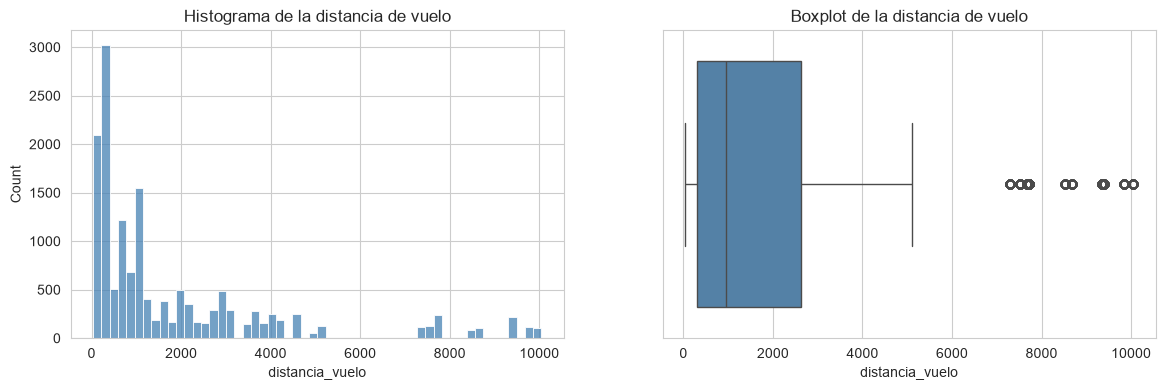

In [318]:
sns.set_style("whitegrid")
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_vuelos, x="distancia_vuelo", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de la distancia de vuelo")
sns.boxplot(data=data_vuelos, x="distancia_vuelo", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de la distancia de vuelo")
plt.show()

In [319]:
'''
El histograma de Distancia de Vuelo muestra una gran concentración de vuelos en el rango de 0 a 2000km, indicando que DS Airlines se centra en vuelos de corta/media distancia. Hay una fuerte asimetría
positiva, dando a entender que a medida que las distancias de los vuelos aumenta, la frecuencia de los mismos disminuye de forma drástica.

En lo que respecta al BoxPlot, podemos identificar que los vuelos de una distancia mayor a 6000km (aproximadamente) ya se consideran valores atípicos. También podemos ver que el 50% de los vuelos tienen
distancias que varían entre los 300km y los 2600km (aproximadamente).
'''

'\nEl histograma de Distancia de Vuelo muestra una gran concentración de vuelos en el rango de 0 a 2000km, indicando que DS Airlines se centra en vuelos de corta/media distancia. Hay una fuerte asimetría\npositiva, dando a entender que a medida que las distancias de los vuelos aumenta, la frecuencia de los mismos disminuye de forma drástica.\n\nEn lo que respecta al BoxPlot, podemos identificar que los vuelos de una distancia mayor a 6000km (aproximadamente) ya se consideran valores atípicos. También podemos ver que el 50% de los vuelos tienen\ndistancias que varían entre los 300km y los 2600km (aproximadamente).\n'

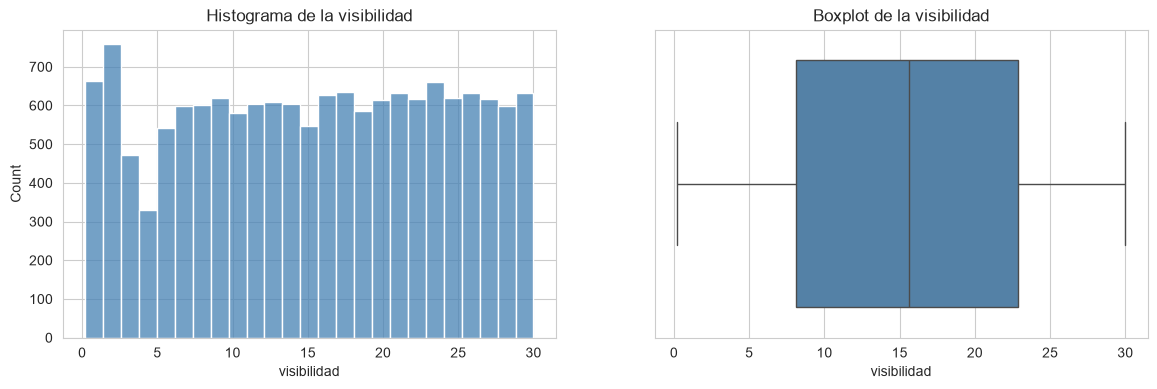

In [320]:
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_vuelos, x="visibilidad", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de la visibilidad")
sns.boxplot(data=data_vuelos, x="visibilidad", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de la visibilidad")
plt.show()

In [321]:
'''
El histograma de Visibilidad muestra una distribución aproximadamente uniforme, indicando que los vuelos de DS Airlines operan con regularidad en un rango amplio de condiciones, teniendo visibilidad
reducida (< 5km) hasta visibilidad optima (30km).
En el BoxPlot podemos ver que el 50% central de los vuelos opera con un rango de visibilidad que varia entre los 8km y los 23km (aproximadamente), confirmando la alta variabilidad climatica con la que
se opera regularmente. No se identifican outliners, indicando que no se han registrado casos atípicos extremos.
'''

'\nEl histograma de Visibilidad muestra una distribución aproximadamente uniforme, indicando que los vuelos de DS Airlines operan con regularidad en un rango amplio de condiciones, teniendo visibilidad\nreducida (< 5km) hasta visibilidad optima (30km).\nEn el BoxPlot podemos ver que el 50% central de los vuelos opera con un rango de visibilidad que varia entre los 8km y los 23km (aproximadamente), confirmando la alta variabilidad climatica con la que\nse opera regularmente. No se identifican outliners, indicando que no se han registrado casos atípicos extremos.\n'

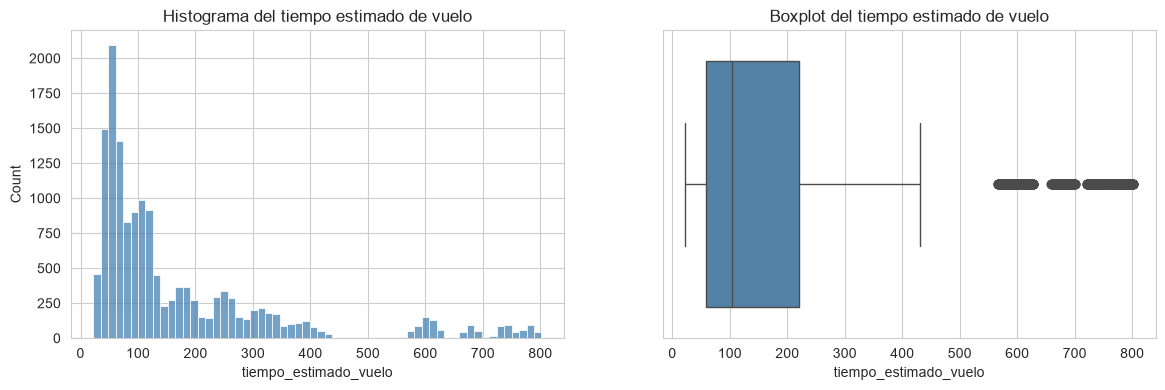

In [322]:
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_vuelos, x="tiempo_estimado_vuelo", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma del tiempo estimado de vuelo")
sns.boxplot(data=data_vuelos, x="tiempo_estimado_vuelo", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot del tiempo estimado de vuelo")
plt.show()

In [323]:
'''
En el histograma del tiempo estimado de vuelo se puede apreciar que la mayoria de los vuelos tienen una duracion de 50 a 200 minutos.
En el boxplot se puede observar como el 50% de los vuelos tienen una duracion de entre 60 a 220 minutos aproximadamente, tambien se pueden apreciar varios grupos de outliers alrededor de los valores 600, 700 y 800 (dichos
outliers tambien son apreciables en el histograma)
'''

'\nEn el histograma del tiempo estimado de vuelo se puede apreciar que la mayoria de los vuelos tienen una duracion de 50 a 200 minutos.\nEn el boxplot se puede observar como el 50% de los vuelos tienen una duracion de entre 60 a 220 minutos aproximadamente, tambien se pueden apreciar varios grupos de outliers alrededor de los valores 600, 700 y 800 (dichos\noutliers tambien son apreciables en el histograma)\n'

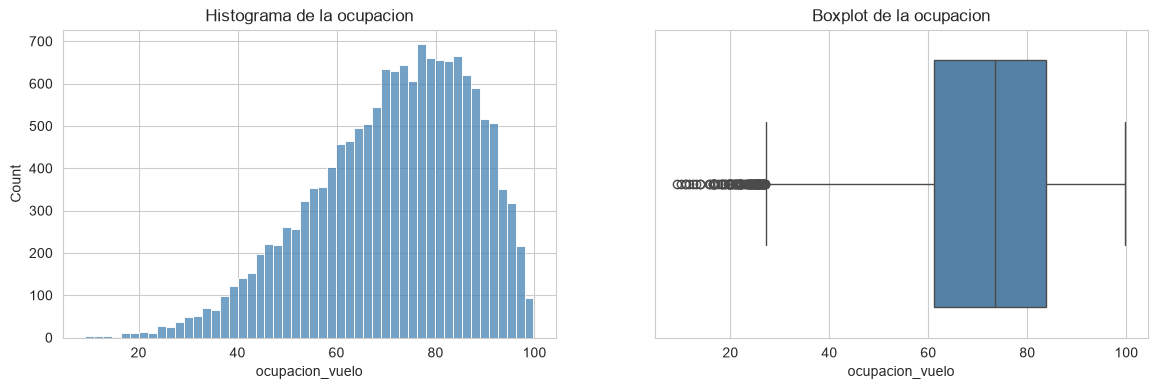

In [324]:
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_vuelos, x="ocupacion_vuelo", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de la ocupacion")
sns.boxplot(data=data_vuelos, x="ocupacion_vuelo", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de la ocupacion")
plt.show()

In [325]:
'''
El histograma de la ocupacion se ve una distribucion asimetrica con una larga cola hacia la izquierda indicando que la mayoria de vuelos tienen una ocupacion de entre el 60% y el 95% aproximadamente
En el boxplot se puede apreciar como el 50% de los vuelos tienen una ocupacion de entre 60% y 95%, tambien se puede ver la existencia de varios valores outliers en el extremo inferior con valores menores a 30
'''

'\nEl histograma de la ocupacion se ve una distribucion asimetrica con una larga cola hacia la izquierda indicando que la mayoria de vuelos tienen una ocupacion de entre el 60% y el 95% aproximadamente\nEn el boxplot se puede apreciar como el 50% de los vuelos tienen una ocupacion de entre 60% y 95%, tambien se puede ver la existencia de varios valores outliers en el extremo inferior con valores menores a 30\n'

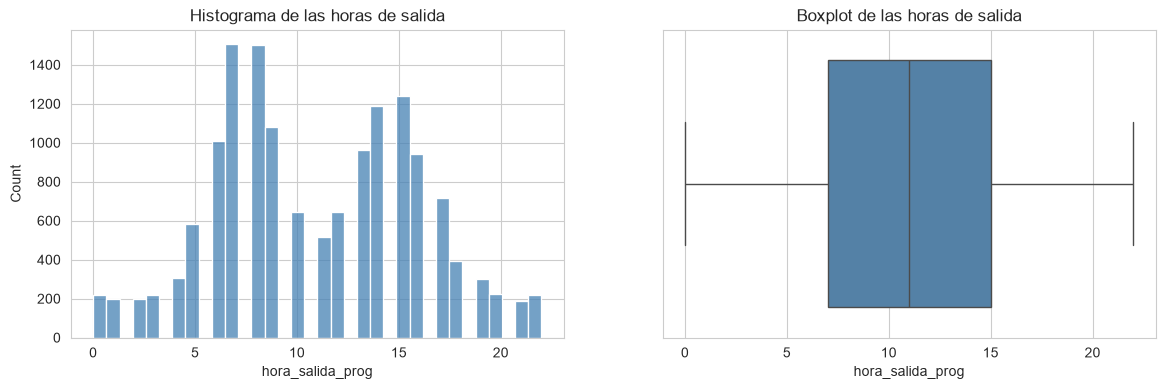

In [326]:
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_vuelos, x="hora_salida_prog", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de las horas de salida")
sns.boxplot(data=data_vuelos, x="hora_salida_prog", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de las horas de salida")
plt.show()

In [327]:
'''
El histograma de las horas de salida programadas muestra dos picos claros de concentracion operativa. El primero entre las 7 y 9 horas, y el segundo entre la 14 y 16 horas.
En el boxplot se puede ver que el 50% de los vuelos tienen su salida en una franja que varia entre las 7 y 15 horas. No se identifican outliers indicando que todas las horas de salida registradras se encuentran dentro
de la dispersion esperada
'''

'\nEl histograma de las horas de salida programadas muestra dos picos claros de concentracion operativa. El primero entre las 7 y 9 horas, y el segundo entre la 14 y 16 horas.\nEn el boxplot se puede ver que el 50% de los vuelos tienen su salida en una franja que varia entre las 7 y 15 horas. No se identifican outliers indicando que todas las horas de salida registradras se encuentran dentro\nde la dispersion esperada\n'

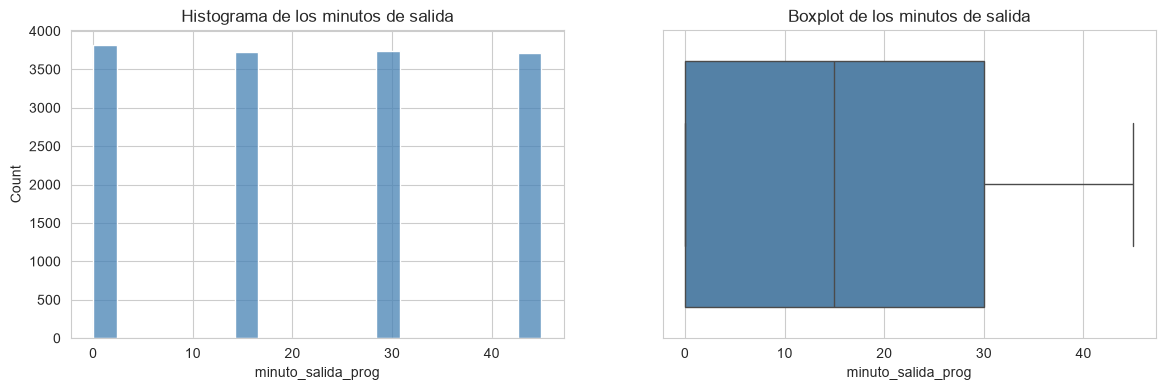

In [328]:
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_vuelos, x="minuto_salida_prog", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de los minutos de salida")
sns.boxplot(data=data_vuelos, x="minuto_salida_prog", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de los minutos de salida")
plt.show()

In [329]:
'''
El histrograma de los minutos de salida muestra una distribucion uniforme y discreta, indicando que todos los vuelos se realizan de forma equitativa en intervalos exactos de 15 minutos (0,15,30,45).
En el boxplot podemos ver que el 50% central de los vuelos tiene su minuto de salida programado en el rango que varia entre el minuto 0 y el minuto 30, lo cual es coherente con la distribucion observada en bloques
'''

'\nEl histrograma de los minutos de salida muestra una distribucion uniforme y discreta, indicando que todos los vuelos se realizan de forma equitativa en intervalos exactos de 15 minutos (0,15,30,45).\nEn el boxplot podemos ver que el 50% central de los vuelos tiene su minuto de salida programado en el rango que varia entre el minuto 0 y el minuto 30, lo cual es coherente con la distribucion observada en bloques\n'

##Graficos de Barras

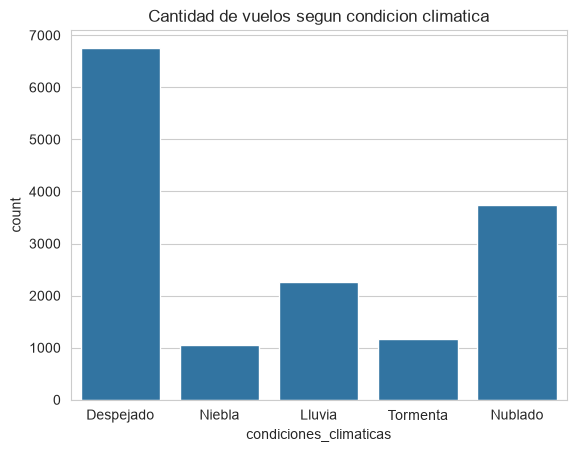

In [330]:
sns.countplot(x="condiciones_climaticas", data=data_vuelos)
plt.title("Cantidad de vuelos segun condicion climatica")
plt.show()

In [331]:
'''
El grafico de barras muestra  la frecuencia o cantidad de vuelos registrados para las distintas condiciones climáticas (despejado, niebla, lluvia, tormenta y nublado). La categoría
'despejado' es la que tiene mayor frecuencia, lo que la posiciona como la moda de los datos. La categoría 'niebla' es la de menor frecuencia, indicando que en esta condición
climática se registra menor actividad aérea
'''

"\nEl grafico de barras muestra  la frecuencia o cantidad de vuelos registrados para las distintas condiciones climáticas (despejado, niebla, lluvia, tormenta y nublado). La categoría\n'despejado' es la que tiene mayor frecuencia, lo que la posiciona como la moda de los datos. La categoría 'niebla' es la de menor frecuencia, indicando que en esta condición\nclimática se registra menor actividad aérea\n"

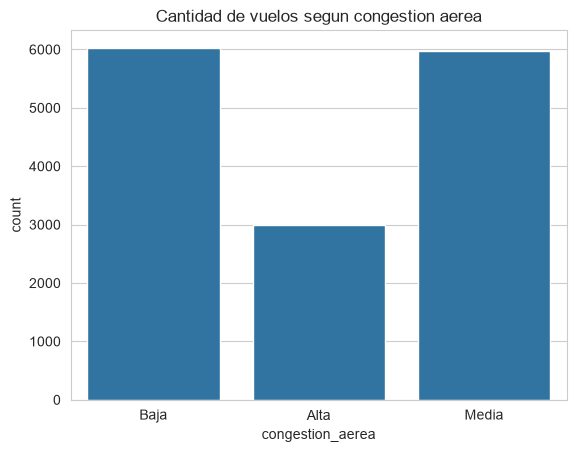

In [332]:
sns.countplot(x="congestion_aerea", data=data_vuelos)
plt.title("Cantidad de vuelos segun congestion aerea")
plt.show()

In [333]:
'''
El grafico de barras muestra la distribución de los vuelos según el nivel de congestión aérea para las distintas categorías (baja, alta, media). Se puede observar que la categoría
'Baja' y 'Media' tienen una frecuencia muy similar y predominante, en cambio la categoría 'Alta' es aproximadamente la mitad de las ocurrencias anteriores, lo cual indica que los
vuelos operando bajo esta congestión son los menos frecuentes en la muestra analizada.
'''

"\nEl grafico de barras muestra la distribución de los vuelos según el nivel de congestión aérea para las distintas categorías (baja, alta, media). Se puede observar que la categoría\n'Baja' y 'Media' tienen una frecuencia muy similar y predominante, en cambio la categoría 'Alta' es aproximadamente la mitad de las ocurrencias anteriores, lo cual indica que los\nvuelos operando bajo esta congestión son los menos frecuentes en la muestra analizada.\n"

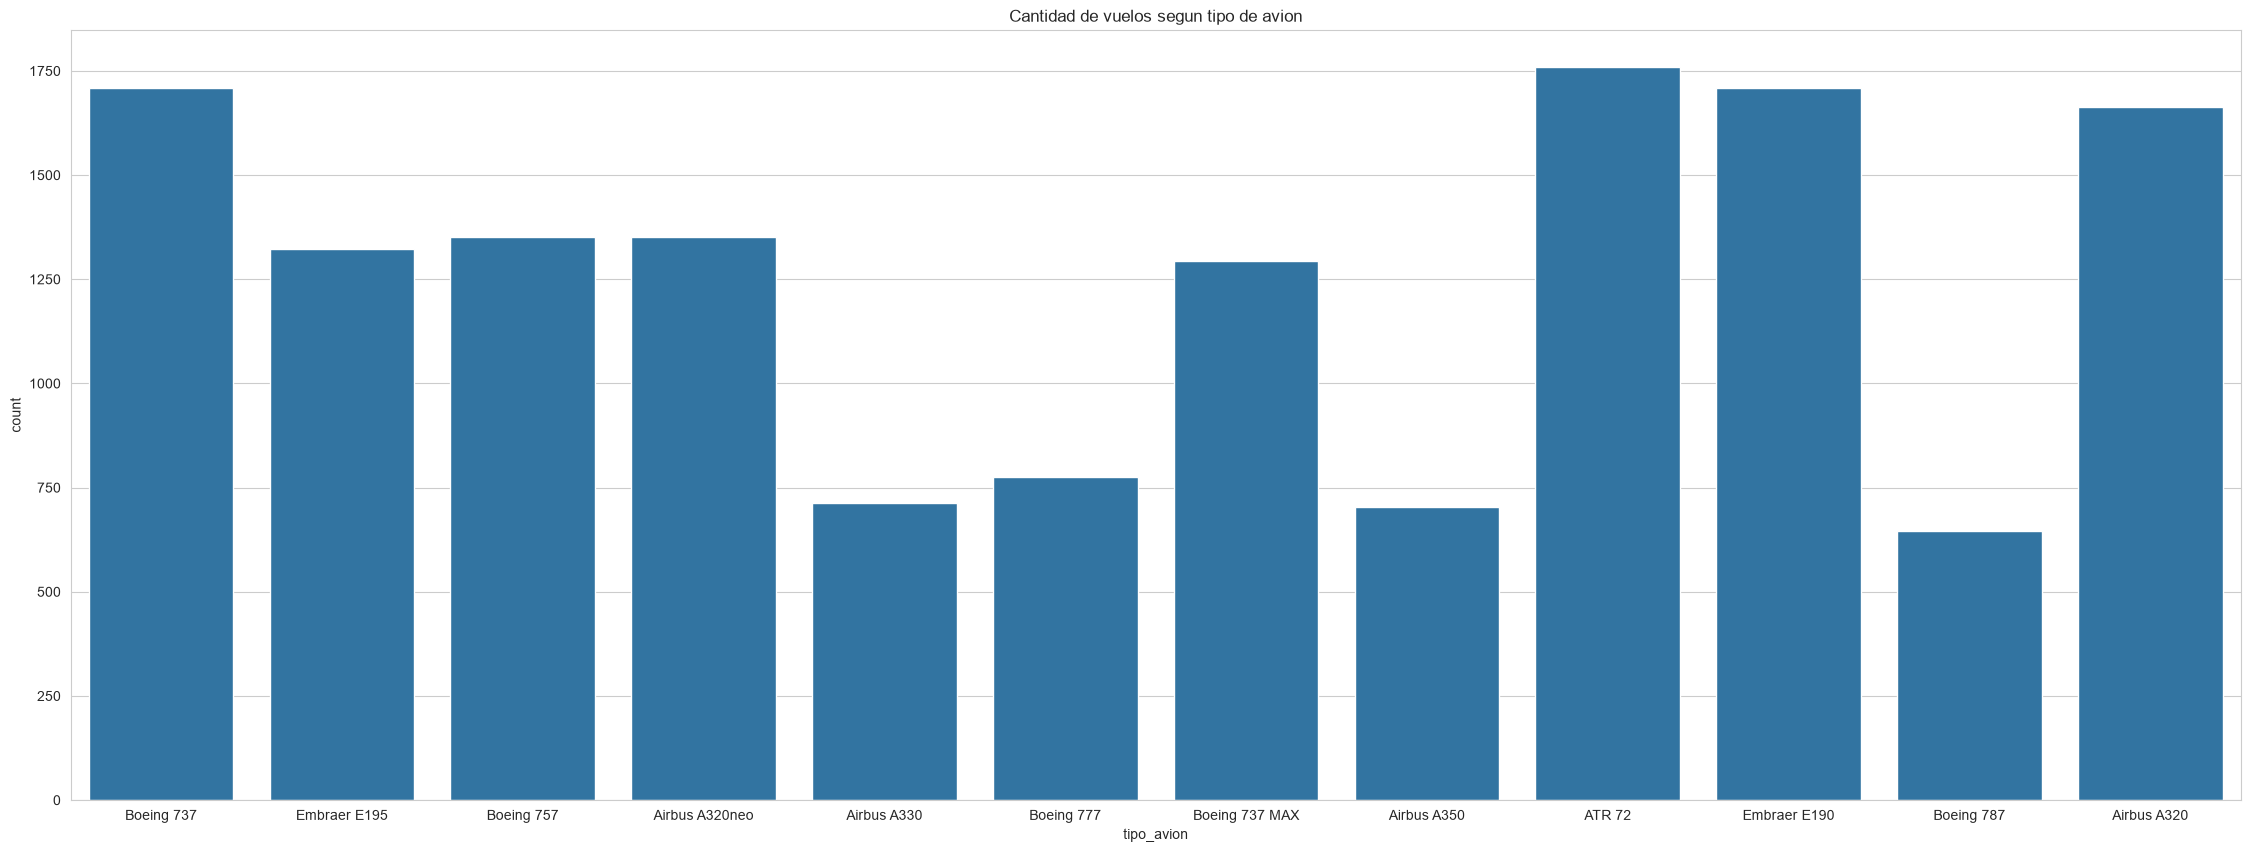

In [334]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.countplot(x="tipo_avion", data=data_vuelos)
ax.title.set_text("Cantidad de vuelos segun tipo de avion")
plt.show()

In [335]:
'''
El grafico de barras muestra la distribución de los vuelos según el modelo de avión que se utilizó. Se puede observar que los modelos ATR 72, Boeing 737 y Embraer E190 tienen las
frecuencias más altas.
En cambio, el Boeing 787 es el que menos registros tiene, lo que indica que se realizaron pocos vuelos con este modelo en particular.
'''

'\nEl grafico de barras muestra la distribución de los vuelos según el modelo de avión que se utilizó. Se puede observar que los modelos ATR 72, Boeing 737 y Embraer E190 tienen las\nfrecuencias más altas.\nEn cambio, el Boeing 787 es el que menos registros tiene, lo que indica que se realizaron pocos vuelos con este modelo en particular.\n'

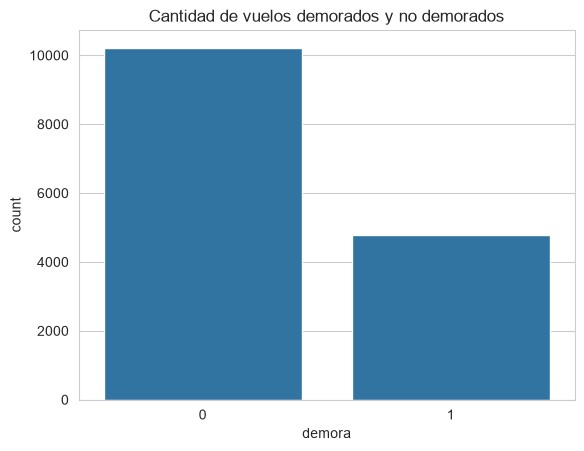

In [336]:
sns.countplot(x="demora", data=data_vuelos)
plt.title("Cantidad de vuelos demorados y no demorados")
plt.show()

In [337]:
'''
Este grafico de barras indica cuantas veces estuvo o no demorado un avión, siendo 0 que no hubo demoras, y 1 que el vuelo fue demorado.
Podemos observar que la mayoría de los vuelos no sufrieron demoras, mientras que los vuelos demorados representan un poco menos de la mitad de los datos
'''

'\nEste grafico de barras indica cuantas veces estuvo o no demorado un avión, siendo 0 que no hubo demoras, y 1 que el vuelo fue demorado.\nPodemos observar que la mayoría de los vuelos no sufrieron demoras, mientras que los vuelos demorados representan un poco menos de la mitad de los datos\n'

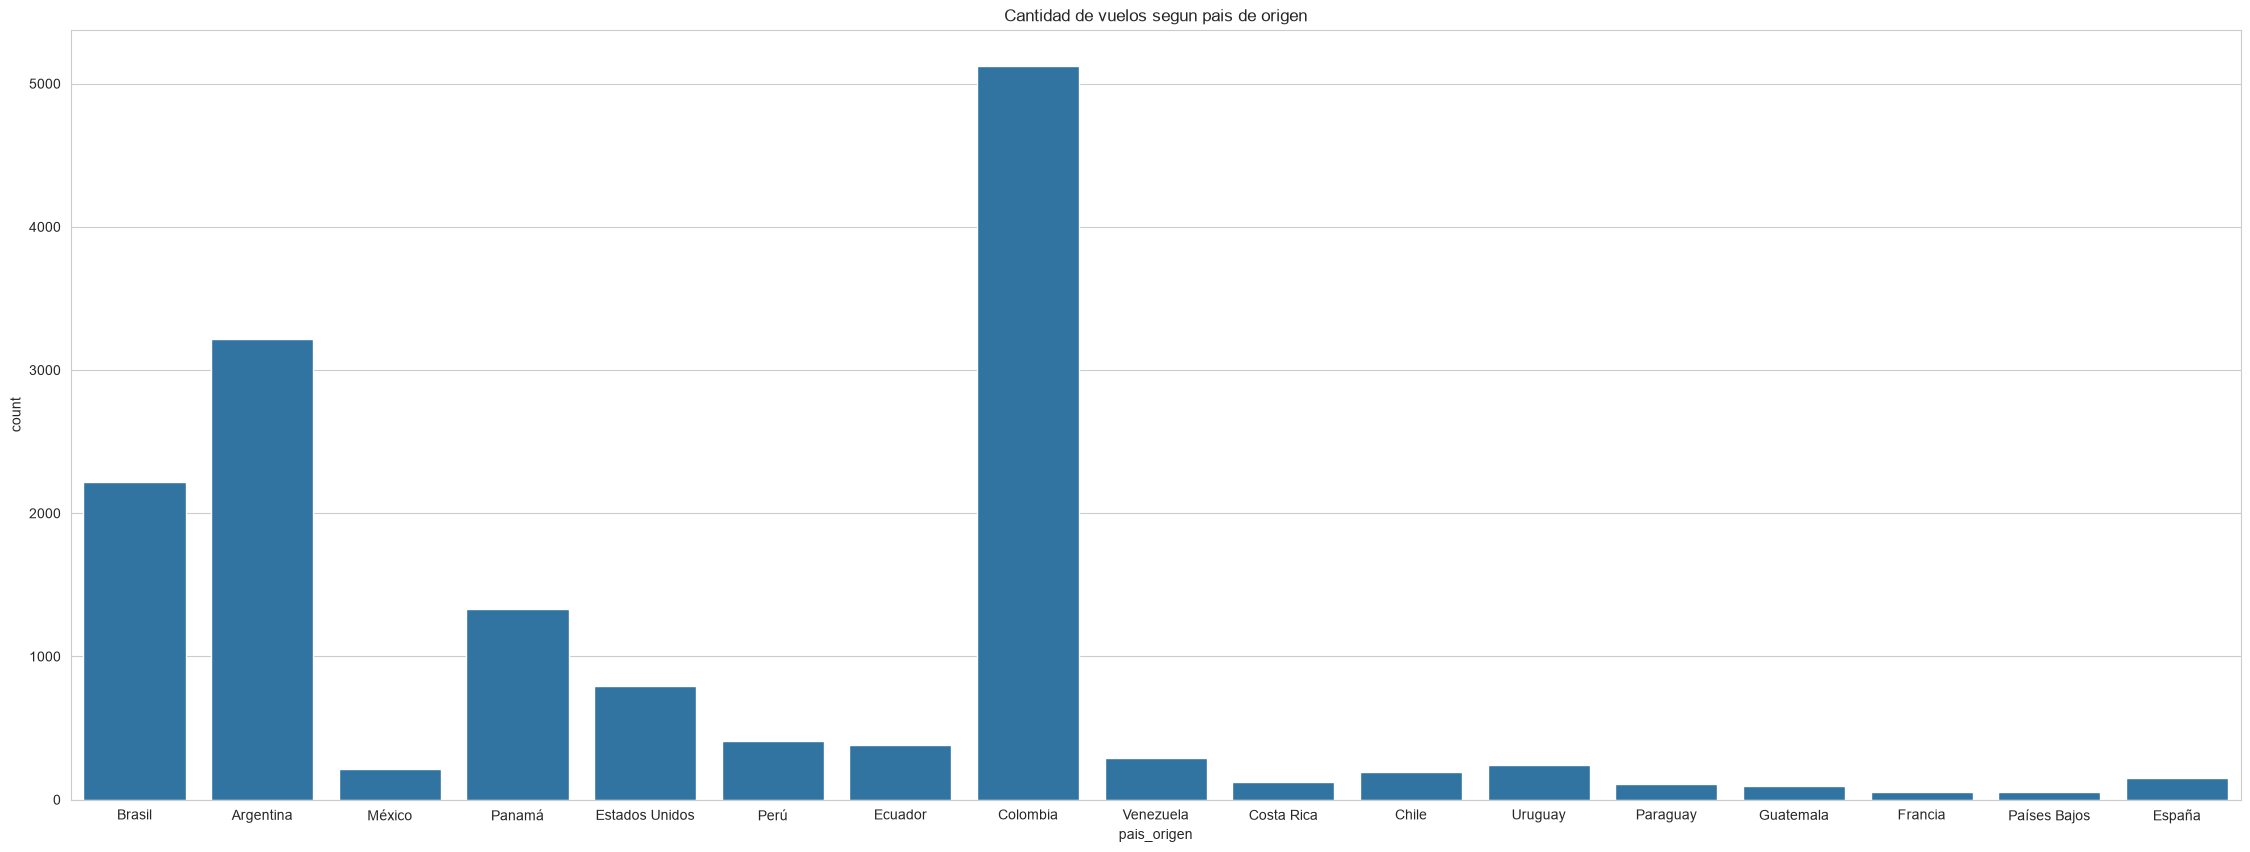

In [338]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.countplot(x="pais_origen", data=data_vuelos)
ax.title.set_text("Cantidad de vuelos segun pais de origen")
plt.show()

In [339]:
'''
En este grafico de barras se puede observar que hay 5 aeropuertos de origen que forman parte de la mayor parte de vuelos. Estos aeropuertos son:
EZE: con mas de 2000 vuelos es el aeropuerto de origen con mas vuelos.
BOG: con casi 2000 vuelos es el segundo que mas tiene
Esto significa que cualquier demora en estos puntos impactará a una mayor cantidad de pasajeros y procesos de DS Airlines.
PTY, GRU y MDE son aeropuertos que tienen entre 1300 y 1600 vuelos y actúan como centros de conexión importantes con un volumen estable.
El resto de aeropuertos varia entre los 50 y los 400 vuelos (aproximadamente), por lo que tienen una representatividad estadística mucho menor.
'''

'\nEn este grafico de barras se puede observar que hay 5 aeropuertos de origen que forman parte de la mayor parte de vuelos. Estos aeropuertos son:\nEZE: con mas de 2000 vuelos es el aeropuerto de origen con mas vuelos.\nBOG: con casi 2000 vuelos es el segundo que mas tiene\nEsto significa que cualquier demora en estos puntos impactará a una mayor cantidad de pasajeros y procesos de DS Airlines.\nPTY, GRU y MDE son aeropuertos que tienen entre 1300 y 1600 vuelos y actúan como centros de conexión importantes con un volumen estable.\nEl resto de aeropuertos varia entre los 50 y los 400 vuelos (aproximadamente), por lo que tienen una representatividad estadística mucho menor.\n'

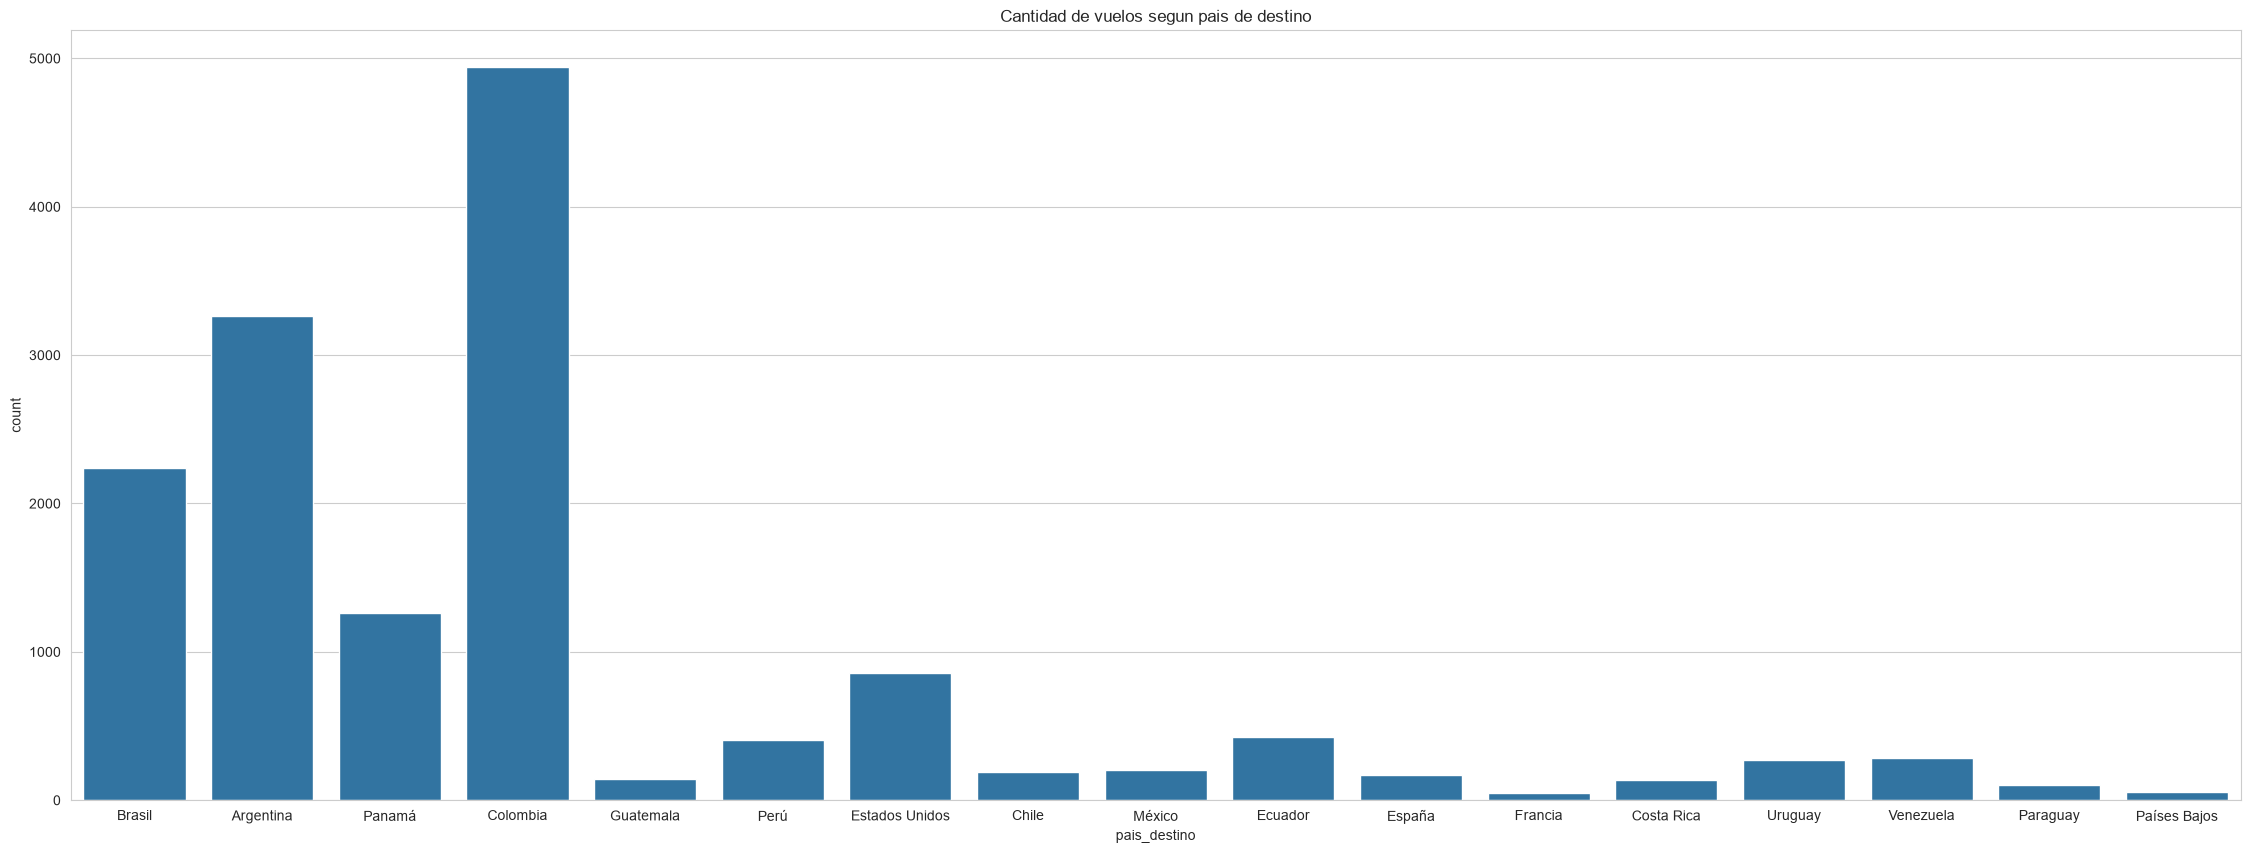

In [340]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.countplot(x="pais_destino", data=data_vuelos)
ax.title.set_text("Cantidad de vuelos segun pais de destino")
plt.show()

In [341]:
'''
El análisis termina siendo similar, de forma lógica, al del histograma de Cantidad de vuelos por aeropuerto de origen debido a que nuevamente EZE y BOG se consolidan como los
destinos con mayor volumen, superando los 2.000 y 1.900 vuelos respectivamente, representando la mayor parte del flujo de pasajeros y aeronaves termina en estos dos puntos. Un
aeropuerto de destino saturado (como EZE) puede obligar a que el vuelo se mantenga en espera en el aire o demore su aterrizaje, afectando la rotación de los aviones y generando
demoras en cadena para los vuelos siguientes.

También PTY, GRU y MDE mantienen su posición como destinos secundarios de alta frecuencia. Esta consistencia entre origen y destino refuerza la idea de rutas de ida y vuelta muy
estables.
'''

'\nEl análisis termina siendo similar, de forma lógica, al del histograma de Cantidad de vuelos por aeropuerto de origen debido a que nuevamente EZE y BOG se consolidan como los\ndestinos con mayor volumen, superando los 2.000 y 1.900 vuelos respectivamente, representando la mayor parte del flujo de pasajeros y aeronaves termina en estos dos puntos. Un\naeropuerto de destino saturado (como EZE) puede obligar a que el vuelo se mantenga en espera en el aire o demore su aterrizaje, afectando la rotación de los aviones y generando\ndemoras en cadena para los vuelos siguientes.\n\nTambién PTY, GRU y MDE mantienen su posición como destinos secundarios de alta frecuencia. Esta consistencia entre origen y destino refuerza la idea de rutas de ida y vuelta muy\nestables.\n'

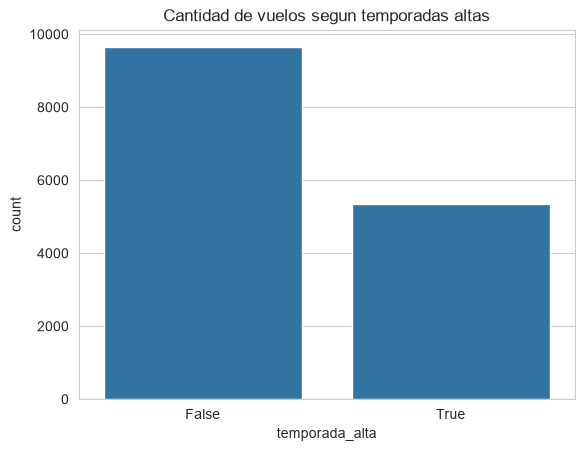

In [342]:
sns.countplot(x="temporada_alta", data=data_vuelos)
plt.title("Cantidad de vuelos segun temporadas altas")
plt.show()

In [343]:
'''
Podemos observar que, aproximadamente, el 60% de los vuelos en este dataset se realizaron fuera de la temporada alta. Esto podría indicar que la aerolínea no esta siendo solicitada
en periodos de alta temporada o que los datos no estas sesgados solamente en periodos vacacionales.

Históricamente, la temporada alta está asociada a una mayor saturación de las puertas de embarque, mayor volumen de equipaje y una congestión aérea persistente. Es altamente
probable que el modelo encuentre una correlación positiva entre temporada_alta = True y la probabilidad de demorado = 1.

'''

'\nPodemos observar que, aproximadamente, el 60% de los vuelos en este dataset se realizaron fuera de la temporada alta. Esto podría indicar que la aerolínea no esta siendo solicitada\nen periodos de alta temporada o que los datos no estas sesgados solamente en periodos vacacionales.\n\nHistóricamente, la temporada alta está asociada a una mayor saturación de las puertas de embarque, mayor volumen de equipaje y una congestión aérea persistente. Es altamente\nprobable que el modelo encuentre una correlación positiva entre temporada_alta = True y la probabilidad de demorado = 1.\n\n'

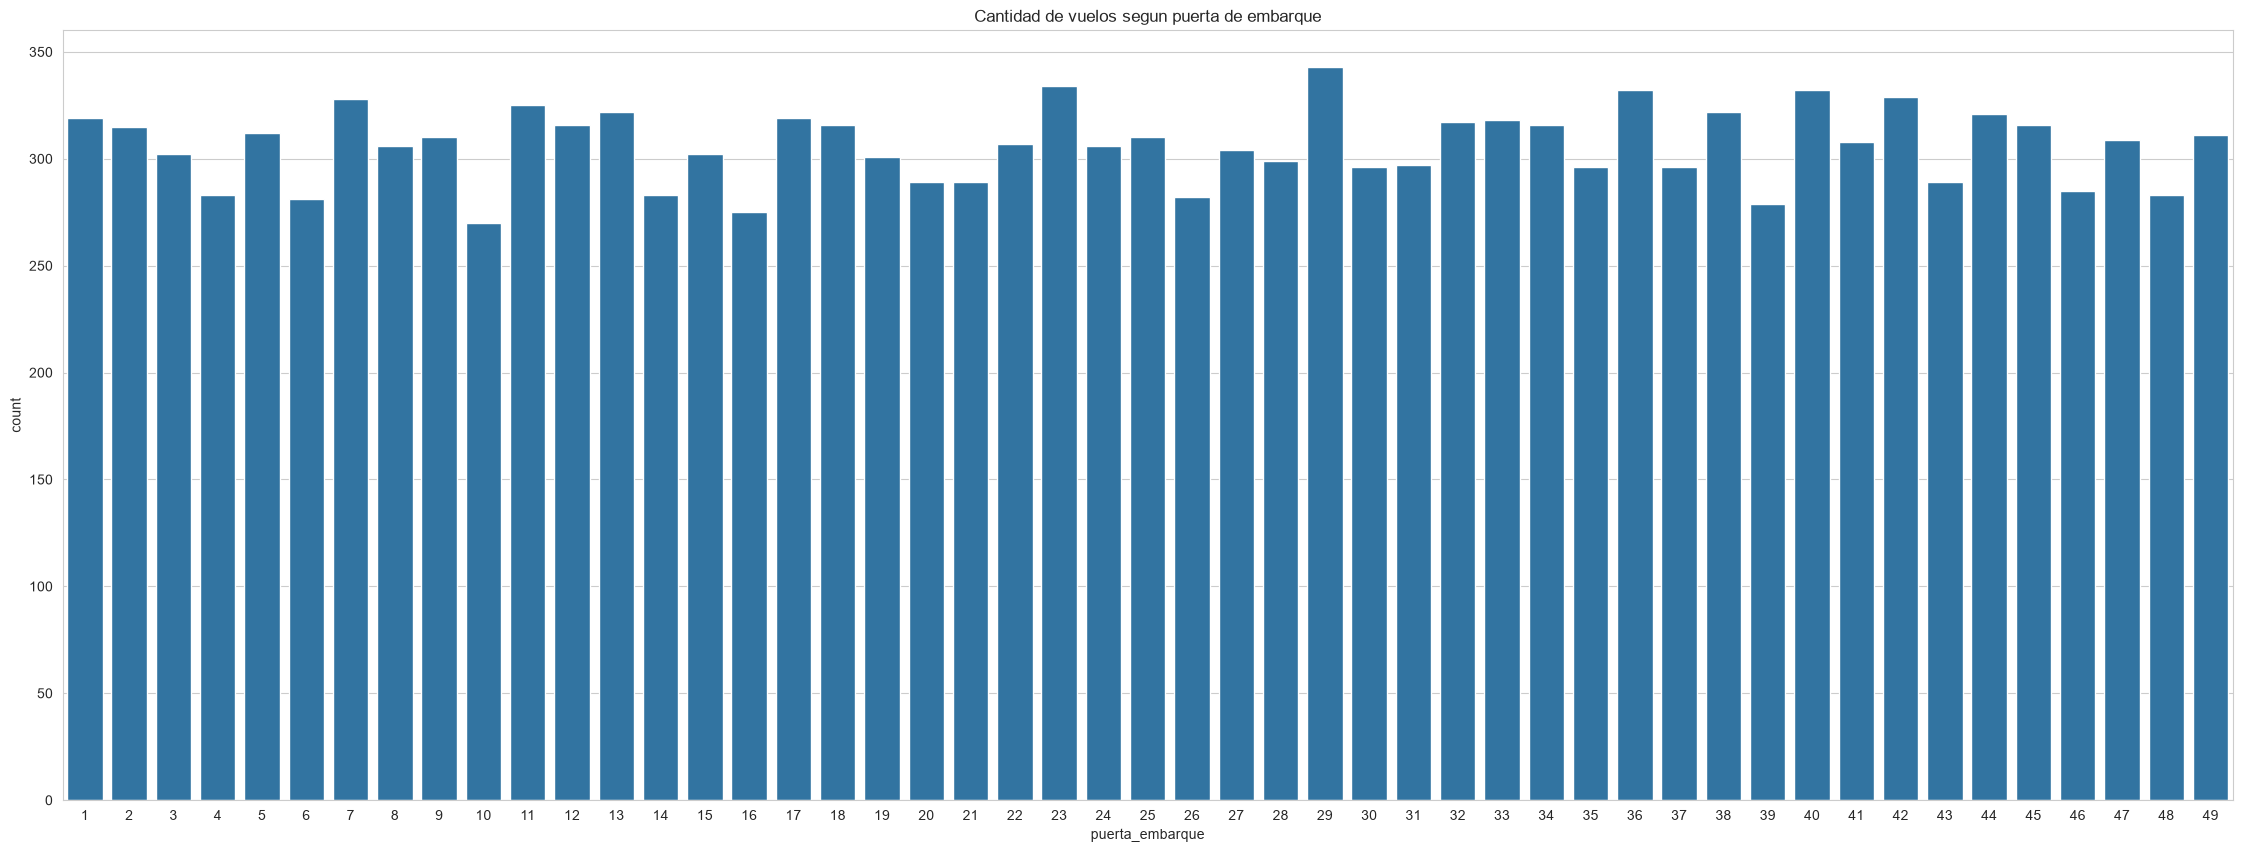

In [344]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.countplot(x="puerta_embarque", data=data_vuelos)
ax.title.set_text("Cantidad de vuelos segun puerta de embarque")
plt.show()

In [345]:
'''
El gráfico de barras muestra que la frecuencia de vuelos está repartida de manera casi idéntica entre las 49 puertas de embarque disponibles, indicando una asignación aleatoria o
rotativa por parte de la administración aeroportuaria en el dataset. Cada puerta registra un volumen de vuelos muy similar, lo que sugiere que ninguna puerta por sí sola parece representar un cuello de botella evidente.

Al ser una distribución tan uniforme, es probable que la variable puerta_embarque por sí sola no sea un predictor fuerte de demora.
'''

'\nEl gráfico de barras muestra que la frecuencia de vuelos está repartida de manera casi idéntica entre las 49 puertas de embarque disponibles, indicando una asignación aleatoria o\nrotativa por parte de la administración aeroportuaria en el dataset. Cada puerta registra un volumen de vuelos muy similar, lo que sugiere que ninguna puerta por sí sola parece representar un cuello de botella evidente.\n\nAl ser una distribución tan uniforme, es probable que la variable puerta_embarque por sí sola no sea un predictor fuerte de demora.\n'

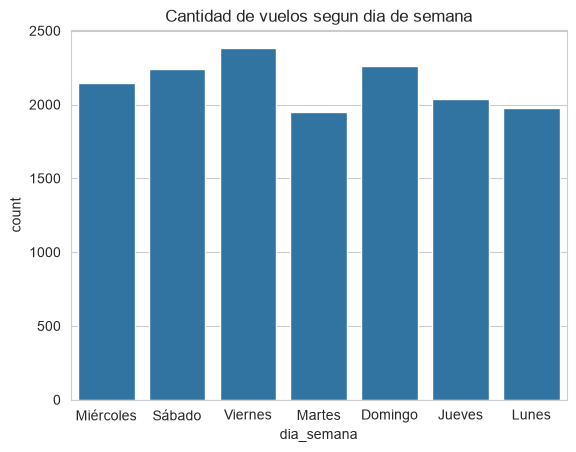

In [346]:
sns.countplot(x="dia_semana", data=data_vuelos)
plt.title("Cantidad de vuelos segun dia de semana")
plt.show()

In [347]:
'''
El gráfico de barras muestra una distribución uniforme entre todos los días de la semana, ya que no se observan días de extrema actividad ni tampoco se ven días de inactividad. Por
una poca diferencia, se podría decir que se destacan los días Viernes, Sábado y Domingo, lo cual es lógico debido al comportamiento de la industria aérea, donde la frecuencia
aérea aumenta en estos días debido a posibles viajes de ocio o de negocio. Aun así, en el resto de los días no hay una diferencia extrema de actividad, lo cual indica que la
aerolínea mantiene una operación constante durante todo el ciclo semanal.
'''

'\nEl gráfico de barras muestra una distribución uniforme entre todos los días de la semana, ya que no se observan días de extrema actividad ni tampoco se ven días de inactividad. Por\nuna poca diferencia, se podría decir que se destacan los días Viernes, Sábado y Domingo, lo cual es lógico debido al comportamiento de la industria aérea, donde la frecuencia\naérea aumenta en estos días debido a posibles viajes de ocio o de negocio. Aun así, en el resto de los días no hay una diferencia extrema de actividad, lo cual indica que la\naerolínea mantiene una operación constante durante todo el ciclo semanal.\n'

##Matriz de Covarianzas

In [348]:
data_vuelos.cov(numeric_only=True)

,distancia_vuelo,ocupacion_vuelo,visibilidad,tiempo_estimado_vuelo,hora_salida_prog,minuto_salida_prog
distancia_vuelo,5.183139e+06,332.304359,168.522998,388838.717868,96.299609,-401.566498
ocupacion_vuelo,3.323044e+02,254.873196,1.882840,25.555537,-0.229187,-0.266935
visibilidad,1.685230e+02,1.882840,74.535666,12.630705,0.428558,-0.542773
tiempo_estimado_vuelo,3.888387e+05,25.555537,12.630705,29244.619549,6.954650,-29.127268
hora_salida_prog,9.629961e+01,-0.229187,0.428558,6.954650,24.428734,1.713555
minuto_salida_prog,-4.015665e+02,-0.266935,-0.542773,-29.127268,1.713555,282.388662


##Matriz de Correlaciones

In [349]:
data_vuelos.corr(numeric_only=True)

,distancia_vuelo,ocupacion_vuelo,visibilidad,tiempo_estimado_vuelo,hora_salida_prog,minuto_salida_prog
distancia_vuelo,1.000000,0.009143,0.008574,0.998735,0.008558,-0.010496
ocupacion_vuelo,0.009143,1.000000,0.013661,0.009361,-0.002905,-0.000995
visibilidad,0.008574,0.013661,1.000000,0.008555,0.010043,-0.003741
tiempo_estimado_vuelo,0.998735,0.009361,0.008555,1.000000,0.008228,-0.010136
hora_salida_prog,0.008558,-0.002905,0.010043,0.008228,1.000000,0.020631
minuto_salida_prog,-0.010496,-0.000995,-0.003741,-0.010136,0.020631,1.000000


In [350]:
'''
En la matriz de correlaciones se puede ver una correlacion positiva de 0.998 entre tiempo_estimado_vuelo y distancia_vuelo indicando que a medida que aumenta la distacia de vuelo aumenta a su vez el tiempo estimado de vuelo
En el resto de las variables se presentan coeficientes muy cercanos a 0 indicando que las variables son linealmente independientes
'''

'\nEn la matriz de correlaciones se puede ver una correlacion positiva de 0.998 entre tiempo_estimado_vuelo y distancia_vuelo indicando que a medida que aumenta la distacia de vuelo aumenta a su vez el tiempo estimado de vuelo\nEn el resto de las variables se presentan coeficientes muy cercanos a 0 indicando que las variables son linealmente independientes\n'

##Scatterplot

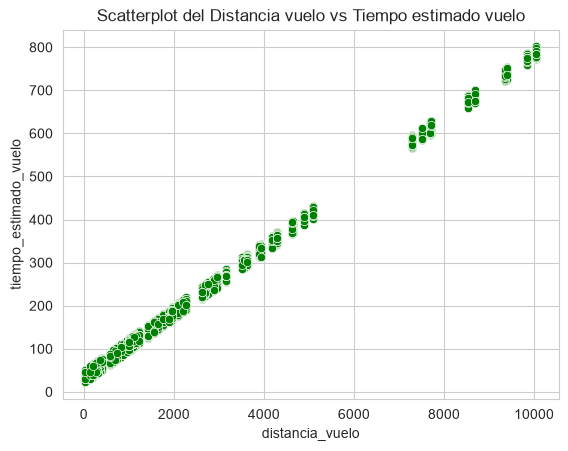

In [351]:
sns.scatterplot(data=data_vuelos, x="distancia_vuelo", y="tiempo_estimado_vuelo", color="green")
plt.title("Scatterplot del Distancia vuelo vs Tiempo estimado vuelo")
plt.show()

In [352]:
'''
En este primer gráfico se observa una obvia relación entre las variables, ya que a mayor distancia, obviamente se va a tardar más en realizar el recorrido. En este caso es que se detecta
multicolinealidad debido a la relación ascendente casi perfecta, por lo que la información es redundante y no es recomendable quedarse con ambas.
'''

'\nEn este primer gráfico se observa una obvia relación entre las variables, ya que a mayor distancia, obviamente se va a tardar más en realizar el recorrido. En este caso es que se detecta\nmulticolinealidad debido a la relación ascendente casi perfecta, por lo que la información es redundante y no es recomendable quedarse con ambas.\n'

##Boxplot Estratificados

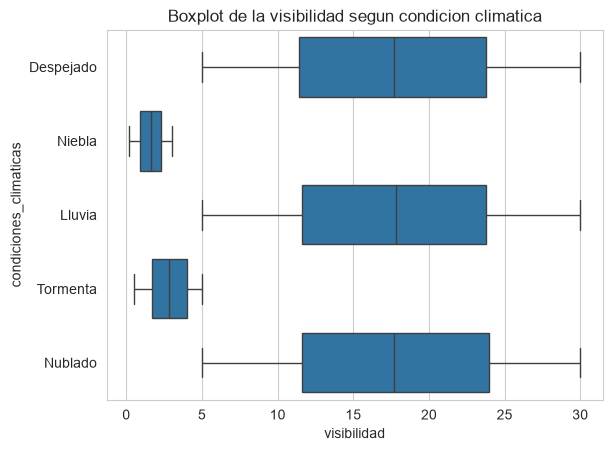

In [353]:
sns.boxplot(data=data_vuelos, x="visibilidad", y="condiciones_climaticas")
plt.title("Boxplot de la visibilidad segun condicion climatica")
plt.show()

In [354]:
'''
Al analizar el grafico podemos ver 2 grupos.
Grupo 1: Climas de alta visibilidad
Las cajas son casi identicas. La mediana esta alrededor de los 17-18km
La visibilidad varía mucho (ya que varia desde los 5km hasta los 30km)
Conclusion: Que llueve o este nublado no afecta a la visibilidad.

Grupo 2: Climas de baja visibilidad. (niebla, tormenta)
Las cajas estan completamente aplastadas hacia la izquierda
Niebla: La mediana esta en menos de 2.5km y el rango total de los bigotes entre 0 y 4km.
Tormenta: Similar a la niebla, mediana de 3km y rango de bigotes acotado.
Conlusion: Cuando el pronostico indica niebla o tormenta la visibilidad es muy baja.
'''

'\nAl analizar el grafico podemos ver 2 grupos.\nGrupo 1: Climas de alta visibilidad\nLas cajas son casi identicas. La mediana esta alrededor de los 17-18km\nLa visibilidad varía mucho (ya que varia desde los 5km hasta los 30km)\nConclusion: Que llueve o este nublado no afecta a la visibilidad.\n\nGrupo 2: Climas de baja visibilidad. (niebla, tormenta)\nLas cajas estan completamente aplastadas hacia la izquierda\nNiebla: La mediana esta en menos de 2.5km y el rango total de los bigotes entre 0 y 4km.\nTormenta: Similar a la niebla, mediana de 3km y rango de bigotes acotado.\nConlusion: Cuando el pronostico indica niebla o tormenta la visibilidad es muy baja.\n'

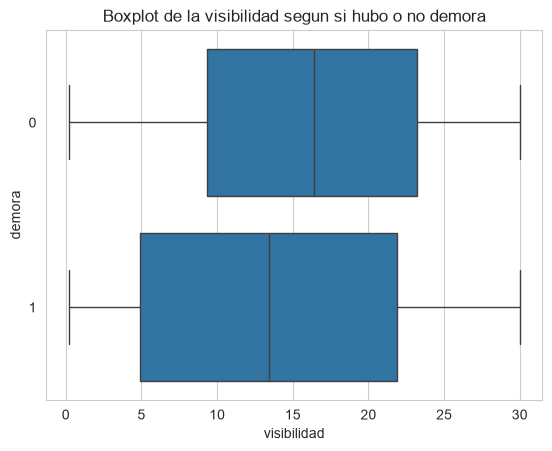

In [355]:
sns.boxplot(data=data_vuelos, x="visibilidad", y="demora")
plt.title("Boxplot de la visibilidad segun si hubo o no demora")
plt.show()

In [356]:
'''
En la grafica de la sin demora (caja superior) podemos observar como la visibilidad se concentra entre los 9km y 22km.
En los vuelos demorados (caja inferior) se concentra entre los 5km y 22km
Aunque existe una ligerísima tendencia a que los vuelos demorados tengan menor visibilidad promedio (la caja se estira hacia la izquierda), la variable por sí sola no tiene la fuerza suficiente para
clasificar y separar claramente los vuelos a tiempo de los demorados.
'''

'\nEn la grafica de la sin demora (caja superior) podemos observar como la visibilidad se concentra entre los 9km y 22km.\nEn los vuelos demorados (caja inferior) se concentra entre los 5km y 22km\nAunque existe una ligerísima tendencia a que los vuelos demorados tengan menor visibilidad promedio (la caja se estira hacia la izquierda), la variable por sí sola no tiene la fuerza suficiente para\nclasificar y separar claramente los vuelos a tiempo de los demorados.\n'

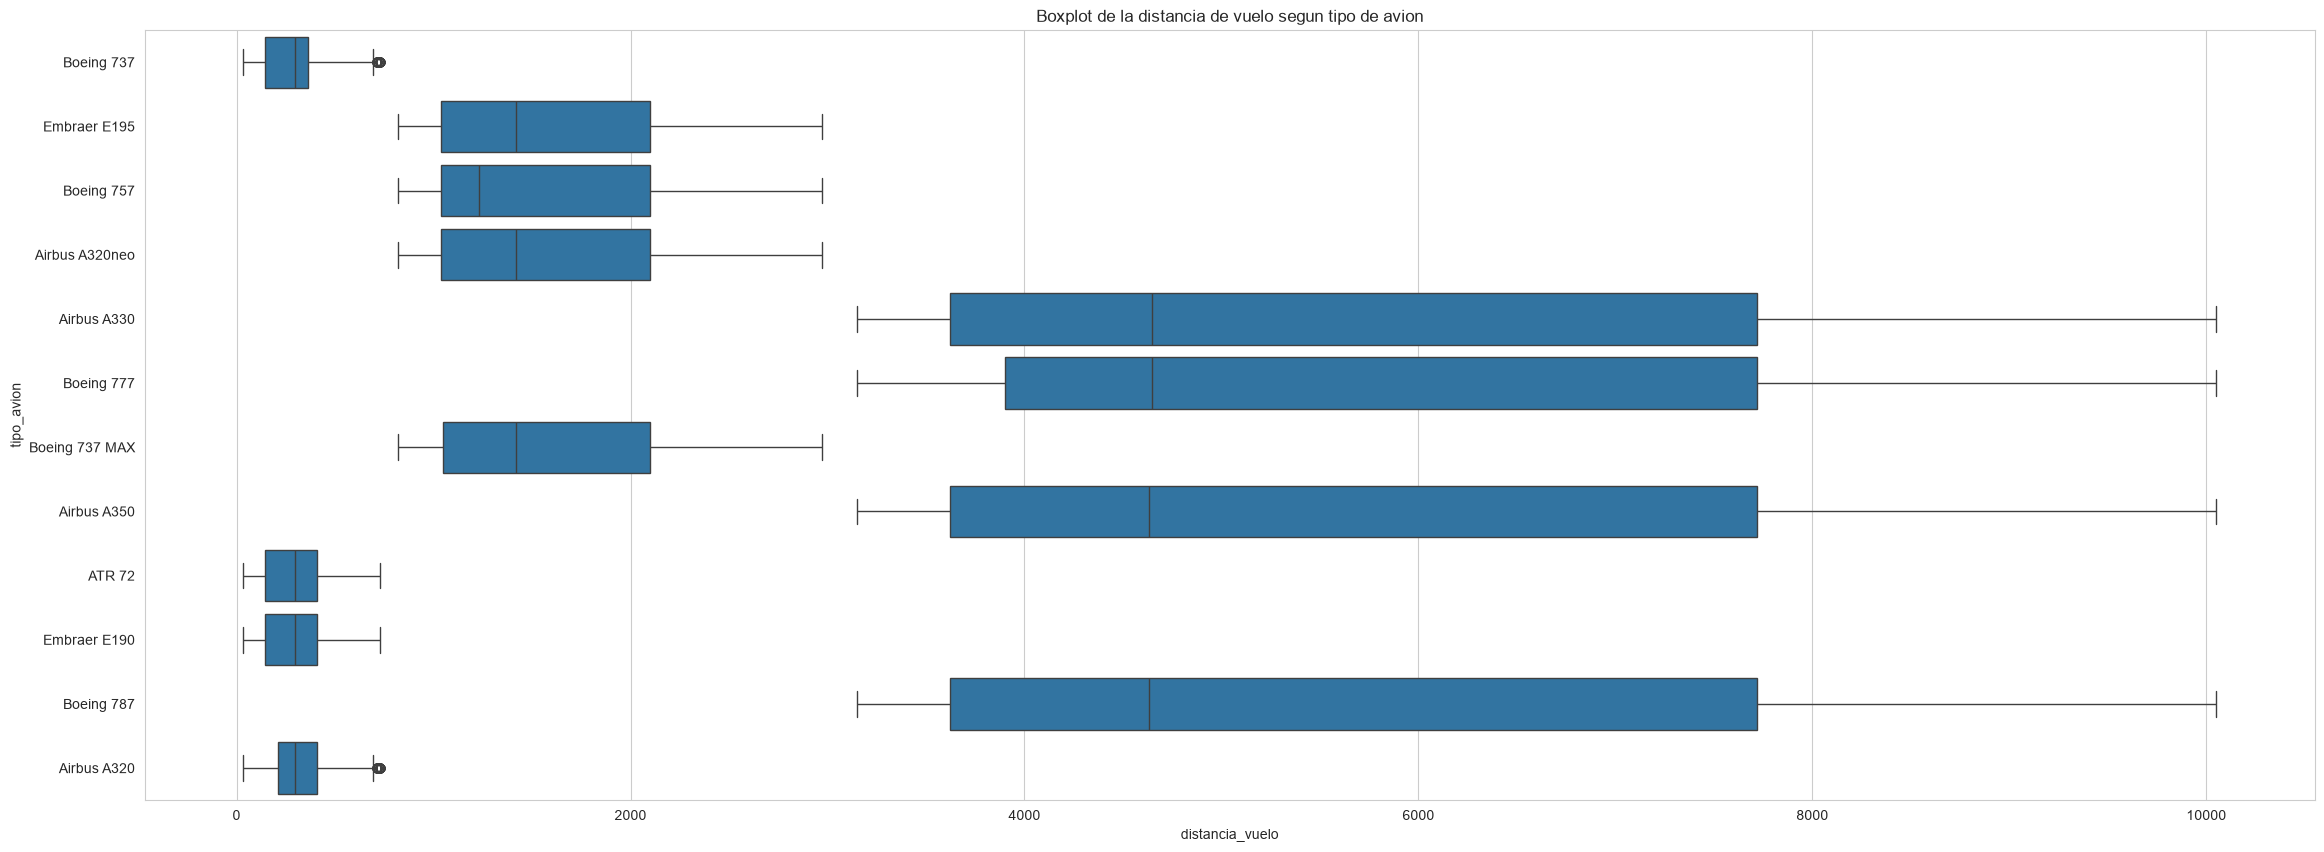

In [357]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.boxplot(data=data_vuelos, x="distancia_vuelo", y="tipo_avion")
ax.set_title("Boxplot de la distancia de vuelo segun tipo de avion")
plt.show()

In [358]:
'''
En el BoxPlot de distancia por tipo de avión podemos ver una clara segmentación:
Modelos de corto alcance: ATR 72 y los modelos Embraer (E190 y E195) trabajan en rangos de baja distancia (por debajo de los 1000km).
Modelos de medio alcance: Airbus A320, A320neo y Boeing 737 / 737, sus distancias varian entre los 1000km y los 3000km.
Modelos de largo alcance:Airbus A330, A350 y los Boeing 777, 787, son los que mas distancia realizan.

Los modelos Boeing 757 y Airbus A330 son aviones versátiles que la empresa utiliza tanto para vuelos de media distancia como para vuelos más largos (esto lo vemos ya que tienen mayor Rango
Intercuartílico).

Se identifica presencia de outliners en los modelos Boeing 737 y Airbus A320, lo cual indica que sean usado, en algunas ocasiones, aviones de corta distancia para un viaje de mayor reccorrido al que se
esta acostumbrado.
'''

'\nEn el BoxPlot de distancia por tipo de avión podemos ver una clara segmentación:\nModelos de corto alcance: ATR 72 y los modelos Embraer (E190 y E195) trabajan en rangos de baja distancia (por debajo de los 1000km).\nModelos de medio alcance: Airbus A320, A320neo y Boeing 737 / 737, sus distancias varian entre los 1000km y los 3000km.\nModelos de largo alcance:Airbus A330, A350 y los Boeing 777, 787, son los que mas distancia realizan.\n\nLos modelos Boeing 757 y Airbus A330 son aviones versátiles que la empresa utiliza tanto para vuelos de media distancia como para vuelos más largos (esto lo vemos ya que tienen mayor Rango\nIntercuartílico).\n\nSe identifica presencia de outliners en los modelos Boeing 737 y Airbus A320, lo cual indica que sean usado, en algunas ocasiones, aviones de corta distancia para un viaje de mayor reccorrido al que se\nesta acostumbrado.\n'

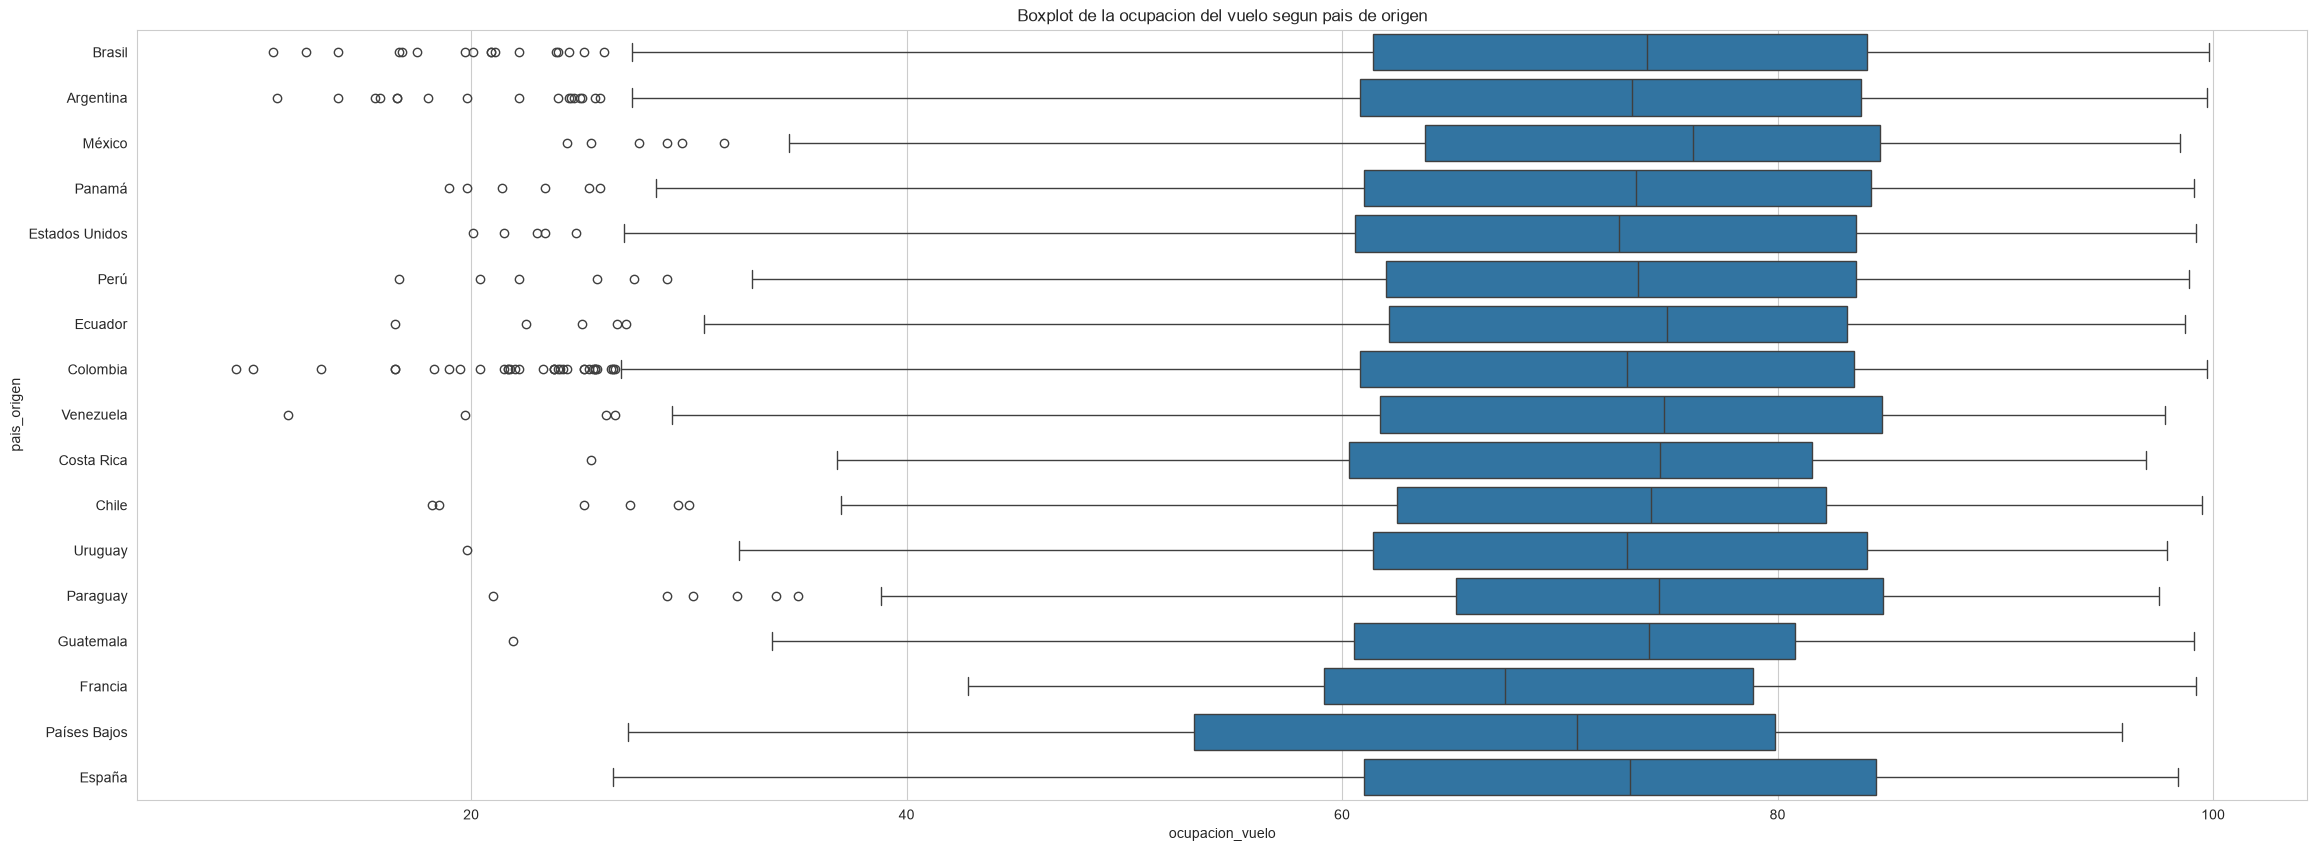

In [359]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.boxplot(data=data_vuelos, x="ocupacion_vuelo", y="pais_origen")
ax.set_title("Boxplot de la ocupacion del vuelo segun pais de origen")
plt.show()

In [360]:
'''
En el boxplot de la ocupacion del vuelo segun aeropuerto de origen se puede apreciar una notable homogeneidad ya que en la mayoria de cajas el 50% central de los vuelos opera entre valores de ocupacion muy similares
generalmente entre el 60% y 85%. Esto indica que el punto de partida del vuelo no altera drasticamente el comportamiento habitual de la demandas
Tambien se pueden apreciar outliers en el extremo izquierdo de la mayoria de las cajas indicando asi que los vuelos semi-vacios son un problema general de la aerolinea y no algo puntual de una terminal en particular
'''

'\nEn el boxplot de la ocupacion del vuelo segun aeropuerto de origen se puede apreciar una notable homogeneidad ya que en la mayoria de cajas el 50% central de los vuelos opera entre valores de ocupacion muy similares\ngeneralmente entre el 60% y 85%. Esto indica que el punto de partida del vuelo no altera drasticamente el comportamiento habitual de la demandas\nTambien se pueden apreciar outliers en el extremo izquierdo de la mayoria de las cajas indicando asi que los vuelos semi-vacios son un problema general de la aerolinea y no algo puntual de una terminal en particular\n'

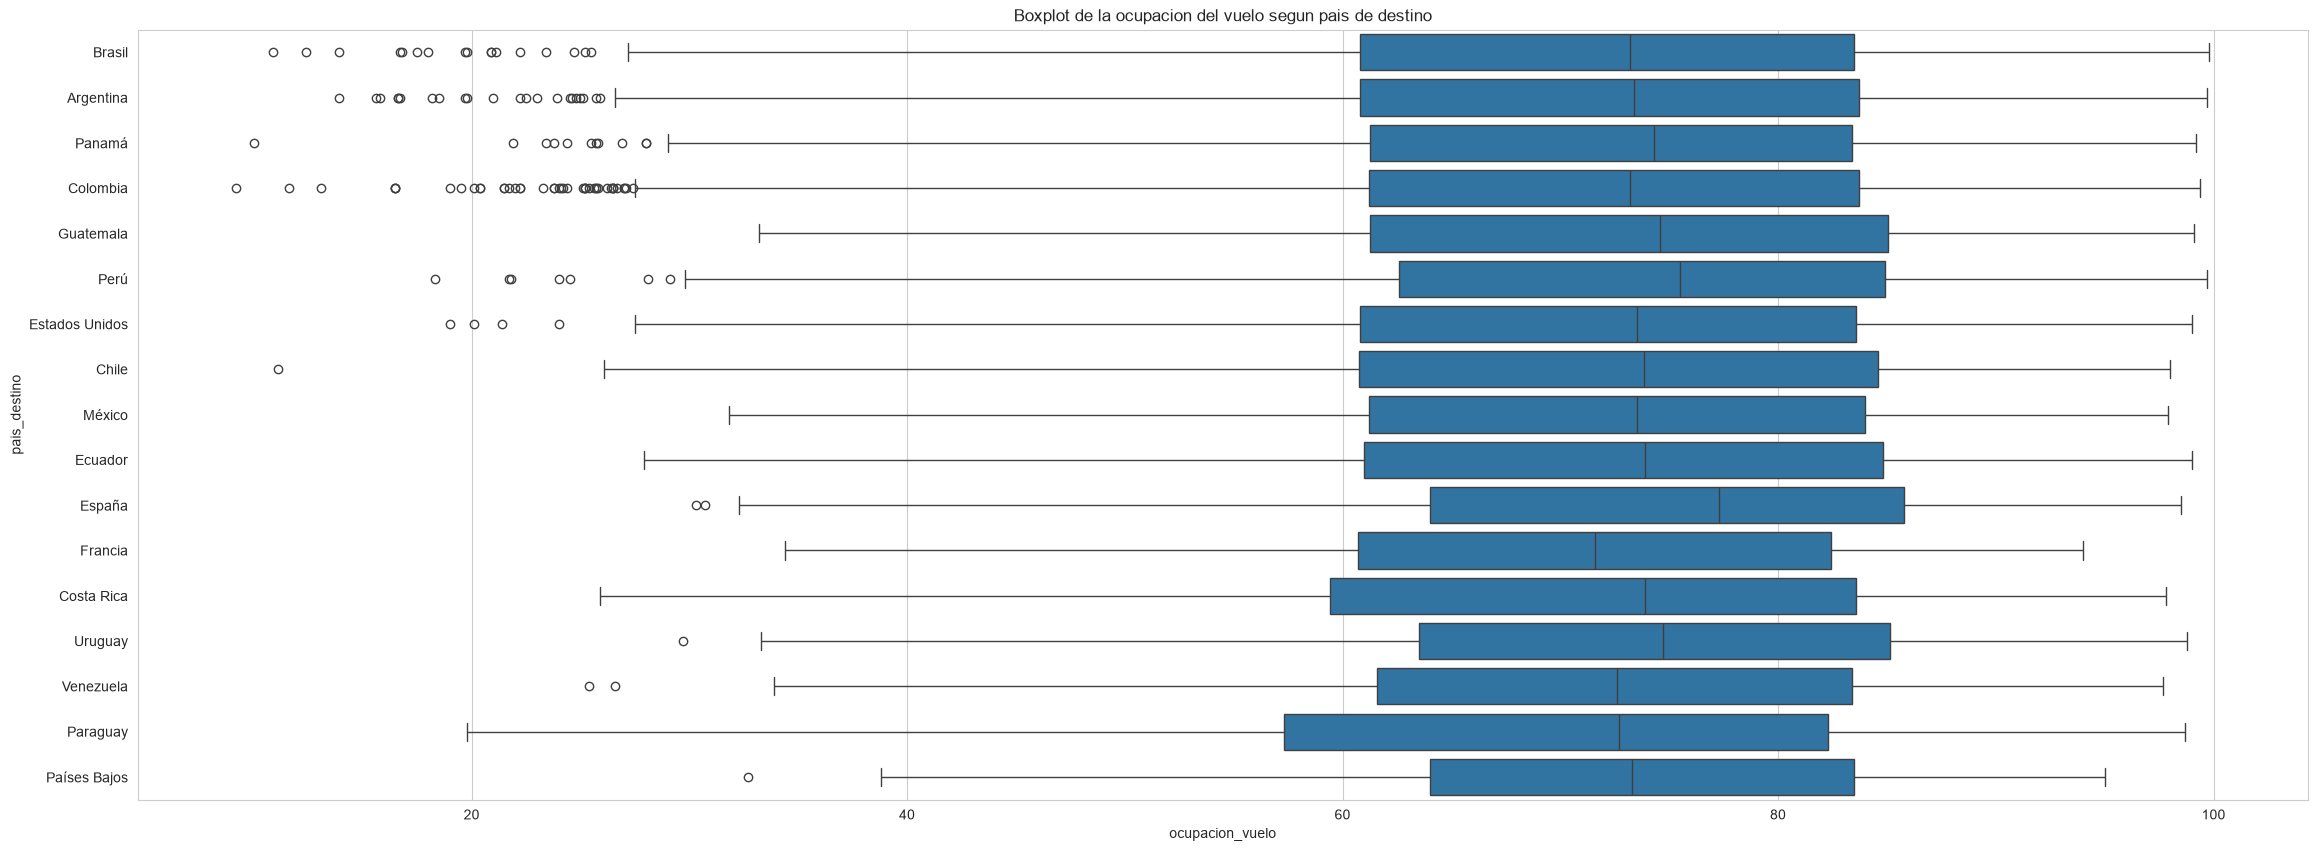

In [361]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.boxplot(data=data_vuelos, x="ocupacion_vuelo", y="pais_destino")
ax.set_title("Boxplot de la ocupacion del vuelo segun pais de destino")
plt.show()

In [362]:
'''
En el boxplot de la ocupacion del vuelo segun aeropuerto de destino se puede apreciar una notable homogeneidad ya que en la mayoria de cajas el 50% central de los vuelos opera entre valores de ocupacion muy similares
generalmente entre el 60% y 85%. Esto indica que el punto de partida del vuelo no altera drasticamente el comportamiento habitual de la demandas
Tambien se pueden apreciar outliers en el extremo izquierdo de la mayoria de las cajas indicando asi que los vuelos semi-vacios son un problema general de la aerolinea y no algo puntual de una terminal en particular
'''

'\nEn el boxplot de la ocupacion del vuelo segun aeropuerto de destino se puede apreciar una notable homogeneidad ya que en la mayoria de cajas el 50% central de los vuelos opera entre valores de ocupacion muy similares\ngeneralmente entre el 60% y 85%. Esto indica que el punto de partida del vuelo no altera drasticamente el comportamiento habitual de la demandas\nTambien se pueden apreciar outliers en el extremo izquierdo de la mayoria de las cajas indicando asi que los vuelos semi-vacios son un problema general de la aerolinea y no algo puntual de una terminal en particular\n'

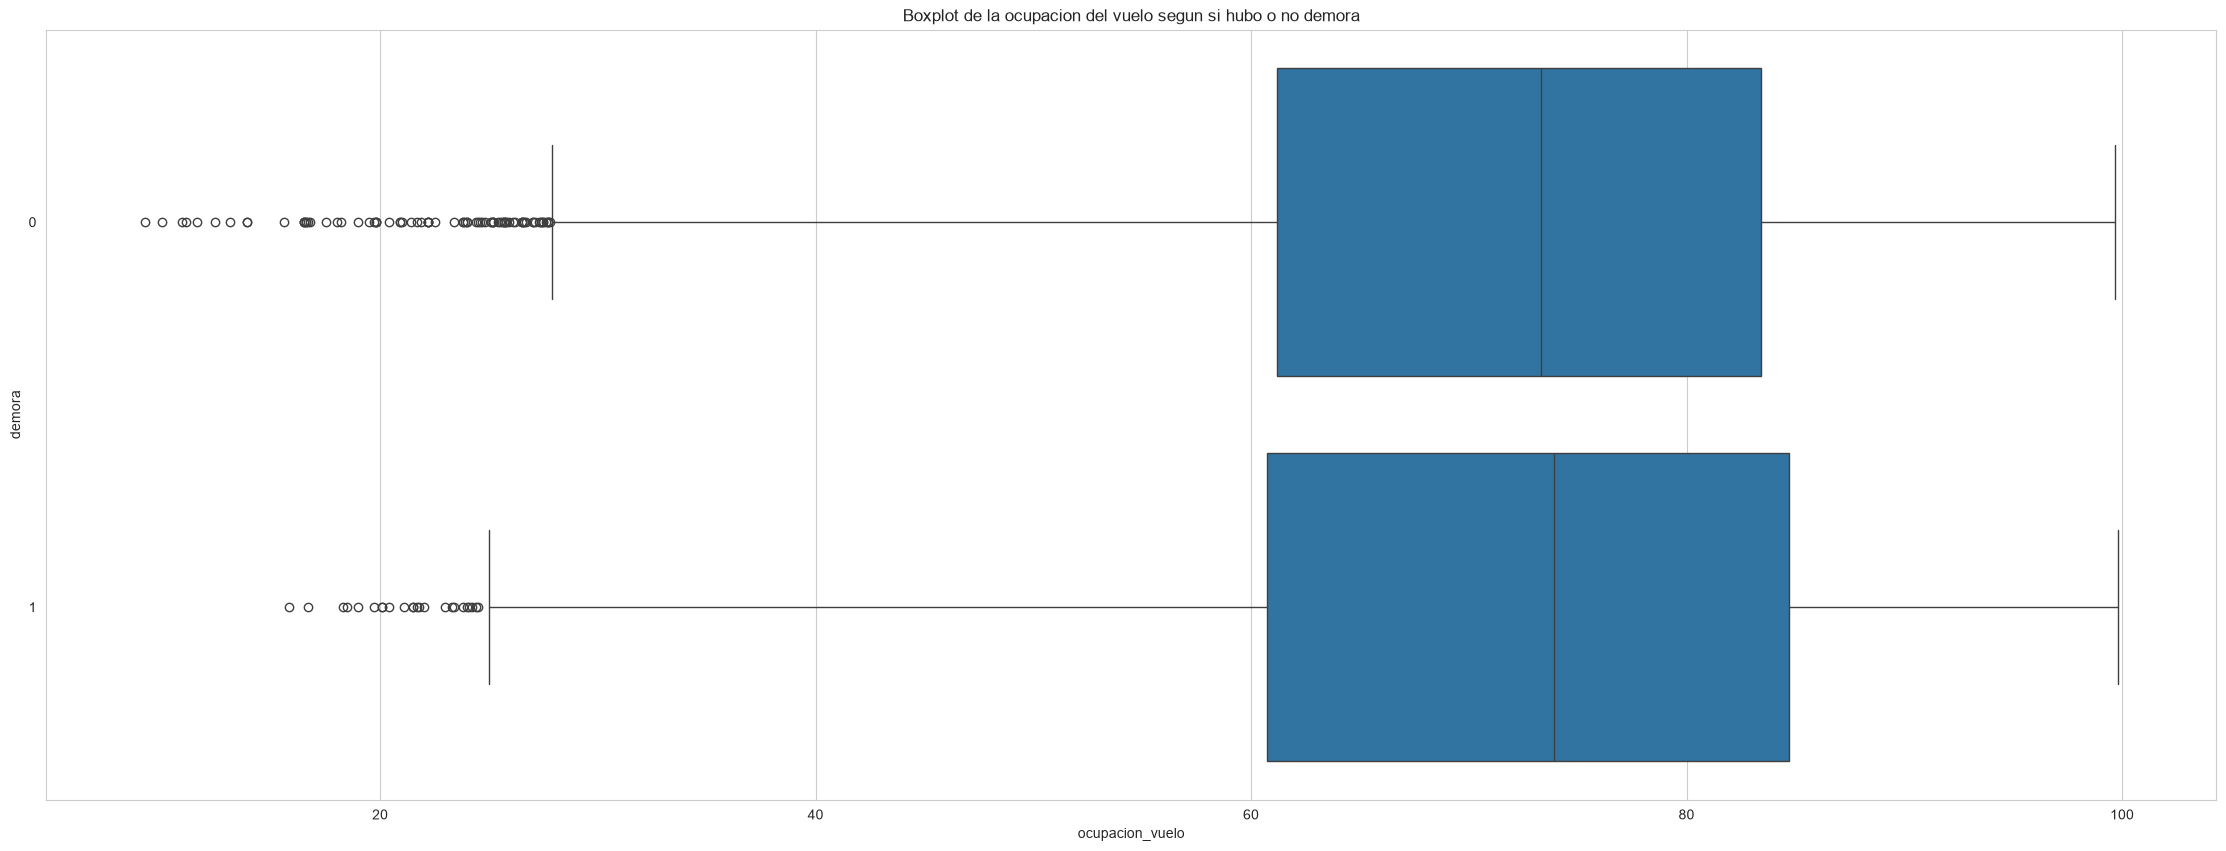

In [363]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.boxplot(data=data_vuelos, x="ocupacion_vuelo", y="demora")
ax.set_title("Boxplot de la ocupacion del vuelo segun si hubo o no demora")
plt.show()

In [364]:
'''
El boxplot de la ocupacion del vuelo segun si hubo o no demora muestra una distribucion practicamente identica para ambos casos ya que al observar las cajas podemos ver que el 50% central de los vuelos se concentran entre
los valores 60 y 85 de ocupacion. Esto indica claramente que el nivel de ocupacion del vuelo no tiene un impacto directo ni relacion con la probabilidad de que el vuelo sufra una demora. Ademas, tambien se ven la existencia
de outliers en el extremo izquierdo de ambas categorias lo cual implica que la existencia de vuelos semi-vacios ocurre tanto en aquellos que logran llegar a horario como en los que registran demora
'''

'\nEl boxplot de la ocupacion del vuelo segun si hubo o no demora muestra una distribucion practicamente identica para ambos casos ya que al observar las cajas podemos ver que el 50% central de los vuelos se concentran entre\nlos valores 60 y 85 de ocupacion. Esto indica claramente que el nivel de ocupacion del vuelo no tiene un impacto directo ni relacion con la probabilidad de que el vuelo sufra una demora. Ademas, tambien se ven la existencia\nde outliers en el extremo izquierdo de ambas categorias lo cual implica que la existencia de vuelos semi-vacios ocurre tanto en aquellos que logran llegar a horario como en los que registran demora\n'

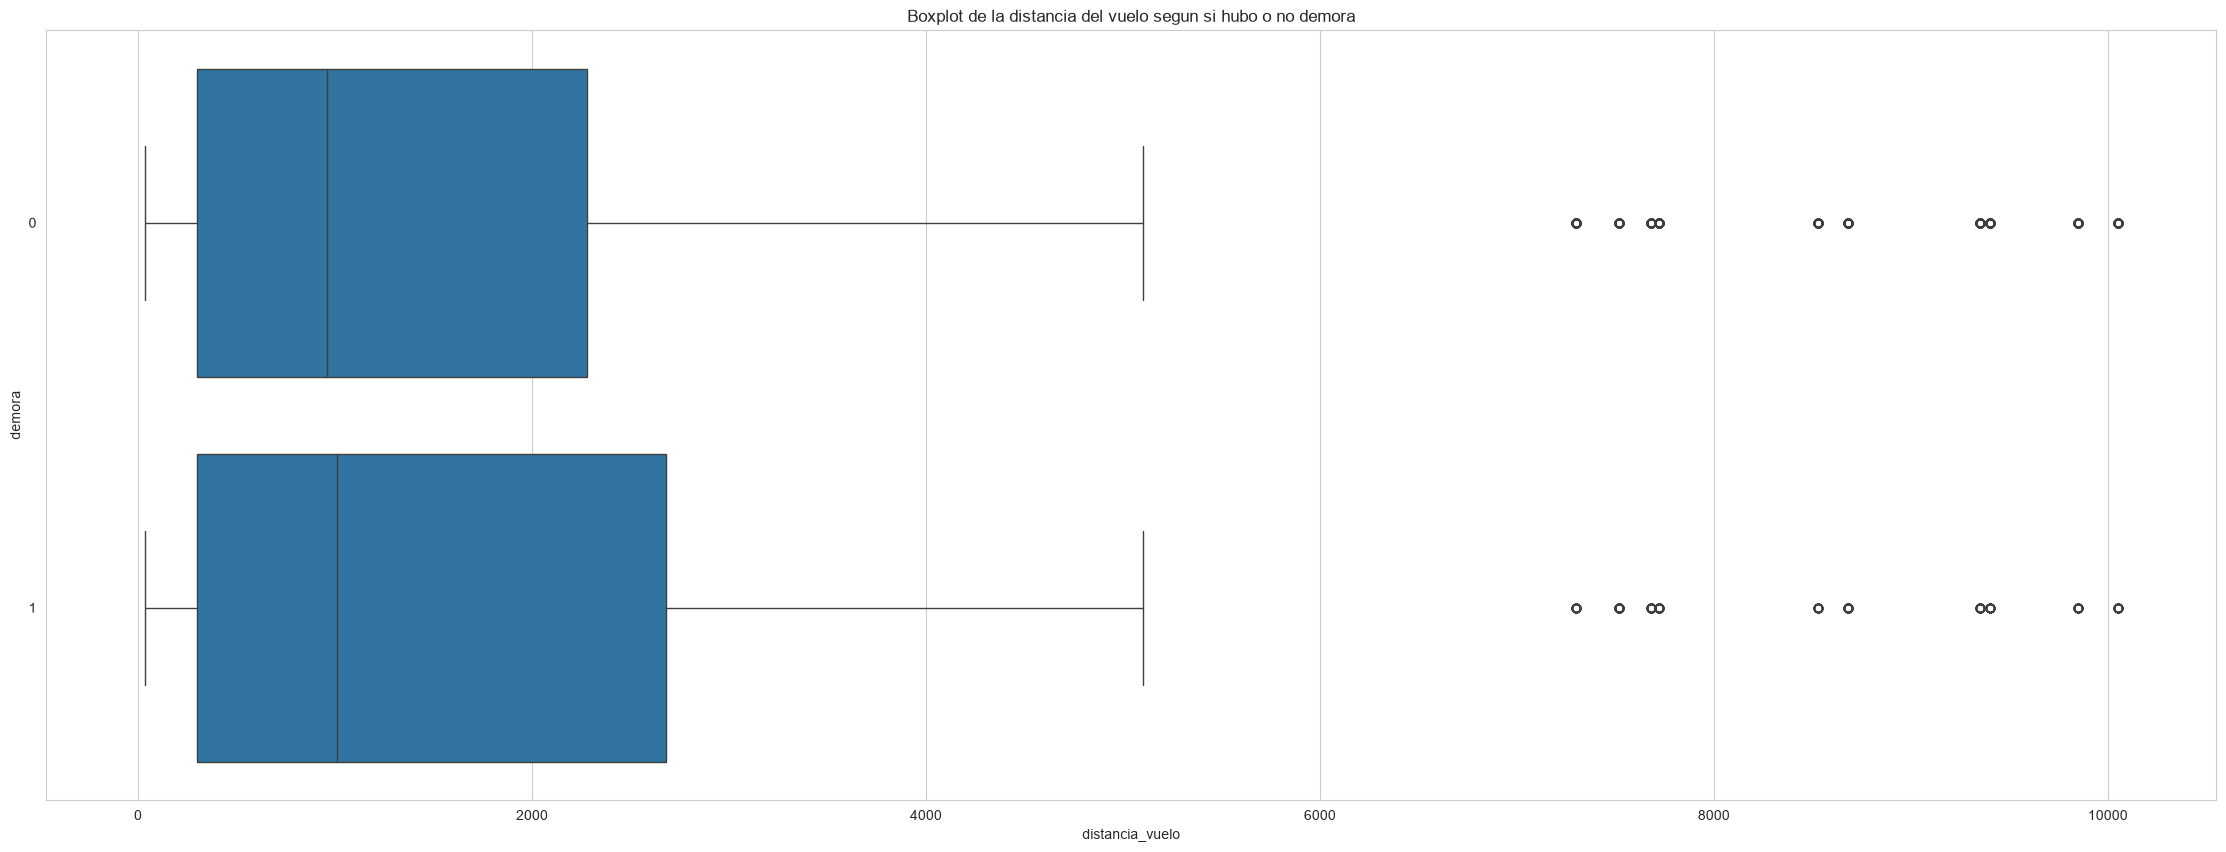

In [365]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.boxplot(data=data_vuelos, x="distancia_vuelo", y="demora")
ax.set_title("Boxplot de la distancia del vuelo segun si hubo o no demora")
plt.show()

In [366]:
'''
El boxplot de la distancia del vuelo segun si hubo o no demora muestra una distribucion practicamente identica para ambos casos ya que al observar las cajas podemos ver que el 50% central de los vuelos se concentran entre
los valores 300 y 2500km aproximadamente. Aunque la caja correspondiente a los vuelos demorados posee una leve extension hacia distancias mayores en su tercer cuartil es posible afirmar que la distancia del vuelo no tiene
un impacto directo ni relacion con la probabilidad de que el vuelo sufra una demora. Ademas, tambien se ven la existencia de outliers en el extremo derechos de ambas categorias lo cual implica que la existencia de vuelos
muy larga distancia ocurre tanto en aquellos que logran llegar a horario como en los que registran demora
'''

'\nEl boxplot de la distancia del vuelo segun si hubo o no demora muestra una distribucion practicamente identica para ambos casos ya que al observar las cajas podemos ver que el 50% central de los vuelos se concentran entre\nlos valores 300 y 2500km aproximadamente. Aunque la caja correspondiente a los vuelos demorados posee una leve extension hacia distancias mayores en su tercer cuartil es posible afirmar que la distancia del vuelo no tiene\nun impacto directo ni relacion con la probabilidad de que el vuelo sufra una demora. Ademas, tambien se ven la existencia de outliers en el extremo derechos de ambas categorias lo cual implica que la existencia de vuelos\nmuy larga distancia ocurre tanto en aquellos que logran llegar a horario como en los que registran demora\n'

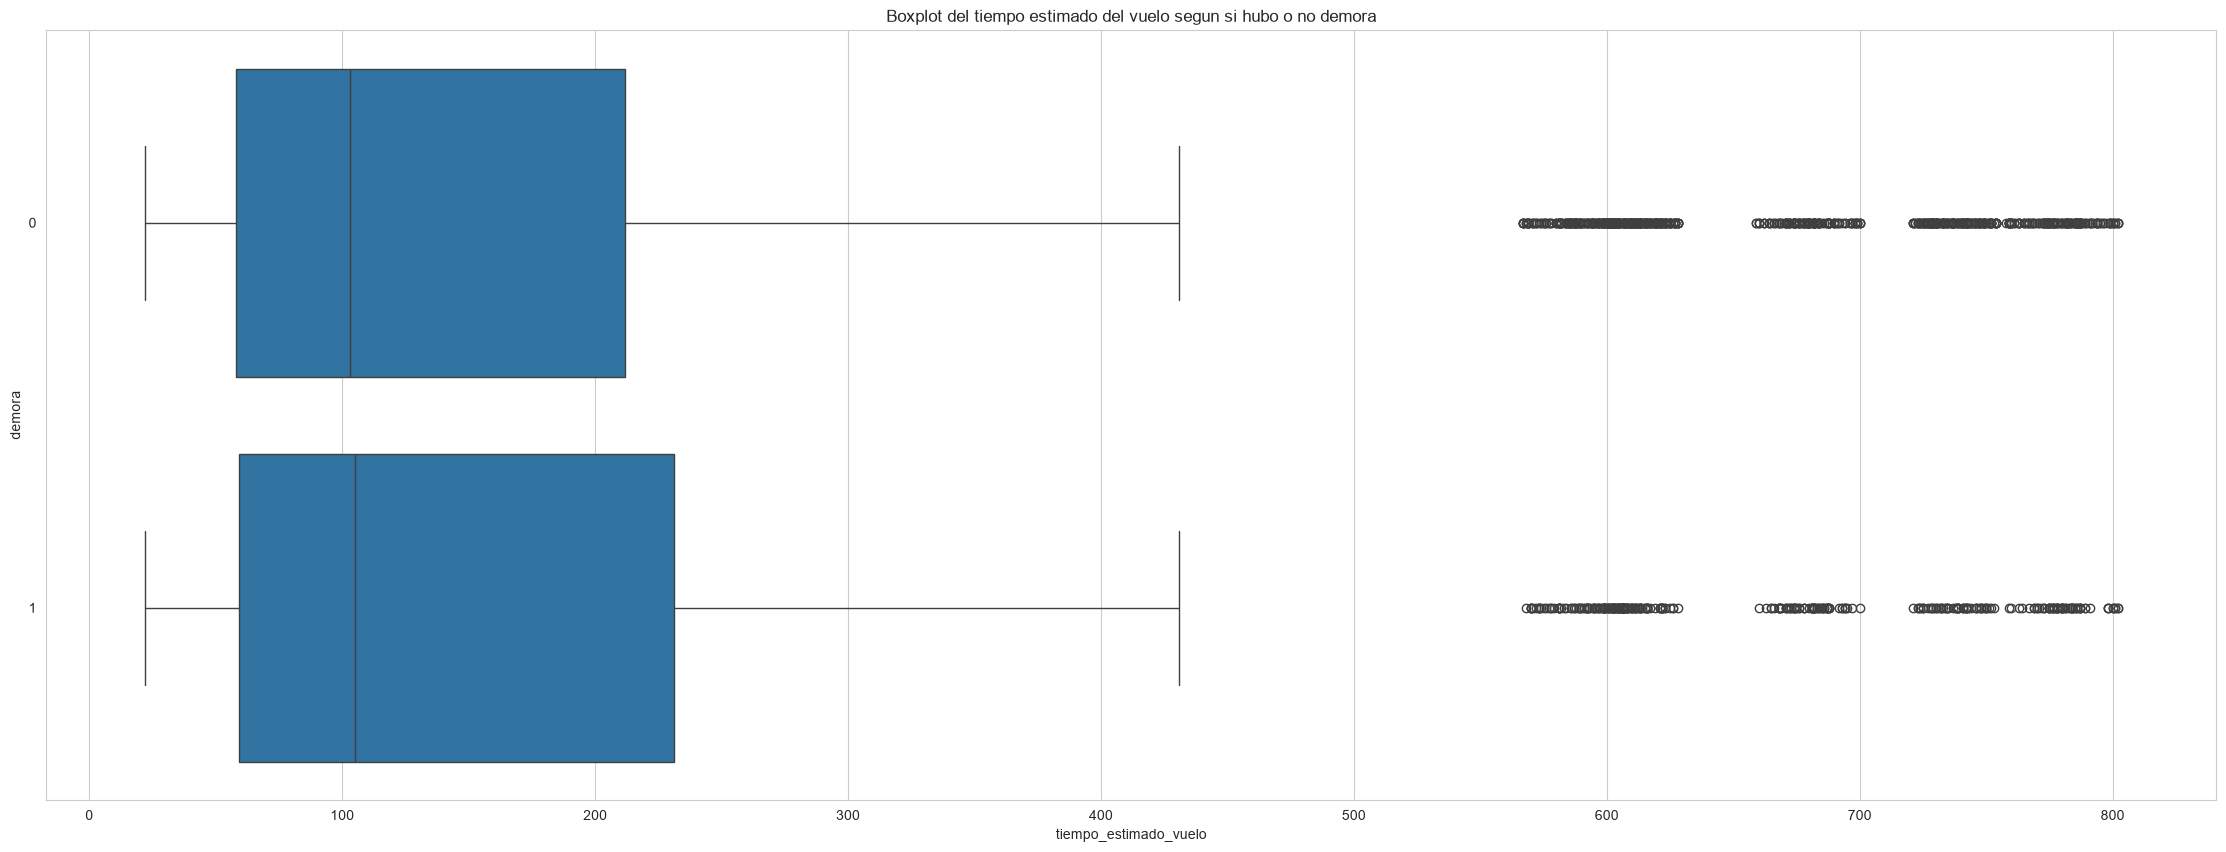

In [367]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.boxplot(data=data_vuelos, x="tiempo_estimado_vuelo", y="demora")
ax.set_title("Boxplot del tiempo estimado del vuelo segun si hubo o no demora")
plt.show()

In [368]:
'''
El boxplot del tiempo estimado de vuelo segun si hubo demora o no muestra distribuciones practicamente identicas en ambos escenarios ya que al observar las cajas podemos ver que el 50% central de los vuelos en ambos grupos
abarca un rango similar entre los 60 y 230 minutos aproximadamente, ademas, ambas medias se encuentran cercanas a 100. Esto indica claramente que la duracion prevista de un vuelo no es un factor determinante que influya
en la probabilidad de que un vuelo se retrase.
En ambas categorias se observa la existencia de outliers en el extremo derecho de las cajas lo cual indica que la existencia de vuelo de muy alta duracion prevista ocurren esporadicamente tanto en aquellos que logran llegar
a horario como en los que sufren demora

'''

'\nEl boxplot del tiempo estimado de vuelo segun si hubo demora o no muestra distribuciones practicamente identicas en ambos escenarios ya que al observar las cajas podemos ver que el 50% central de los vuelos en ambos grupos\nabarca un rango similar entre los 60 y 230 minutos aproximadamente, ademas, ambas medias se encuentran cercanas a 100. Esto indica claramente que la duracion prevista de un vuelo no es un factor determinante que influya\nen la probabilidad de que un vuelo se retrase.\nEn ambas categorias se observa la existencia de outliers en el extremo derecho de las cajas lo cual indica que la existencia de vuelo de muy alta duracion prevista ocurren esporadicamente tanto en aquellos que logran llegar\na horario como en los que sufren demora\n\n'

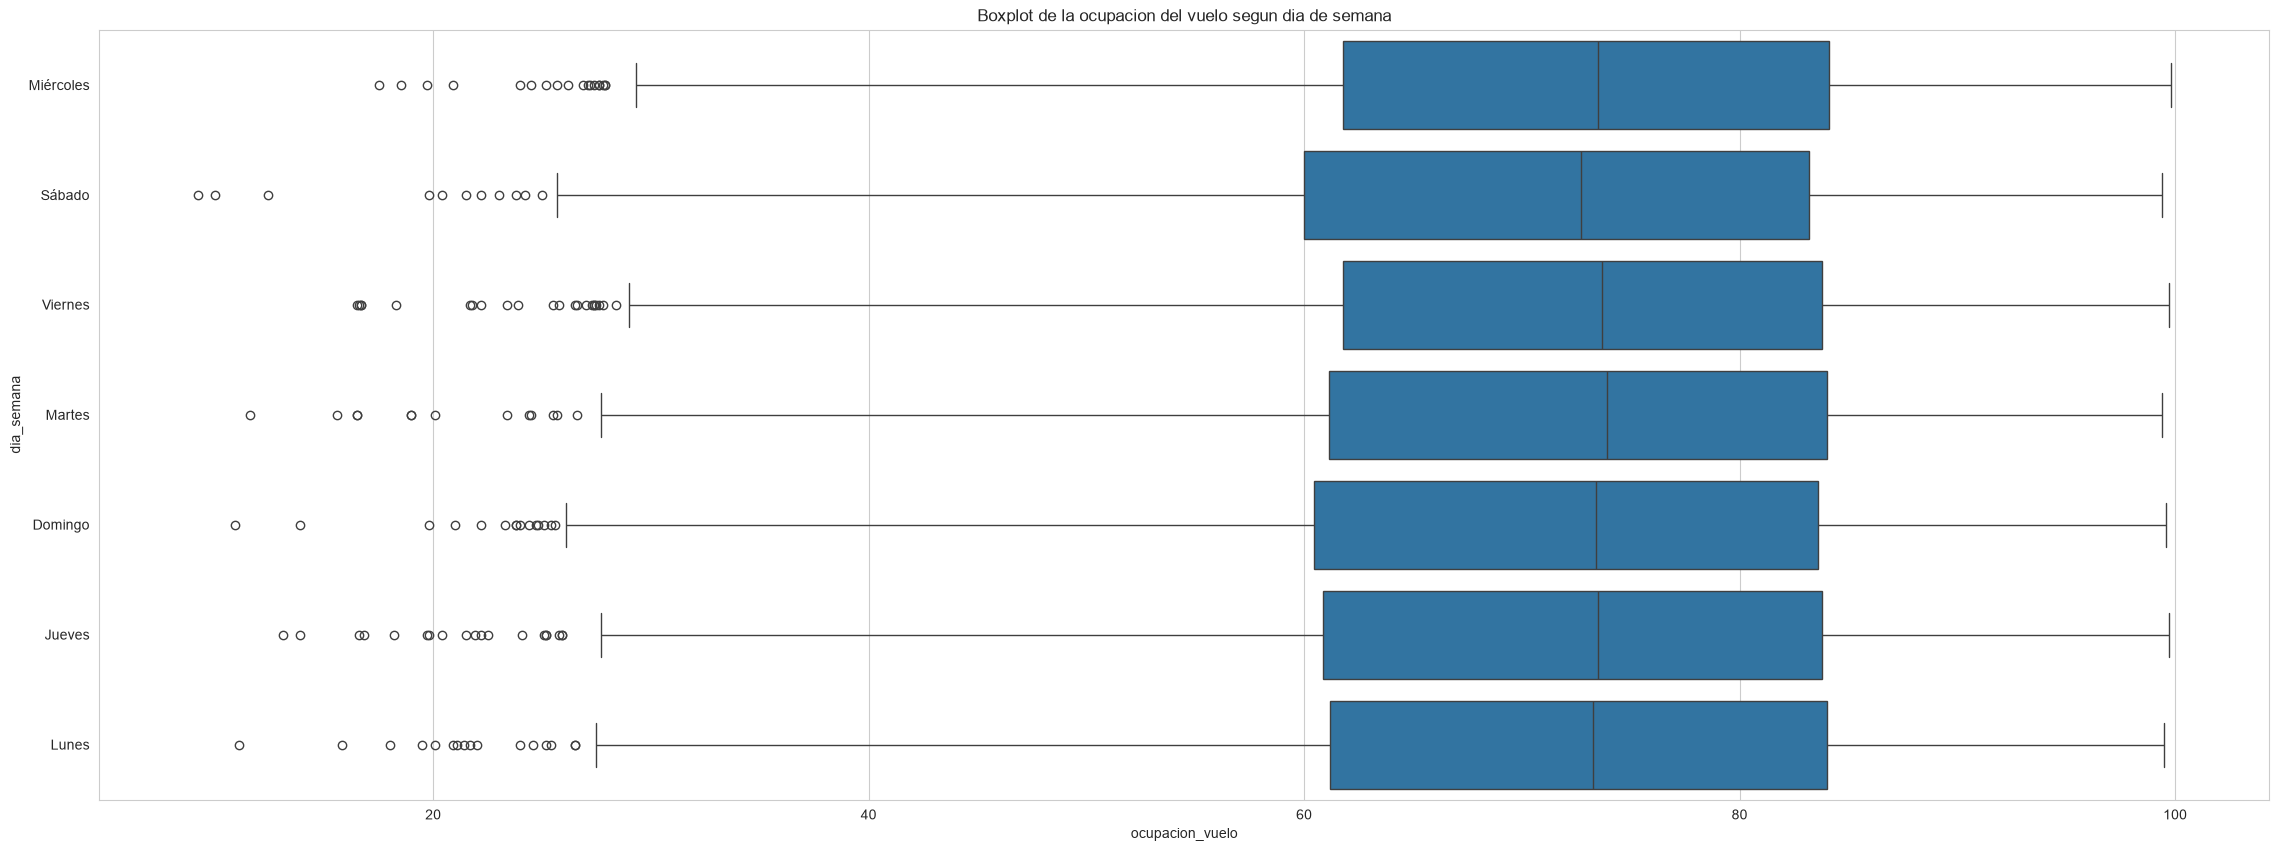

In [369]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.boxplot(data=data_vuelos, x="ocupacion_vuelo", y="dia_semana")
ax.set_title("Boxplot de la ocupacion del vuelo segun dia de semana")
plt.show()

In [370]:
'''
El boxplot de la ocupacion del vuelo segun el dia de semana revela uniformidad a lo largo de toda la semana ya que al observar las cajas podemos ver que el 50% central de los vuelos ocupa un rango de ocupaciones
practicamente identico sin importar el dia de la semana. Esto indica que el dia de la semana no es un factor determinante que altere el buen nivel de demanda habitual de las operaciones
Tambien se puede identificar la presencia de outliers en el extremo izquierdo de todas las cajas concluyendo asi que la existencia de vuelos semi-vacios es un fenomeno transversal a toda la semana
'''

'\nEl boxplot de la ocupacion del vuelo segun el dia de semana revela uniformidad a lo largo de toda la semana ya que al observar las cajas podemos ver que el 50% central de los vuelos ocupa un rango de ocupaciones\npracticamente identico sin importar el dia de la semana. Esto indica que el dia de la semana no es un factor determinante que altere el buen nivel de demanda habitual de las operaciones\nTambien se puede identificar la presencia de outliers en el extremo izquierdo de todas las cajas concluyendo asi que la existencia de vuelos semi-vacios es un fenomeno transversal a toda la semana\n'

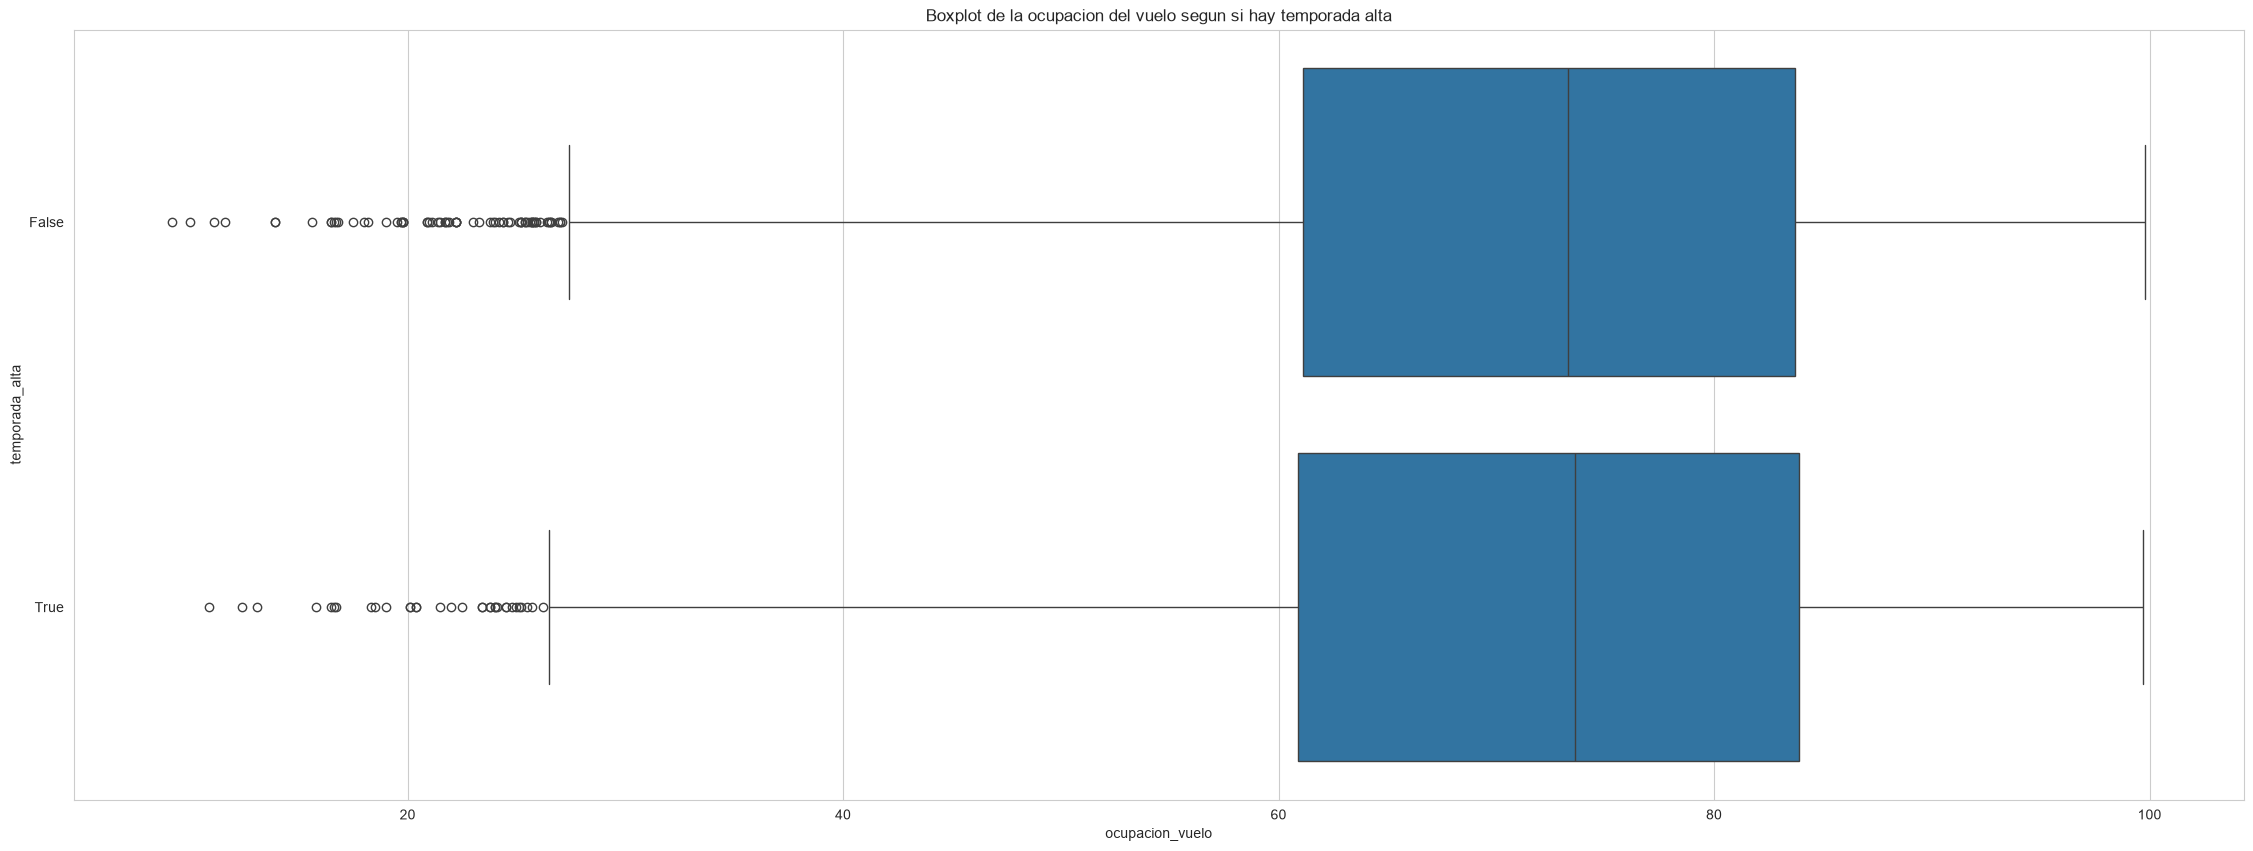

In [371]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.boxplot(data=data_vuelos, x="ocupacion_vuelo", y="temporada_alta")
ax.set_title("Boxplot de la ocupacion del vuelo segun si hay temporada alta")
plt.show()

In [372]:
'''
El boxplot de la ocupacion del vuelo segun si hay temporada alta o no muestra que las distribuciones de ambos grupos son practicamente identicas ya que al observar las cajas se puede ver que el 50% central de los vuelos
tanto en temporada alta como en temporada normal opera con rangos de ocupaciones similares, concentrandose entre valores de 60% y 85%. Esto indica, contraintuitivamente, que la temporada alta no afecta significativamente
los niveles de ocupacion de los vuelos.
En ambas categorias se aprecia la existencia de outliers en el extremo izquierdo de las cajas lo cual confirma que la existencia esporadica de vuelos semi-vacios ocurre tanto en temporada alta como en temporada normal
'''

'\nEl boxplot de la ocupacion del vuelo segun si hay temporada alta o no muestra que las distribuciones de ambos grupos son practicamente identicas ya que al observar las cajas se puede ver que el 50% central de los vuelos\ntanto en temporada alta como en temporada normal opera con rangos de ocupaciones similares, concentrandose entre valores de 60% y 85%. Esto indica, contraintuitivamente, que la temporada alta no afecta significativamente\nlos niveles de ocupacion de los vuelos.\nEn ambas categorias se aprecia la existencia de outliers en el extremo izquierdo de las cajas lo cual confirma que la existencia esporadica de vuelos semi-vacios ocurre tanto en temporada alta como en temporada normal\n'

##Barras Estratificadas

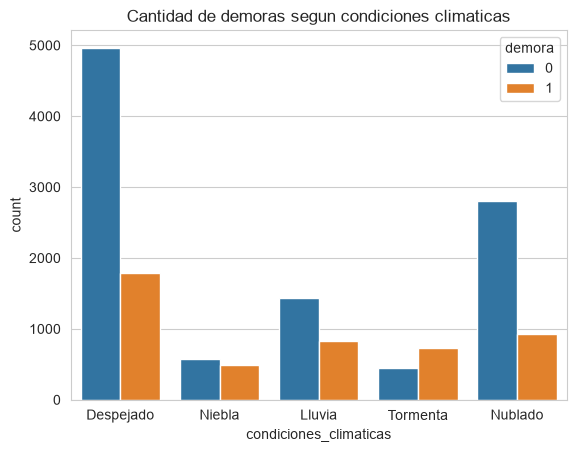

In [373]:
sns.countplot(data=data_vuelos, x="condiciones_climaticas", hue="demora")
plt.title("Cantidad de demoras segun condiciones climaticas")
plt.show()

In [374]:
'''
La grafica muestra una disparidad significativa en la incidencia de demoras según el estado del tiempo. Mientras que la variable "Despejado" presenta el mayor volumen de
operaciones , la categoría de "Tormenta" es la única donde la frecuencia de vuelos demorados supera a los vuelos a tiempo , estableciendo al clima severo como un factor crítico de
riesgo operativo con una alta probabilidad de retraso.
'''

'\nLa grafica muestra una disparidad significativa en la incidencia de demoras según el estado del tiempo. Mientras que la variable "Despejado" presenta el mayor volumen de\noperaciones , la categoría de "Tormenta" es la única donde la frecuencia de vuelos demorados supera a los vuelos a tiempo , estableciendo al clima severo como un factor crítico de\nriesgo operativo con una alta probabilidad de retraso.\n'

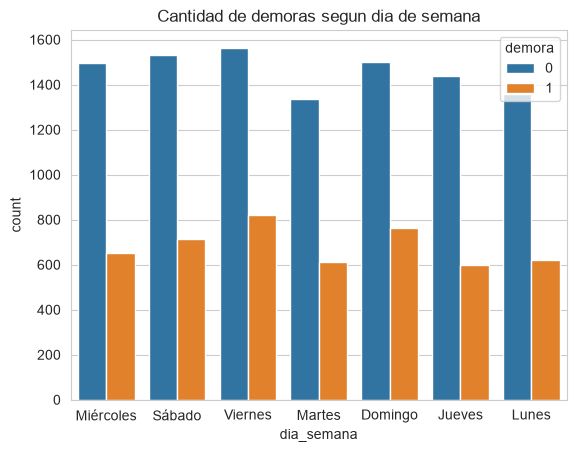

In [375]:
sns.countplot(data=data_vuelos, x="dia_semana", hue="demora")
plt.title("Cantidad de demoras segun dia de semana")
plt.show()

In [376]:
'''
Cantidad de demoras por día de la semana: Se observa una distribución de frecuencias practicamente uniforme a lo largo de la semana, lo que sugiere que el factor temporal por día
no influye en la probabilidad de demora.
'''

'\nCantidad de demoras por día de la semana: Se observa una distribución de frecuencias practicamente uniforme a lo largo de la semana, lo que sugiere que el factor temporal por día\nno influye en la probabilidad de demora.\n'

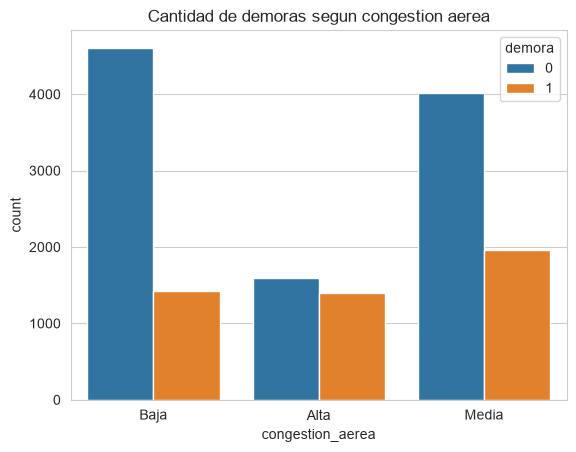

In [377]:
sns.countplot(data=data_vuelos, x="congestion_aerea", hue="demora")
plt.title("Cantidad de demoras segun congestion aerea")
plt.show()

In [378]:
'''
El gráfico de barras Cantidad de demoras por congestión permite analizar la incidencia de la variable Demorado según el nivel de Congestión Aérea. En la categoría Baja, se observa
la mayor eficiencia operativa con una baja tasa de demoras a pesar del alto volumen de vuelos. Sin embargo, en la congestión Alta, las clases se equilibran casi totalmente,
indicando que el tráfico intenso es un predictor crítico que eleva la probabilidad de demora a niveles de incertidumbre. Finalmente, en la categoría Media, se mantiene una mayoría
de vuelos puntuales, aunque con un volumen de demoras superior al escenario de alta congestión
'''

'\nEl gráfico de barras Cantidad de demoras por congestión permite analizar la incidencia de la variable Demorado según el nivel de Congestión Aérea. En la categoría Baja, se observa\nla mayor eficiencia operativa con una baja tasa de demoras a pesar del alto volumen de vuelos. Sin embargo, en la congestión Alta, las clases se equilibran casi totalmente,\nindicando que el tráfico intenso es un predictor crítico que eleva la probabilidad de demora a niveles de incertidumbre. Finalmente, en la categoría Media, se mantiene una mayoría\nde vuelos puntuales, aunque con un volumen de demoras superior al escenario de alta congestión\n'

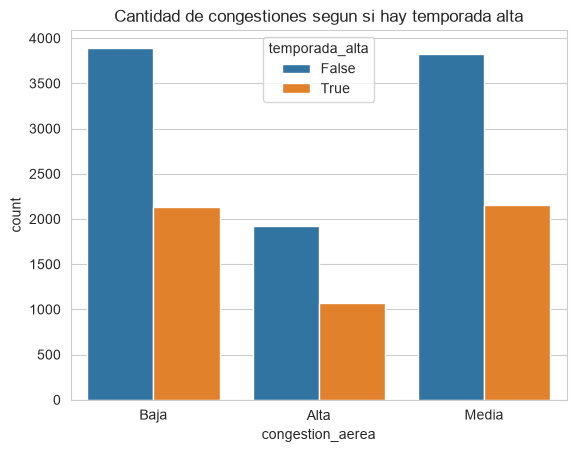

In [379]:
sns.countplot(data=data_vuelos, x="congestion_aerea", hue="temporada_alta")
plt.title("Cantidad de congestiones segun si hay temporada alta")
plt.show()

In [380]:
'''
'''

'\n'

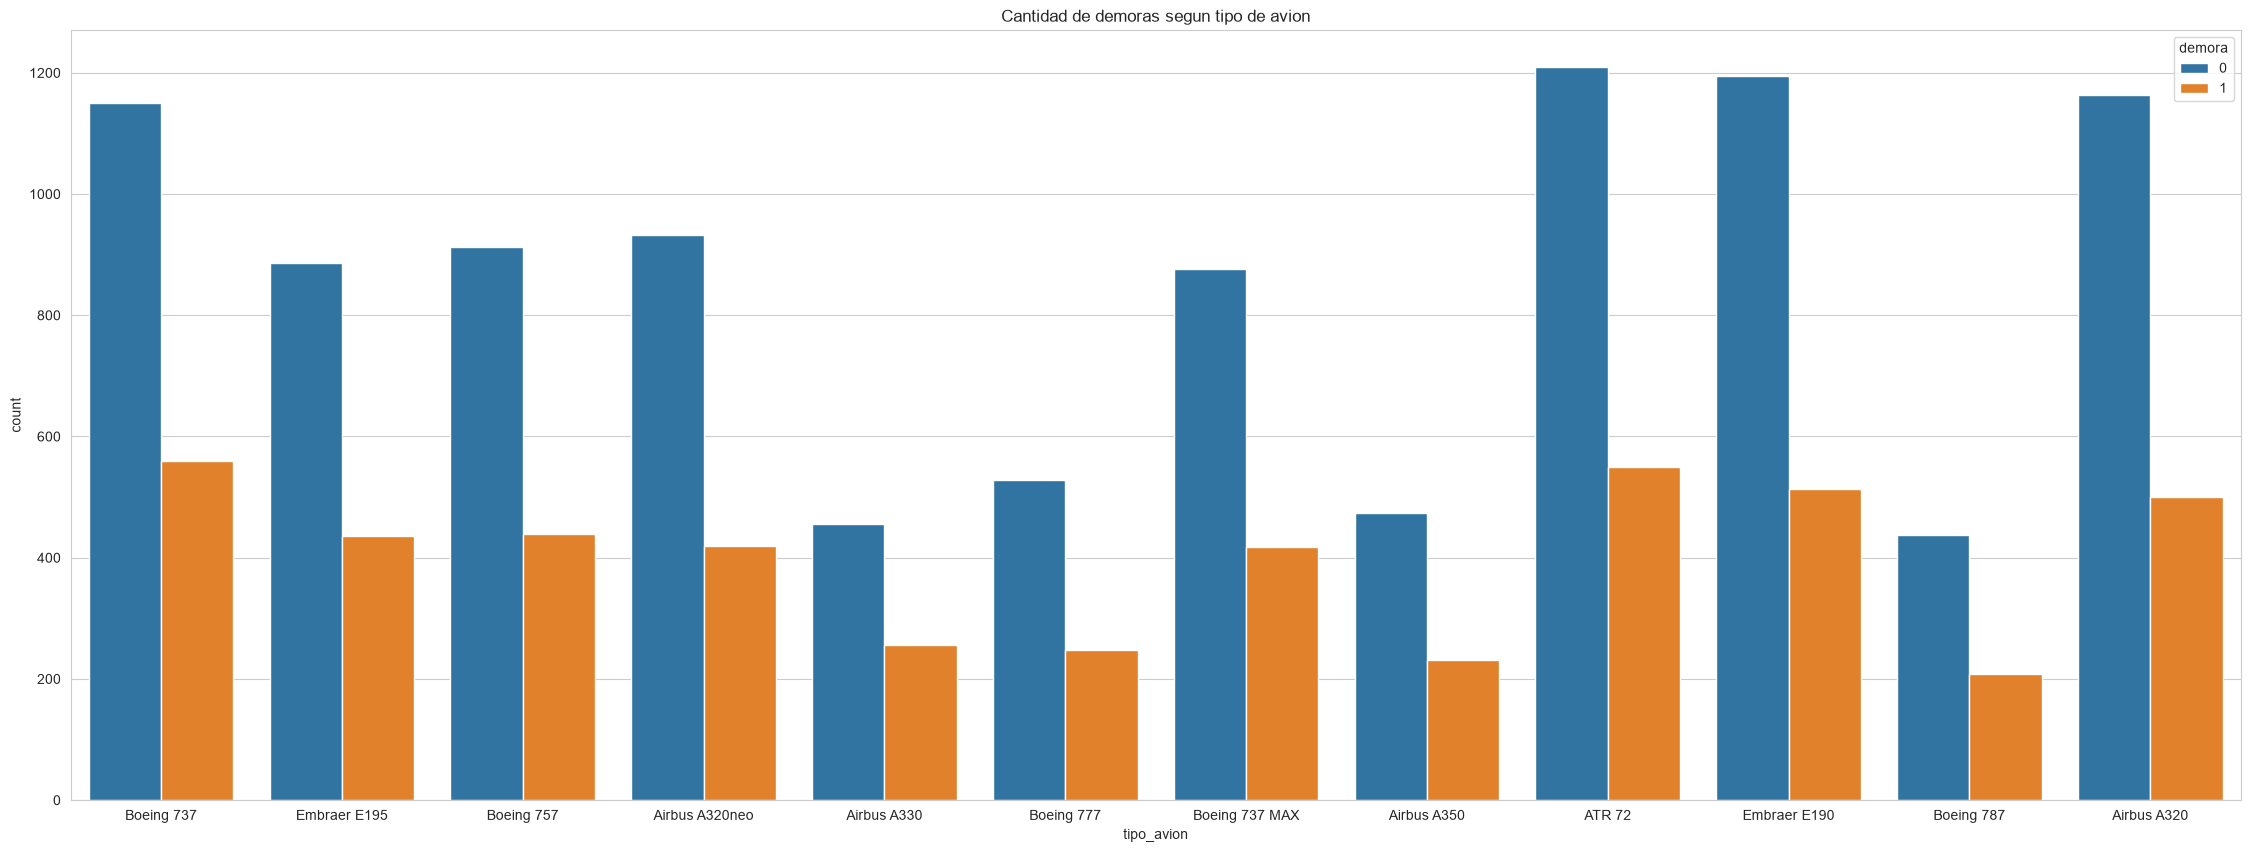

In [381]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.countplot(data=data_vuelos, x="tipo_avion", hue="demora")
ax.set_title("Cantidad de demoras segun tipo de avion")
plt.show()

In [382]:
'''
El gráfico de barras Cantidad de demoras por tipo de avión permite analizar la relación entre el Tipo de avión y la variable Demorado para las distintas aeronaves. A nivel general,
se observa que en todos los modelos la cantidad de vuelos a tiempo supera a los demorados, manteniendo una distribución proporcionalmente similar independientemente de si son
aviones de corto o largo alcance. Modelos con alta frecuencia operativa, como el Boeing 737, el ATR 72 y el Embraer E190, concentran el mayor número absoluto de demoras, aunque
conservan una tasa de puntualidad saludable. Por el contrario, aeronaves como el Airbus A330, A350 y el Boeing 787 presentan un volumen de registros menor, reflejando su uso en
rutas específicas de mayor distancia. En conclusión, el tipo de avión no parece ser un factor discriminante crítico por sí solo para predecir demoras
'''

'\nEl gráfico de barras Cantidad de demoras por tipo de avión permite analizar la relación entre el Tipo de avión y la variable Demorado para las distintas aeronaves. A nivel general,\nse observa que en todos los modelos la cantidad de vuelos a tiempo supera a los demorados, manteniendo una distribución proporcionalmente similar independientemente de si son\naviones de corto o largo alcance. Modelos con alta frecuencia operativa, como el Boeing 737, el ATR 72 y el Embraer E190, concentran el mayor número absoluto de demoras, aunque\nconservan una tasa de puntualidad saludable. Por el contrario, aeronaves como el Airbus A330, A350 y el Boeing 787 presentan un volumen de registros menor, reflejando su uso en\nrutas específicas de mayor distancia. En conclusión, el tipo de avión no parece ser un factor discriminante crítico por sí solo para predecir demoras\n'

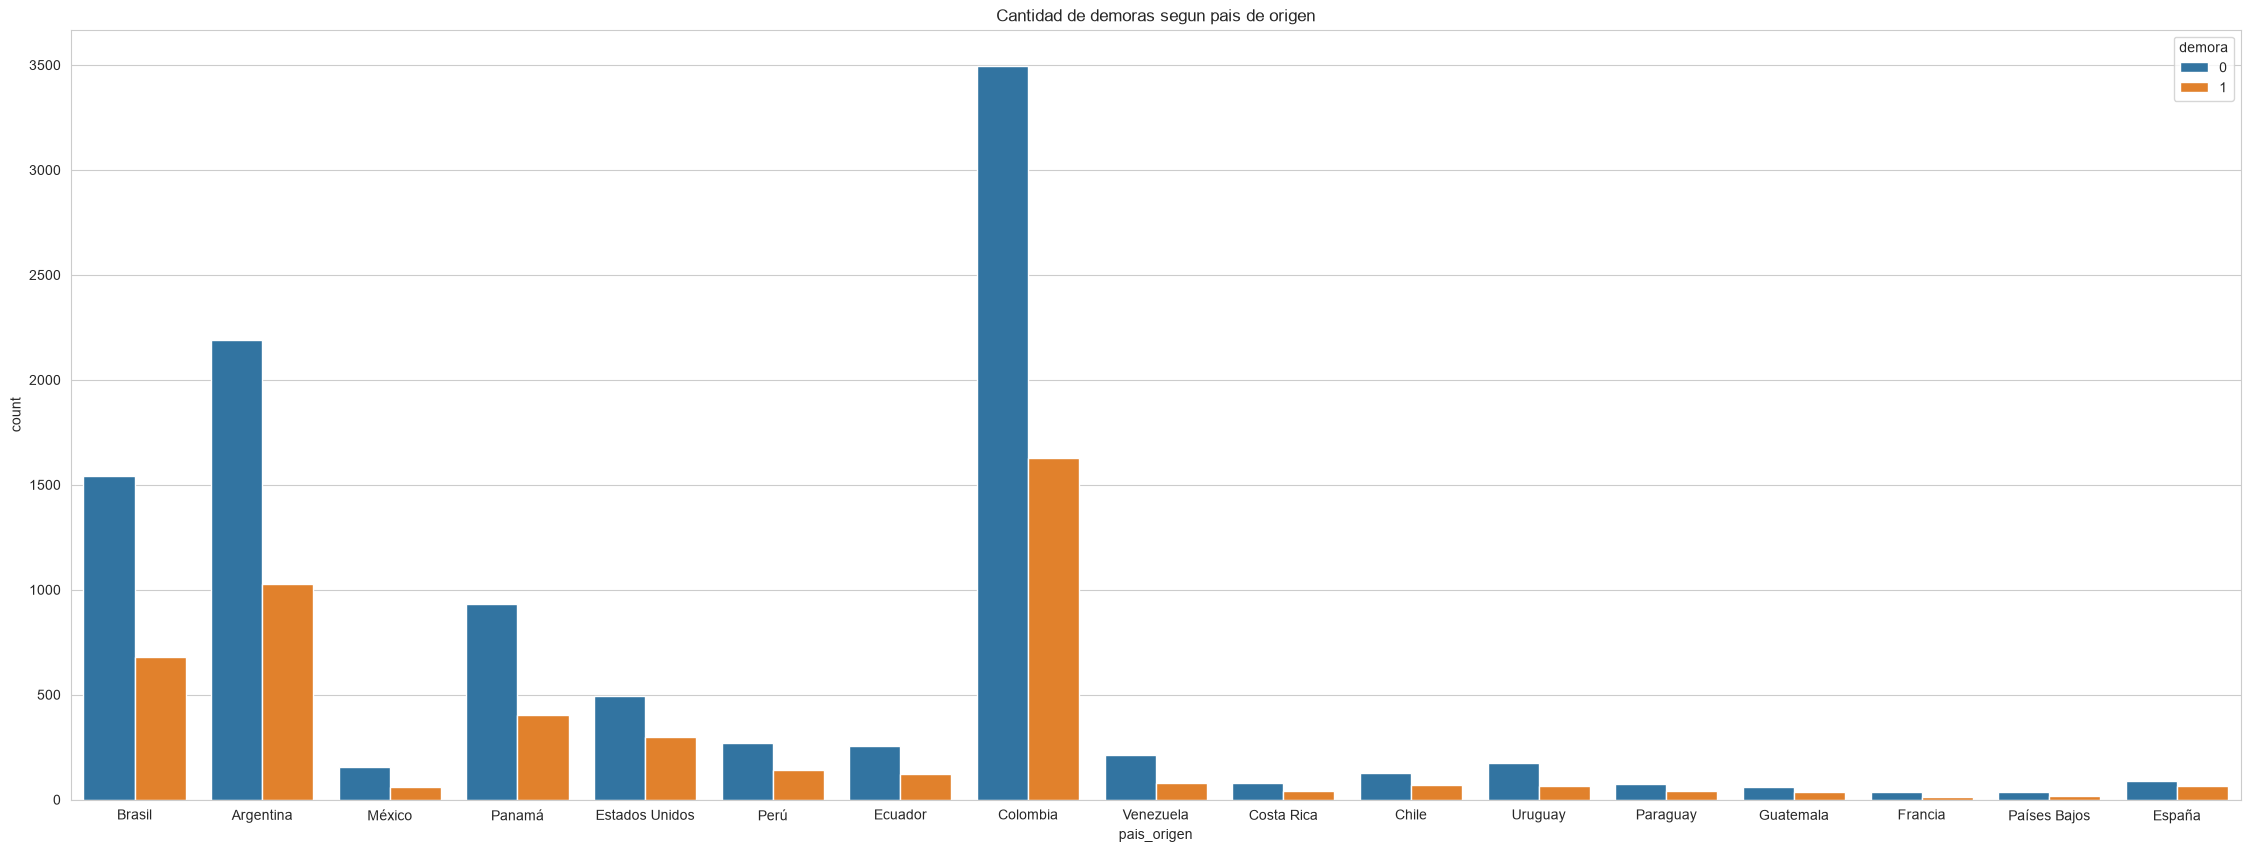

In [383]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.countplot(data=data_vuelos, x="pais_origen", hue="demora")
ax.set_title("Cantidad de demoras segun pais de origen")
plt.show()

In [384]:
'''
La gráfica muestra la cantidad de vuelos por aeropuerto de origen, dejando claro que terminales EZE, BOG y MDE son los centros con más actividad y, por lo tanto, donde se
concentran más demoras. Aunque estos aeropuertos tienen muchísimos más vuelos que el resto, la proporción de retrasos  se mantiene parecida en casi todos, lo que indica que el
tráfico está muy centralizado en unos pocos puntos clave
'''

'\nLa gráfica muestra la cantidad de vuelos por aeropuerto de origen, dejando claro que terminales EZE, BOG y MDE son los centros con más actividad y, por lo tanto, donde se\nconcentran más demoras. Aunque estos aeropuertos tienen muchísimos más vuelos que el resto, la proporción de retrasos  se mantiene parecida en casi todos, lo que indica que el\ntráfico está muy centralizado en unos pocos puntos clave\n'

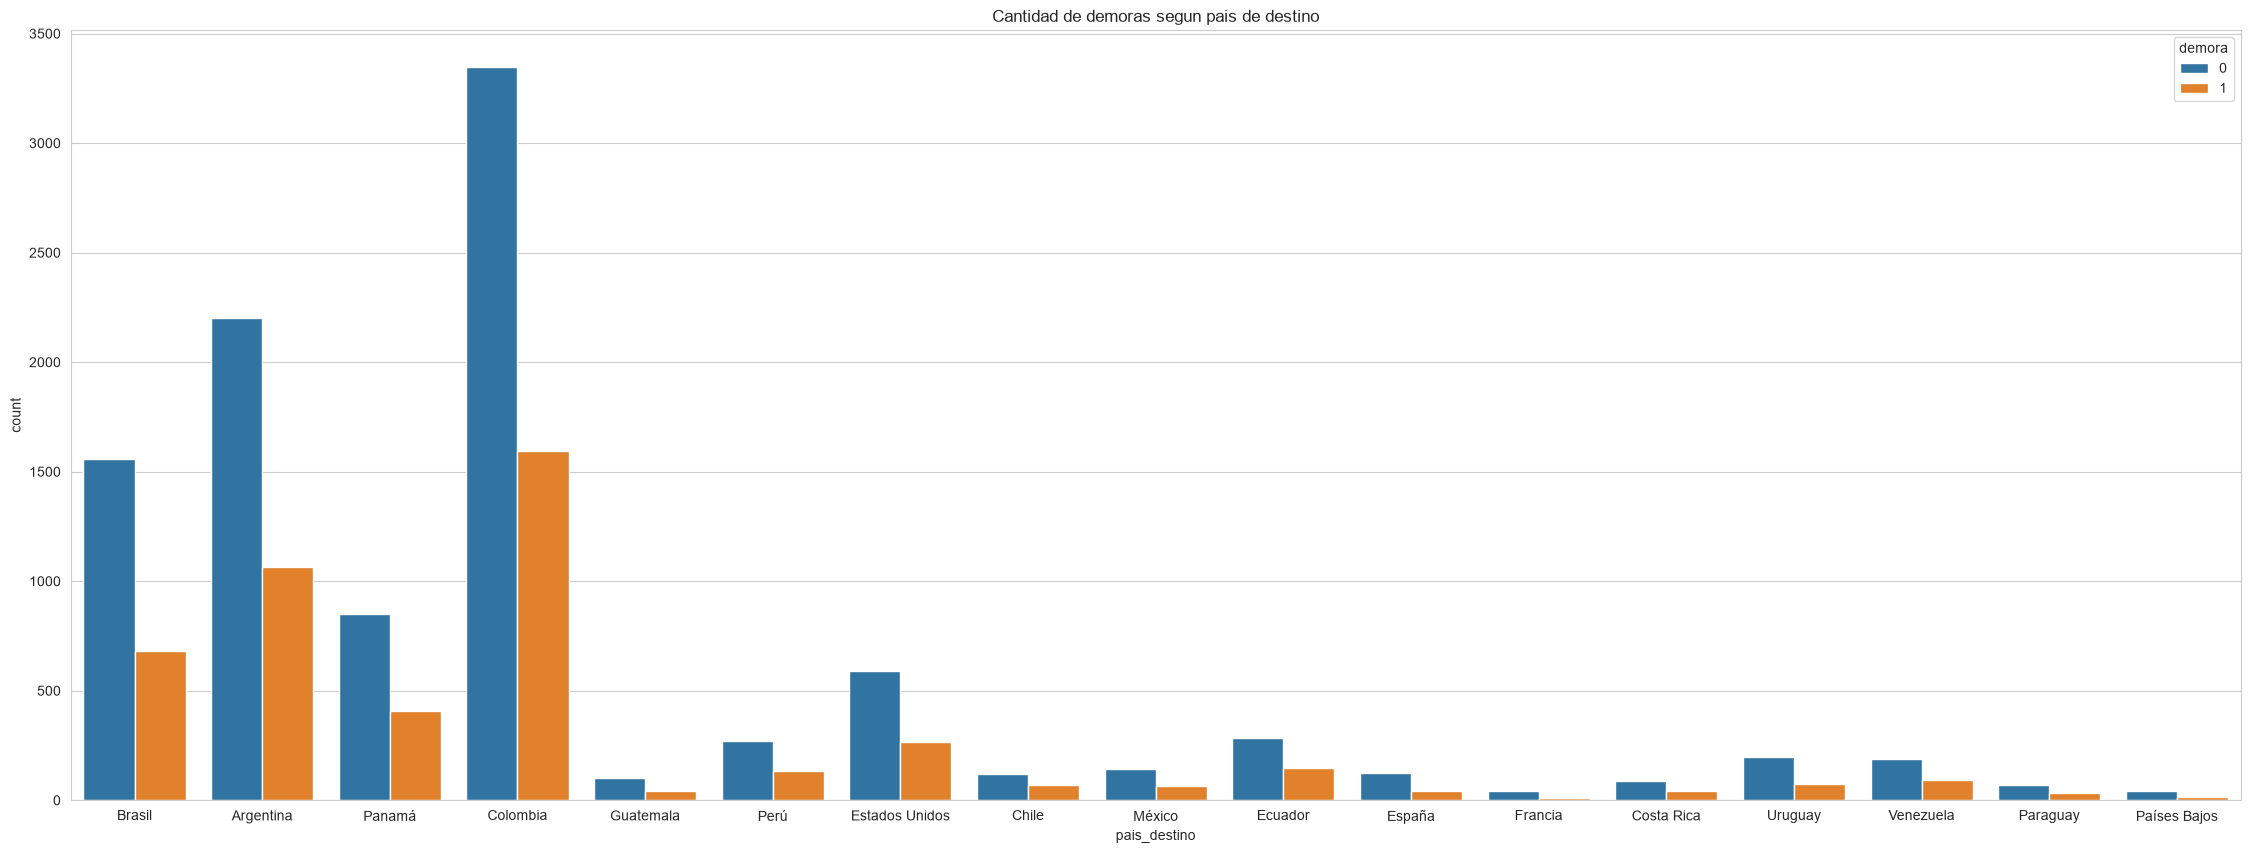

In [385]:
fig,ax = plt.subplots(1, 1, figsize=(28, 10))
sns.countplot(data=data_vuelos, x="pais_destino", hue="demora")
ax.set_title("Cantidad de demoras segun pais de destino")
plt.show()

In [386]:
'''
'''

'\n'

#Analisis Clientes

##Medidas de Posicion

In [387]:
data_clientes.describe(include='all')

,sexo,provincia,edad,ocupacion,cant_vuelos,clase_preferida,gasto_acumulado,gasto_acumulado_extra,programaMillas,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,canal_compra
count,50000,50000,50000.000000,50000,50000.000000,50000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.00000,50000
unique,3,31,NaN,15,NaN,3,NaN,NaN,2,NaN,NaN,NaN,4
top,M,Entre Ríos,NaN,Empleado,NaN,Económica,NaN,NaN,No,NaN,NaN,NaN,Web
freq,24973,2417,NaN,11430,NaN,37093,NaN,NaN,38052,NaN,NaN,NaN,19743
mean,NaN,NaN,37.827400,NaN,17.071860,NaN,6587.557023,953.732059,NaN,6759.361980,3062.882160,19.91066,NaN
std,NaN,NaN,11.479385,NaN,15.750424,NaN,12439.879256,1987.615263,NaN,23529.642402,3780.380841,21.40158,NaN
min,NaN,NaN,18.000000,NaN,1.000000,NaN,71.250000,3.210000,NaN,0.000000,300.000000,0.00000,NaN
25%,NaN,NaN,29.000000,NaN,6.000000,NaN,1404.575000,167.480000,NaN,0.000000,1250.000000,5.00000,NaN
50%,NaN,NaN,38.000000,NaN,14.000000,NaN,3099.895000,403.255000,NaN,0.000000,2100.000000,13.00000,NaN
75%,NaN,NaN,46.000000,NaN,21.000000,NaN,6317.357500,912.547500,NaN,0.000000,3823.000000,27.00000,NaN


In [388]:
data_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   sexo                          50000 non-null  str    
 1   provincia                     50000 non-null  str    
 2   edad                          50000 non-null  int64  
 3   ocupacion                     50000 non-null  str    
 4   cant_vuelos                   50000 non-null  int64  
 5   clase_preferida               50000 non-null  str    
 6   gasto_acumulado               50000 non-null  float64
 7   gasto_acumulado_extra         50000 non-null  float64
 8   programaMillas                50000 non-null  str    
 9   cantidad_millas               50000 non-null  int64  
 10  ingreso_mensual               50000 non-null  int64  
 11  anticipacion_compra_promedio  50000 non-null  int64  
 12  canal_compra                  50000 non-null  str    
dtypes: float64(2

In [389]:
data_clientes['sexo'].value_counts()

sexo
M             24973
F             24515
No binario      512
Name: count, dtype: int64

In [390]:
data_clientes['sexo'].value_counts() / data_clientes.shape[0] * 100

sexo
M             49.946
F             49.030
No binario     1.024
Name: count, dtype: float64

In [391]:
data_clientes['provincia'].value_counts()

provincia
Entre Ríos           2417
Buenos Aires         2390
Chaco                2388
Salta                2370
Córdoba              2349
Mendoza              2338
Santa Fe             2331
Misiones             2322
CABA                 2315
Tucumán              2289
Bolívar              1627
Antioquia            1596
Valle del Cauca      1570
Atlántico            1563
Santander            1561
Nariño               1547
Tolima               1544
Cundinamarca         1519
Paraná               1196
Rio de Janeiro       1192
São Paulo            1189
Pernambuco           1175
Minas Gerais         1149
Rio Grande do Sul    1147
Bahia                1143
Los Santos            978
Chiriquí              972
Panamá                964
Colón                 963
Veraguas              955
Herrera               941
Name: count, dtype: int64

In [392]:
data_clientes['provincia'].value_counts() / data_clientes.shape[0] * 100

provincia
Entre Ríos           4.834
Buenos Aires         4.780
Chaco                4.776
Salta                4.740
Córdoba              4.698
Mendoza              4.676
Santa Fe             4.662
Misiones             4.644
CABA                 4.630
Tucumán              4.578
Bolívar              3.254
Antioquia            3.192
Valle del Cauca      3.140
Atlántico            3.126
Santander            3.122
Nariño               3.094
Tolima               3.088
Cundinamarca         3.038
Paraná               2.392
Rio de Janeiro       2.384
São Paulo            2.378
Pernambuco           2.350
Minas Gerais         2.298
Rio Grande do Sul    2.294
Bahia                2.286
Los Santos           1.956
Chiriquí             1.944
Panamá               1.928
Colón                1.926
Veraguas             1.910
Herrera              1.882
Name: count, dtype: float64

In [393]:
data_clientes['ocupacion'].value_counts()

ocupacion
Empleado                     11430
Docente                       4378
Profesional independiente     4378
Estudiante                    3615
Ejecutivo                     3535
Comerciante                   3446
Ingeniero                     3053
Empresario                    2979
Otro                          2973
Médico                        2582
Abogado                       2115
Contador                      2063
Arquitecto                    1673
Deportista                    1268
Jubilado                       512
Name: count, dtype: int64

In [394]:
data_clientes['ocupacion'].value_counts() / data_clientes.shape[0] * 100

ocupacion
Empleado                     22.860
Docente                       8.756
Profesional independiente     8.756
Estudiante                    7.230
Ejecutivo                     7.070
Comerciante                   6.892
Ingeniero                     6.106
Empresario                    5.958
Otro                          5.946
Médico                        5.164
Abogado                       4.230
Contador                      4.126
Arquitecto                    3.346
Deportista                    2.536
Jubilado                      1.024
Name: count, dtype: float64

In [395]:
data_clientes['clase_preferida'].value_counts()

clase_preferida
Económica        37093
Ejecutiva        10937
Primera clase     1970
Name: count, dtype: int64

In [396]:
data_clientes['clase_preferida'].value_counts() / data_clientes.shape[0] * 100

clase_preferida
Económica        74.186
Ejecutiva        21.874
Primera clase     3.940
Name: count, dtype: float64

In [397]:
data_clientes['programaMillas'].value_counts()

programaMillas
No    38052
Sí    11948
Name: count, dtype: int64

In [398]:
data_clientes['programaMillas'].value_counts() / data_clientes.shape[0] * 100

programaMillas
No    76.104
Sí    23.896
Name: count, dtype: float64

In [399]:
data_clientes['canal_compra'].value_counts()

canal_compra
Web           19743
App           18514
Agencia        7300
Aeropuerto     4443
Name: count, dtype: int64

In [400]:
data_clientes['canal_compra'].value_counts() / data_clientes.shape[0] * 100

canal_compra
Web           39.486
App           37.028
Agencia       14.600
Aeropuerto     8.886
Name: count, dtype: float64

##Medidas de Dispersion

###Varianza

In [401]:
data_clientes.var(numeric_only=True)

edad                            1.317763e+02
cant_vuelos                     2.480759e+02
gasto_acumulado                 1.547506e+08
gasto_acumulado_extra           3.950614e+06
cantidad_millas                 5.536441e+08
ingreso_mensual                 1.429128e+07
anticipacion_compra_promedio    4.580276e+02
dtype: float64

###Desvio Estandar

In [402]:
data_clientes.std(numeric_only=True)

edad                               11.479385
cant_vuelos                        15.750424
gasto_acumulado                 12439.879256
gasto_acumulado_extra            1987.615263
cantidad_millas                 23529.642402
ingreso_mensual                  3780.380841
anticipacion_compra_promedio       21.401580
dtype: float64

##Histogramas y Boxplots

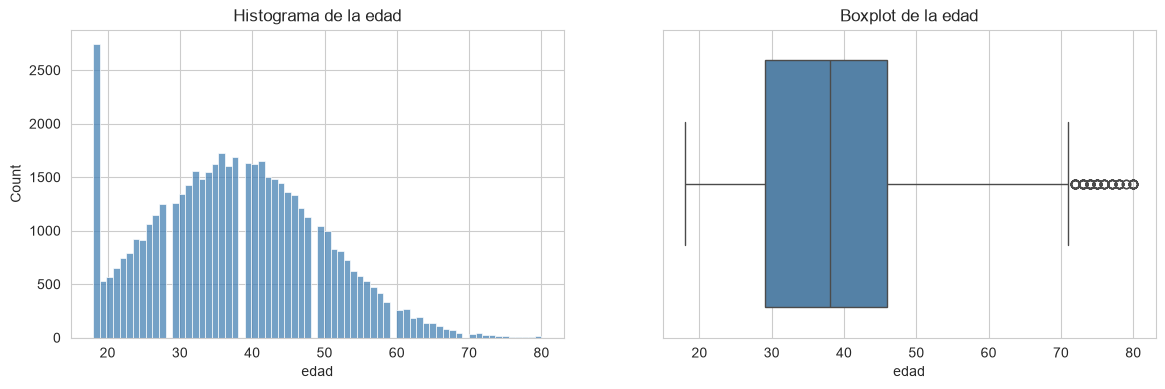

In [403]:
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_clientes, x="edad", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de la edad")
sns.boxplot(data=data_clientes, x="edad", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de la edad")
plt.show()

In [404]:
'''
El análisis de la variable Edad refleja una distribución con un ligero sesgo a la derecha, donde la mayor concentración de pasajeros se sitúa entre los 29 y 46 años de edad
aproximadamente, con una mediana cercana a los 38 años.
El Histograma muestra un pico inicial notable en los 18-20 años, seguido de una frecuencia predominante en la edad adulta
media. Por otro lado, el Boxplot permite identificar la presencia de outliers a partir de los 72 años, indicando que los pasajeros de edad avanzada son casos atípicos.
'''

'\nEl análisis de la variable Edad refleja una distribución con un ligero sesgo a la derecha, donde la mayor concentración de pasajeros se sitúa entre los 29 y 46 años de edad\naproximadamente, con una mediana cercana a los 38 años.\nEl Histograma muestra un pico inicial notable en los 18-20 años, seguido de una frecuencia predominante en la edad adulta\nmedia. Por otro lado, el Boxplot permite identificar la presencia de outliers a partir de los 72 años, indicando que los pasajeros de edad avanzada son casos atípicos.\n'

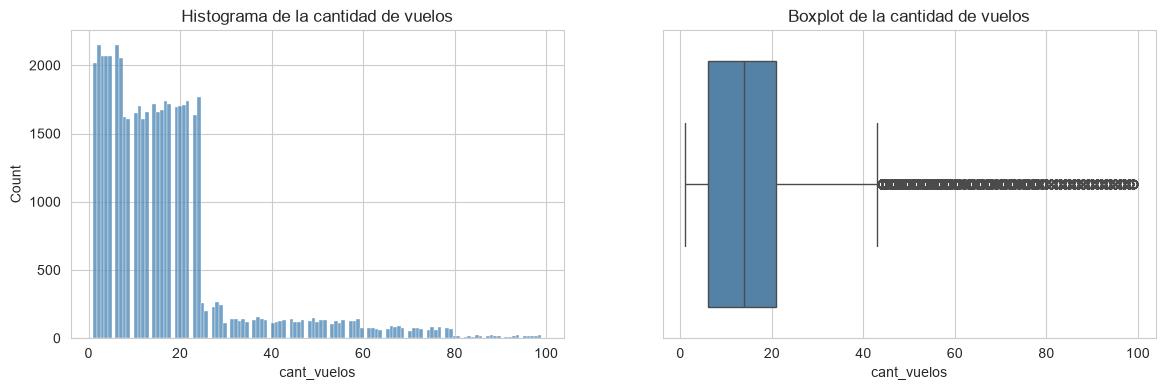

In [405]:
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_clientes, x="cant_vuelos", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de la cantidad de vuelos")
sns.boxplot(data=data_clientes, x="cant_vuelos", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de la cantidad de vuelos")
plt.show()

In [406]:
'''
El análisis de la variable Cantidad de vuelos muestra una distribución fuertemente sesgada a la derecha, indicando que la mayoría de los clientes de son viajeros ocasionales.
El Histograma revela que el volumen principal de usuarios tiene entre 1 y 25 vuelos acumulados, con una caída drástica en la frecuencia a medida que aumenta la cantidad. Por su
parte, el Boxplot confirma que el 50% central de la muestra se concentra en un rango bajo (aproximadamente entre 7 y 22 vuelos), con una mediana cercana a los 14. Se observa una
gran cantidad de outliers que se extienden hasta los 100 vuelos, representando al segmento de viajeros frecuentes.
'''

'\nEl análisis de la variable Cantidad de vuelos muestra una distribución fuertemente sesgada a la derecha, indicando que la mayoría de los clientes de son viajeros ocasionales.\nEl Histograma revela que el volumen principal de usuarios tiene entre 1 y 25 vuelos acumulados, con una caída drástica en la frecuencia a medida que aumenta la cantidad. Por su\nparte, el Boxplot confirma que el 50% central de la muestra se concentra en un rango bajo (aproximadamente entre 7 y 22 vuelos), con una mediana cercana a los 14. Se observa una\ngran cantidad de outliers que se extienden hasta los 100 vuelos, representando al segmento de viajeros frecuentes.\n'

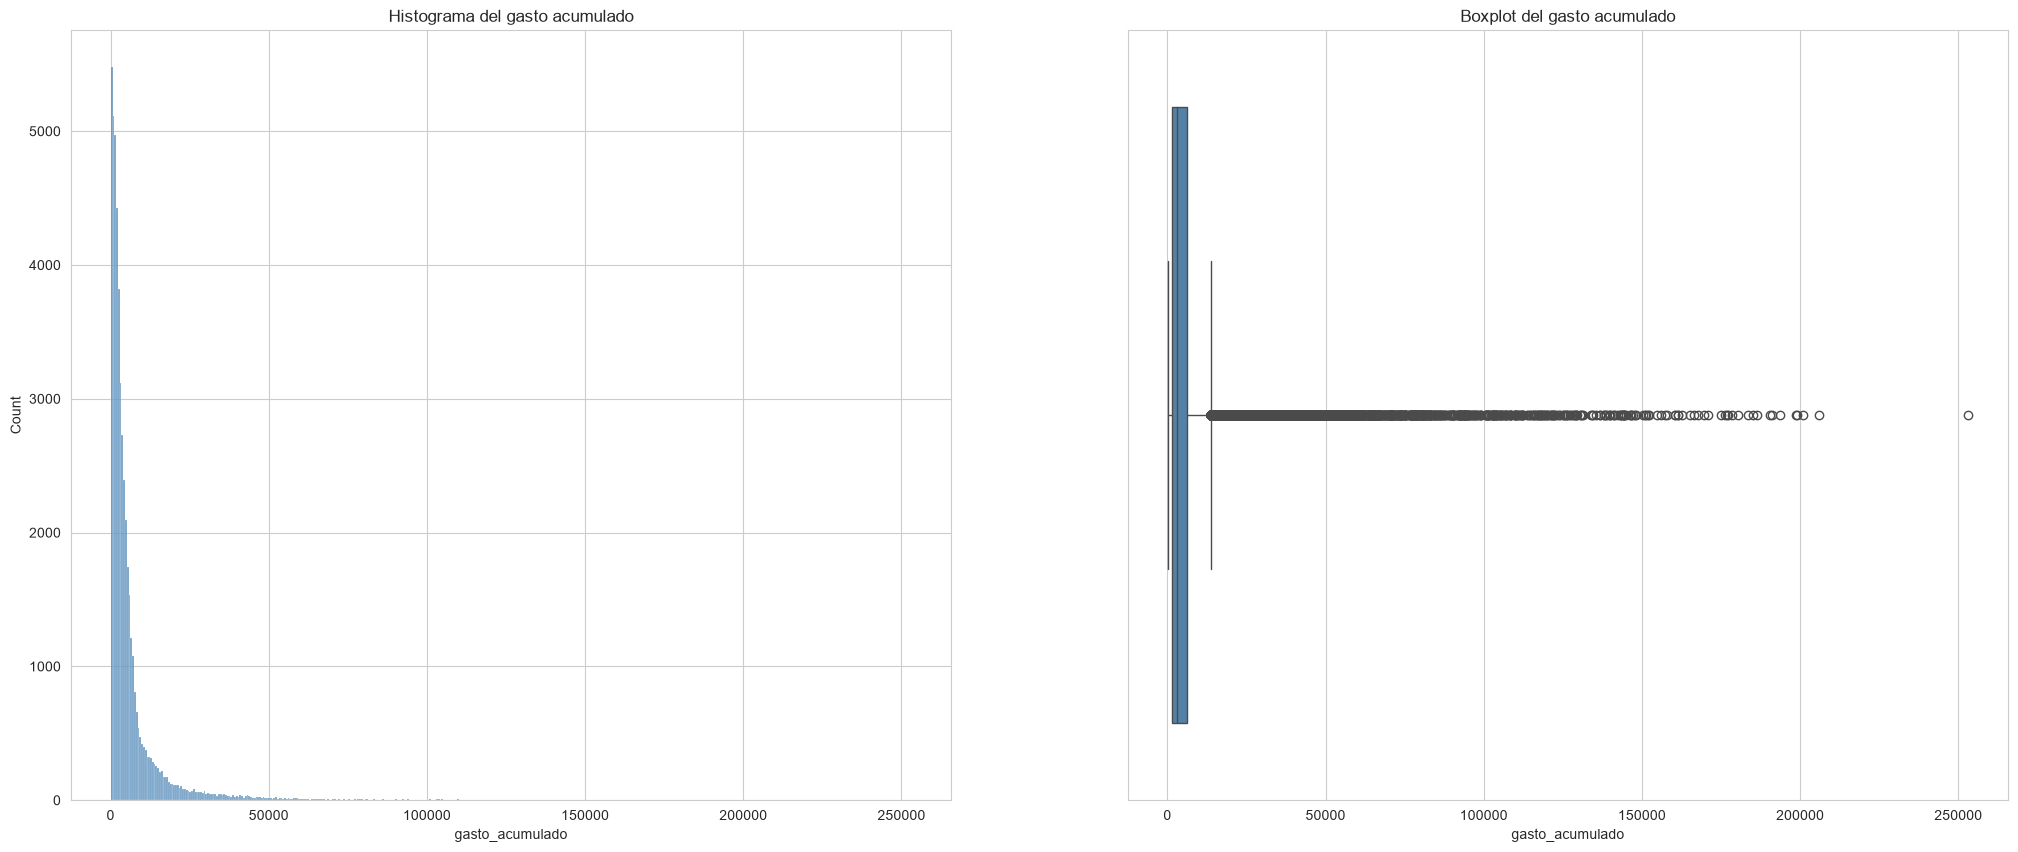

In [407]:
fig,ax = plt.subplots(1, 2, figsize=(25, 10))
sns.histplot(data=data_clientes, x="gasto_acumulado", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma del gasto acumulado")
sns.boxplot(data=data_clientes, x="gasto_acumulado", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot del gasto acumulado")
plt.show()

In [408]:
'''
La variable Gasto acumulado presenta una distribución con un sesgo positivo extremo, lo que significa que la gran masa de pasajeros tiene un consumo histórico bajo, mientras que
unos pocos generan ingresos significativamente altos.
Histograma: Muestra una concentración masiva de usuarios en los niveles iniciales de gasto, con una curva que desciende de forma abrupta. Esto indica que el modelo de negocio tiene
una base de clientes mayoritariamente ocasionales.
Boxplot: La caja aparece totalmente comprimida contra el eje inicial, evidenciando que el 50% central de los pasajeros gasta montos muy reducidos en comparación con el máximo de la
escala.
Outliers: Se observa una "cola" muy larga de valores atípicos que alcanzan los 250.000 USD. Estos representan a los clientes de elite o corporativos que son el objetivo principal
para los beneficios premium.
'''

'\nLa variable Gasto acumulado presenta una distribución con un sesgo positivo extremo, lo que significa que la gran masa de pasajeros tiene un consumo histórico bajo, mientras que\nunos pocos generan ingresos significativamente altos.\nHistograma: Muestra una concentración masiva de usuarios en los niveles iniciales de gasto, con una curva que desciende de forma abrupta. Esto indica que el modelo de negocio tiene\nuna base de clientes mayoritariamente ocasionales.\nBoxplot: La caja aparece totalmente comprimida contra el eje inicial, evidenciando que el 50% central de los pasajeros gasta montos muy reducidos en comparación con el máximo de la\nescala.\nOutliers: Se observa una "cola" muy larga de valores atípicos que alcanzan los 250.000 USD. Estos representan a los clientes de elite o corporativos que son el objetivo principal\npara los beneficios premium.\n'

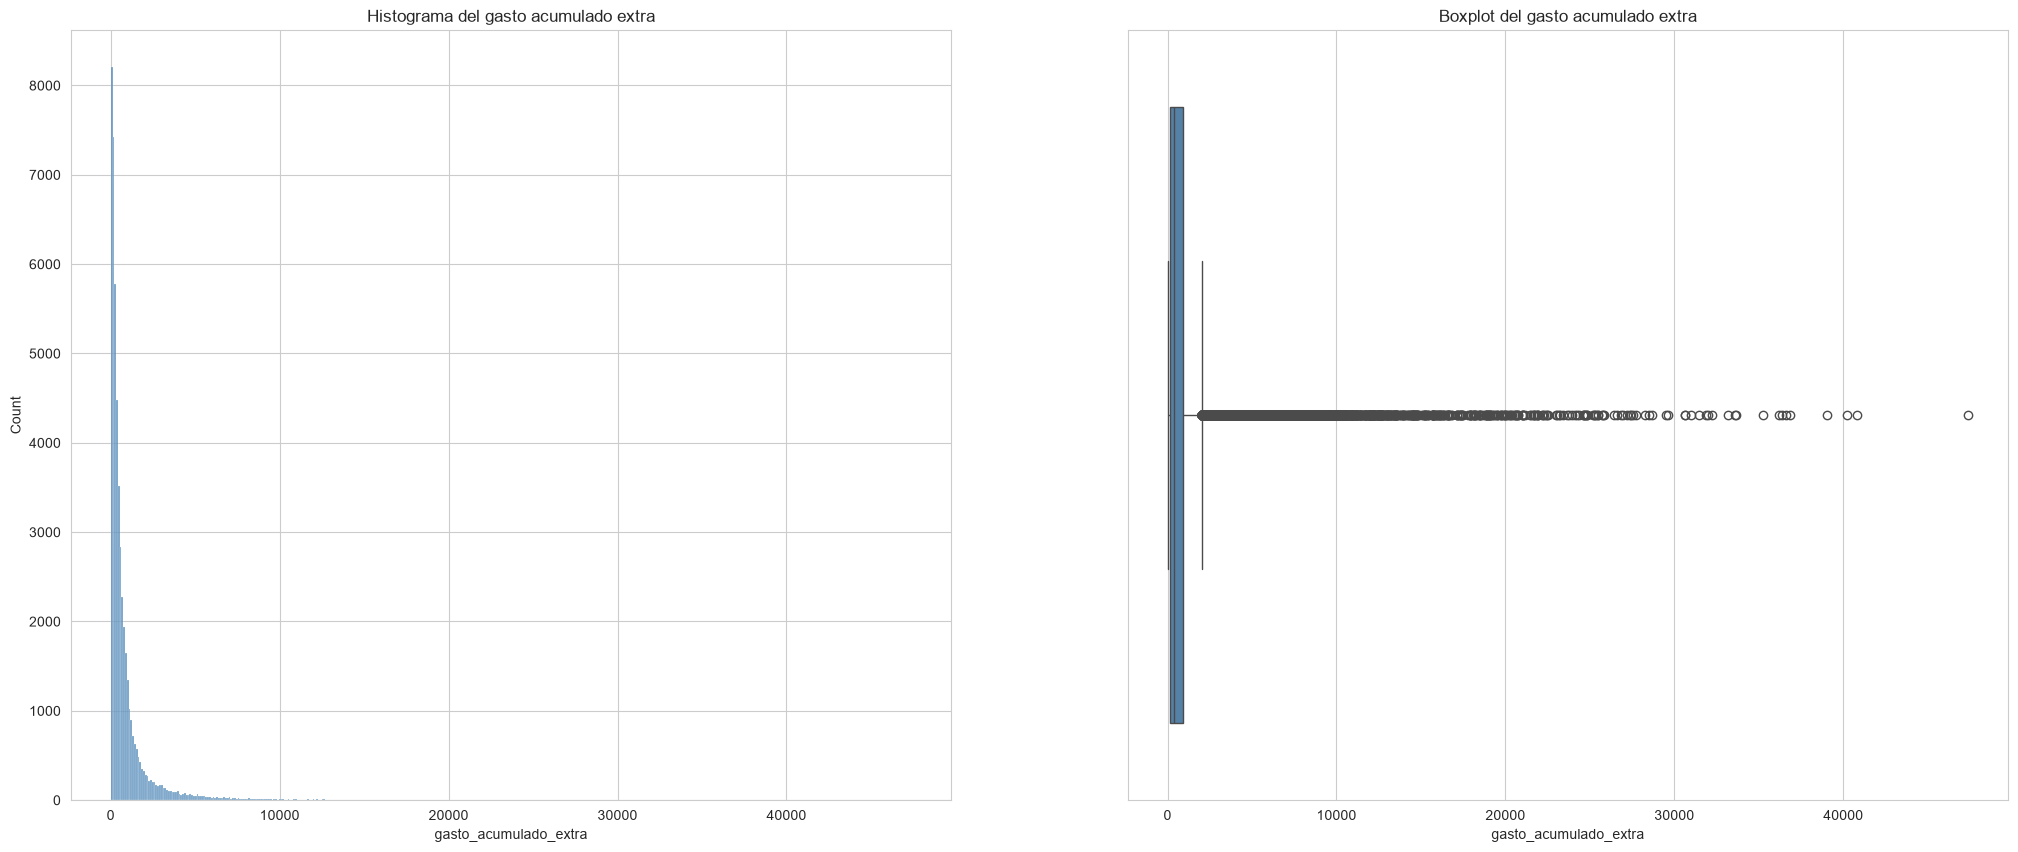

In [409]:
fig,ax = plt.subplots(1, 2, figsize=(25, 10))
sns.histplot(data=data_clientes, x="gasto_acumulado_extra", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma del gasto acumulado extra")
sns.boxplot(data=data_clientes, x="gasto_acumulado_extra", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot del gasto acumulado extra")
plt.show()

In [410]:
'''
El análisis de Gasto acumulado extra muestra una distribución con un sesgo positivo marcado, donde la gran mayoría de los clientes realiza consumos adicionales mínimos. Mientras
que el Histograma y el Boxplot reflejan una concentración masiva de registros en valores bajos, la presencia de outliers que superan los 40.000 USD identifica a un segmento de
clientes con un comportamiento de gasto excepcional.
'''

'\nEl análisis de Gasto acumulado extra muestra una distribución con un sesgo positivo marcado, donde la gran mayoría de los clientes realiza consumos adicionales mínimos. Mientras\nque el Histograma y el Boxplot reflejan una concentración masiva de registros en valores bajos, la presencia de outliers que superan los 40.000 USD identifica a un segmento de\nclientes con un comportamiento de gasto excepcional.\n'

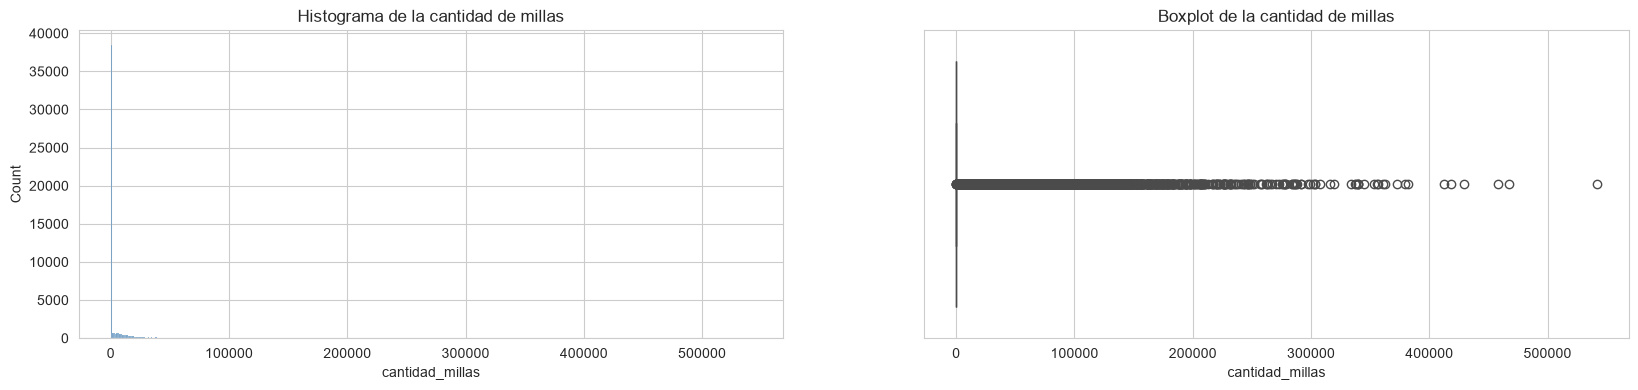

In [411]:
#Consultar si hay grafico mas lindo
fig,ax = plt.subplots(1, 2, figsize=(20, 4))
sns.histplot(data=data_clientes, x="cantidad_millas", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de la cantidad de millas")
sns.boxplot(data=data_clientes, x="cantidad_millas", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de la cantidad de millas")
plt.show()

In [412]:
'''
El análisis de la variable Cantidad de millas exhibe una distribución con un sesgo positivo extremo, similar a las variables de gasto, lo que indica que el programa de fidelidad
está concentrado en una base de usuarios con acumulaciones bajas. Mientras que el Histograma muestra que la gran mayoría de los pasajeros poseen menos de 50.000 millas, el Boxplot
evidencia una caja totalmente comprimida contra el origen, reflejando que el pasajero promedio no alcanza niveles altos de puntaje. Se destaca una presencia masiva de outliers que
llegan hasta las 500.000 millas, representando al segmento de viajeros frecuentes más leales a la compañía.
'''

'\nEl análisis de la variable Cantidad de millas exhibe una distribución con un sesgo positivo extremo, similar a las variables de gasto, lo que indica que el programa de fidelidad\nestá concentrado en una base de usuarios con acumulaciones bajas. Mientras que el Histograma muestra que la gran mayoría de los pasajeros poseen menos de 50.000 millas, el Boxplot\nevidencia una caja totalmente comprimida contra el origen, reflejando que el pasajero promedio no alcanza niveles altos de puntaje. Se destaca una presencia masiva de outliers que\nllegan hasta las 500.000 millas, representando al segmento de viajeros frecuentes más leales a la compañía.\n'

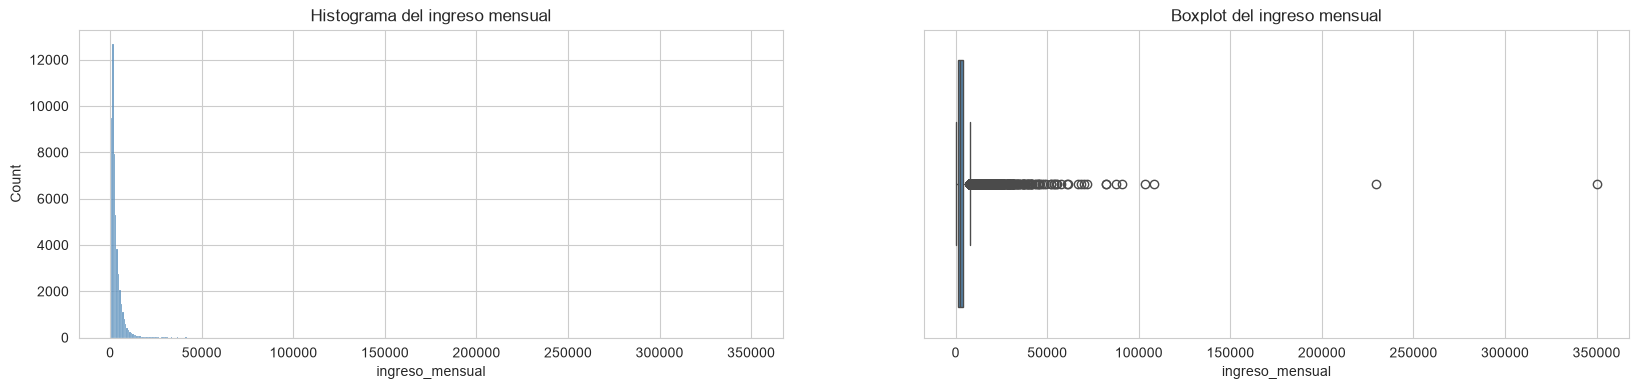

In [413]:
fig,ax = plt.subplots(1, 2, figsize=(20, 4))
sns.histplot(data=data_clientes, x="ingreso_mensual", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma del ingreso mensual")
sns.boxplot(data=data_clientes, x="ingreso_mensual", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot del ingreso mensual")
plt.show()

In [414]:
'''
El análisis de la variable Ingreso mensual presenta, al igual que las métricas de consumo, un sesgo positivo extremo. El Histograma muestra que la vasta mayoría de los pasajeros
se concentra en los estratos de ingresos iniciales, con una frecuencia que desaparece rápidamente al avanzar en la escala. Por su parte, el Boxplot exhibe una caja totalmente
contraída contra el origen, indicando que el 50% central de la muestra tiene ingresos muy bajos comparados con los valores máximos registrados. Se observa una dispersión masiva de
outliers que llegan hasta los 350.000 USD mensuales, lo que representa a un segmento de élite económica dentro de la clientela.
'''

'\nEl análisis de la variable Ingreso mensual presenta, al igual que las métricas de consumo, un sesgo positivo extremo. El Histograma muestra que la vasta mayoría de los pasajeros\nse concentra en los estratos de ingresos iniciales, con una frecuencia que desaparece rápidamente al avanzar en la escala. Por su parte, el Boxplot exhibe una caja totalmente\ncontraída contra el origen, indicando que el 50% central de la muestra tiene ingresos muy bajos comparados con los valores máximos registrados. Se observa una dispersión masiva de\noutliers que llegan hasta los 350.000 USD mensuales, lo que representa a un segmento de élite económica dentro de la clientela.\n'

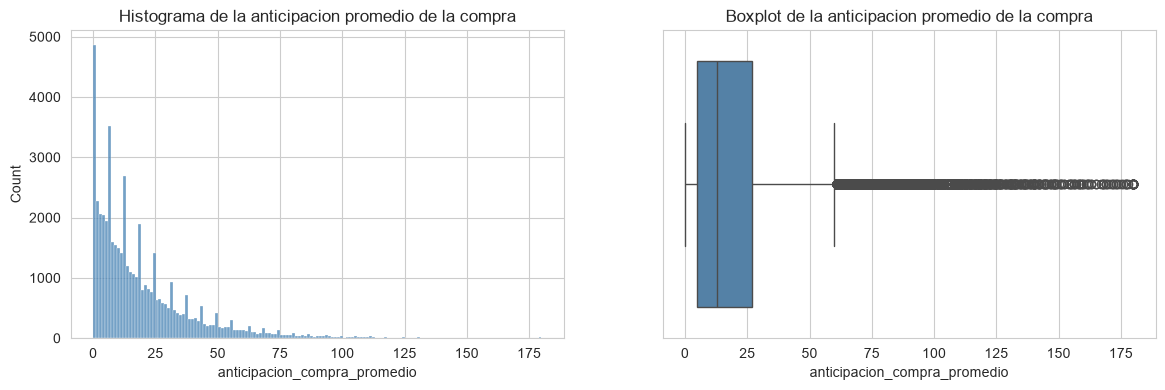

In [415]:
fig,ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data_clientes, x="anticipacion_compra_promedio", ax=ax[0], color="steelblue")
ax[0].title.set_text("Histograma de la anticipacion promedio de la compra")
sns.boxplot(data=data_clientes, x="anticipacion_compra_promedio", ax=ax[1], color="steelblue")
ax[1].title.set_text("Boxplot de la anticipacion promedio de la compra")
plt.show()

In [416]:
'''
El análisis de la variable Anticipación compra promedio muestra una distribución asimétrica positiva, indicando que la mayoría de los clientes planifican sus viajes con poca
antelación.
Histograma: Se observa un pico muy pronunciado cerca del valor cero, lo que sugiere que una gran parte de los usuarios realiza compras de "último minuto" o con menos de 15 días de
margen.
Boxplot: El 50% central de los pasajeros (rango intercuartílico) tiene una anticipación promedio que oscila aproximadamente entre los 5 y 27 días, con una mediana cercana a las dos
semanas.
Outliers: Existe una presencia constante de valores atípicos que superan los 60 días y llegan hasta los 180, representando a aquellos clientes que planifican sus vuelos con varios
meses de antelación.
'''

'\nEl análisis de la variable Anticipación compra promedio muestra una distribución asimétrica positiva, indicando que la mayoría de los clientes planifican sus viajes con poca\nantelación.\nHistograma: Se observa un pico muy pronunciado cerca del valor cero, lo que sugiere que una gran parte de los usuarios realiza compras de "último minuto" o con menos de 15 días de\nmargen.\nBoxplot: El 50% central de los pasajeros (rango intercuartílico) tiene una anticipación promedio que oscila aproximadamente entre los 5 y 27 días, con una mediana cercana a las dos\nsemanas.\nOutliers: Existe una presencia constante de valores atípicos que superan los 60 días y llegan hasta los 180, representando a aquellos clientes que planifican sus vuelos con varios\nmeses de antelación.\n'

##Graficos de Barras

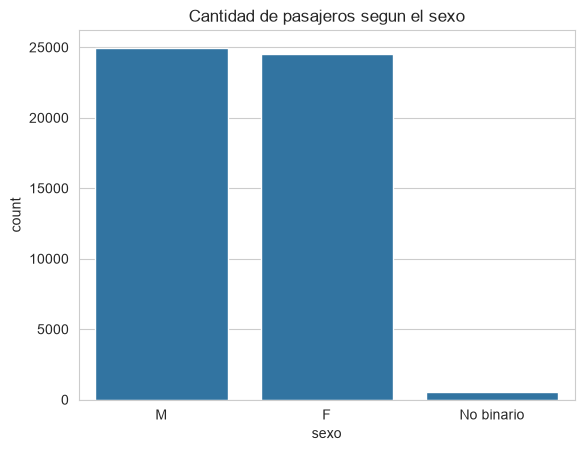

In [417]:
sns.countplot(x="sexo", data=data_clientes)
plt.title("Cantidad de pasajeros segun el sexo")
plt.show()

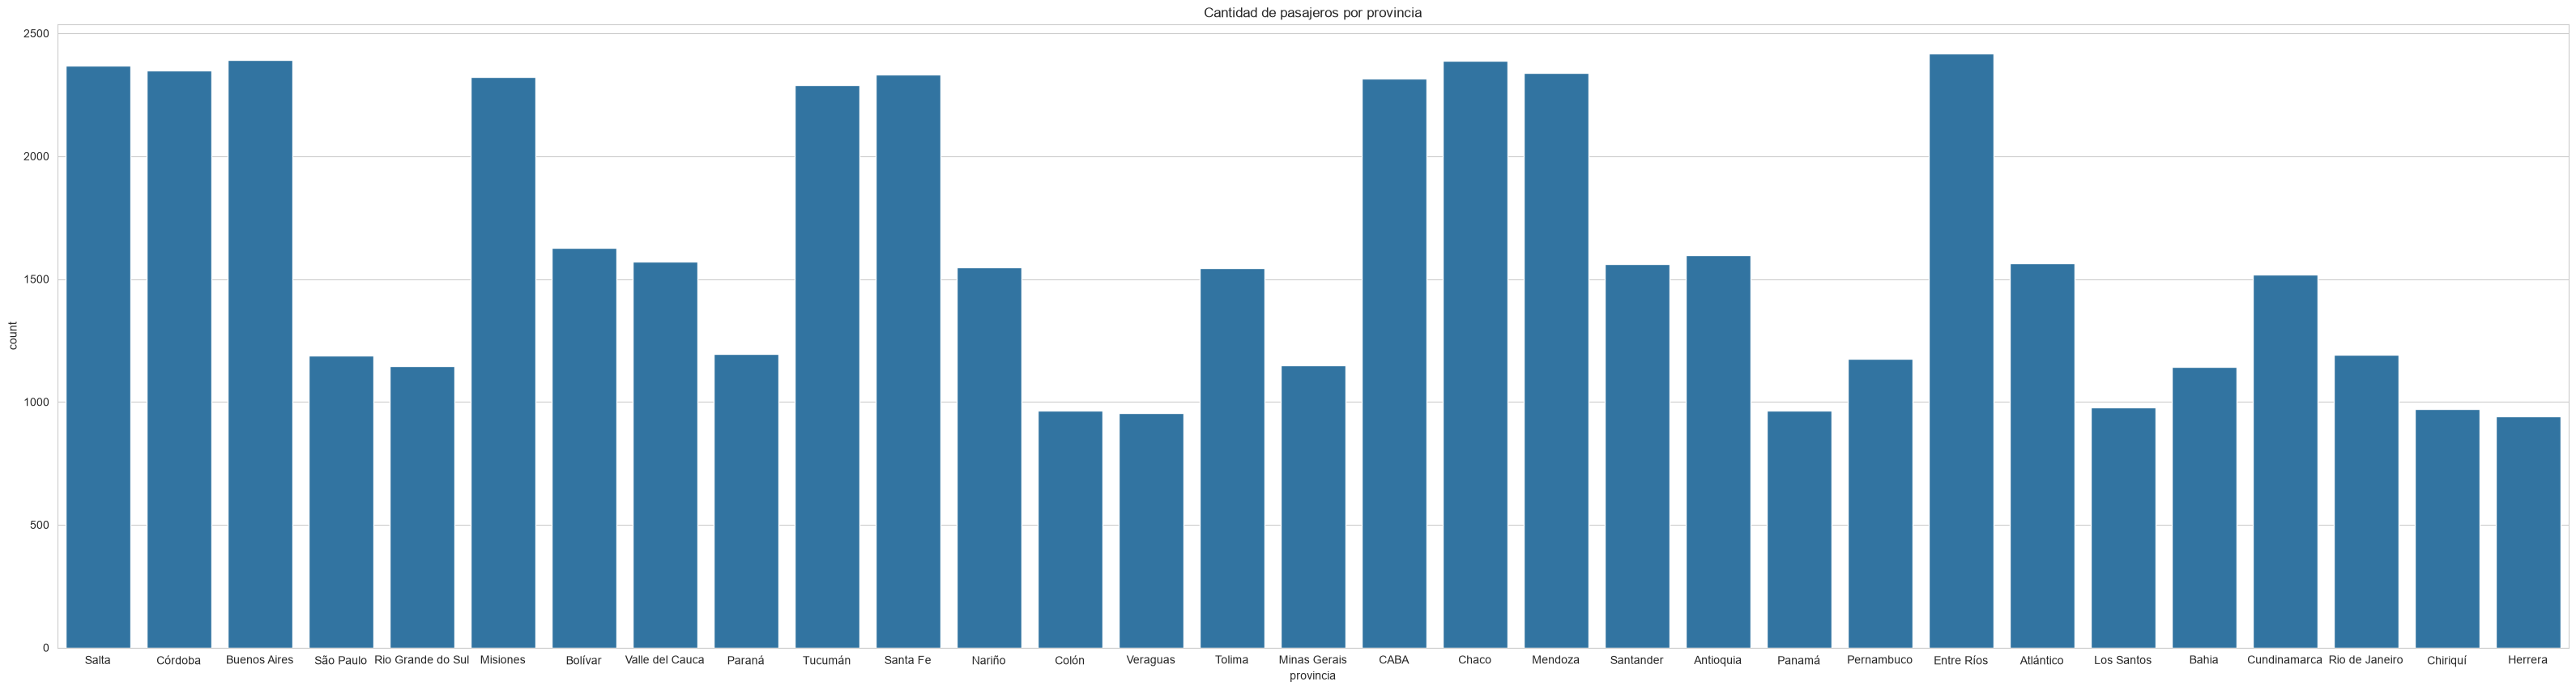

In [418]:
fig,ax = plt.subplots(1, 1, figsize=(40, 10))
sns.countplot(x="provincia", data=data_clientes)
ax.title.set_text("Cantidad de pasajeros por provincia")
plt.show()

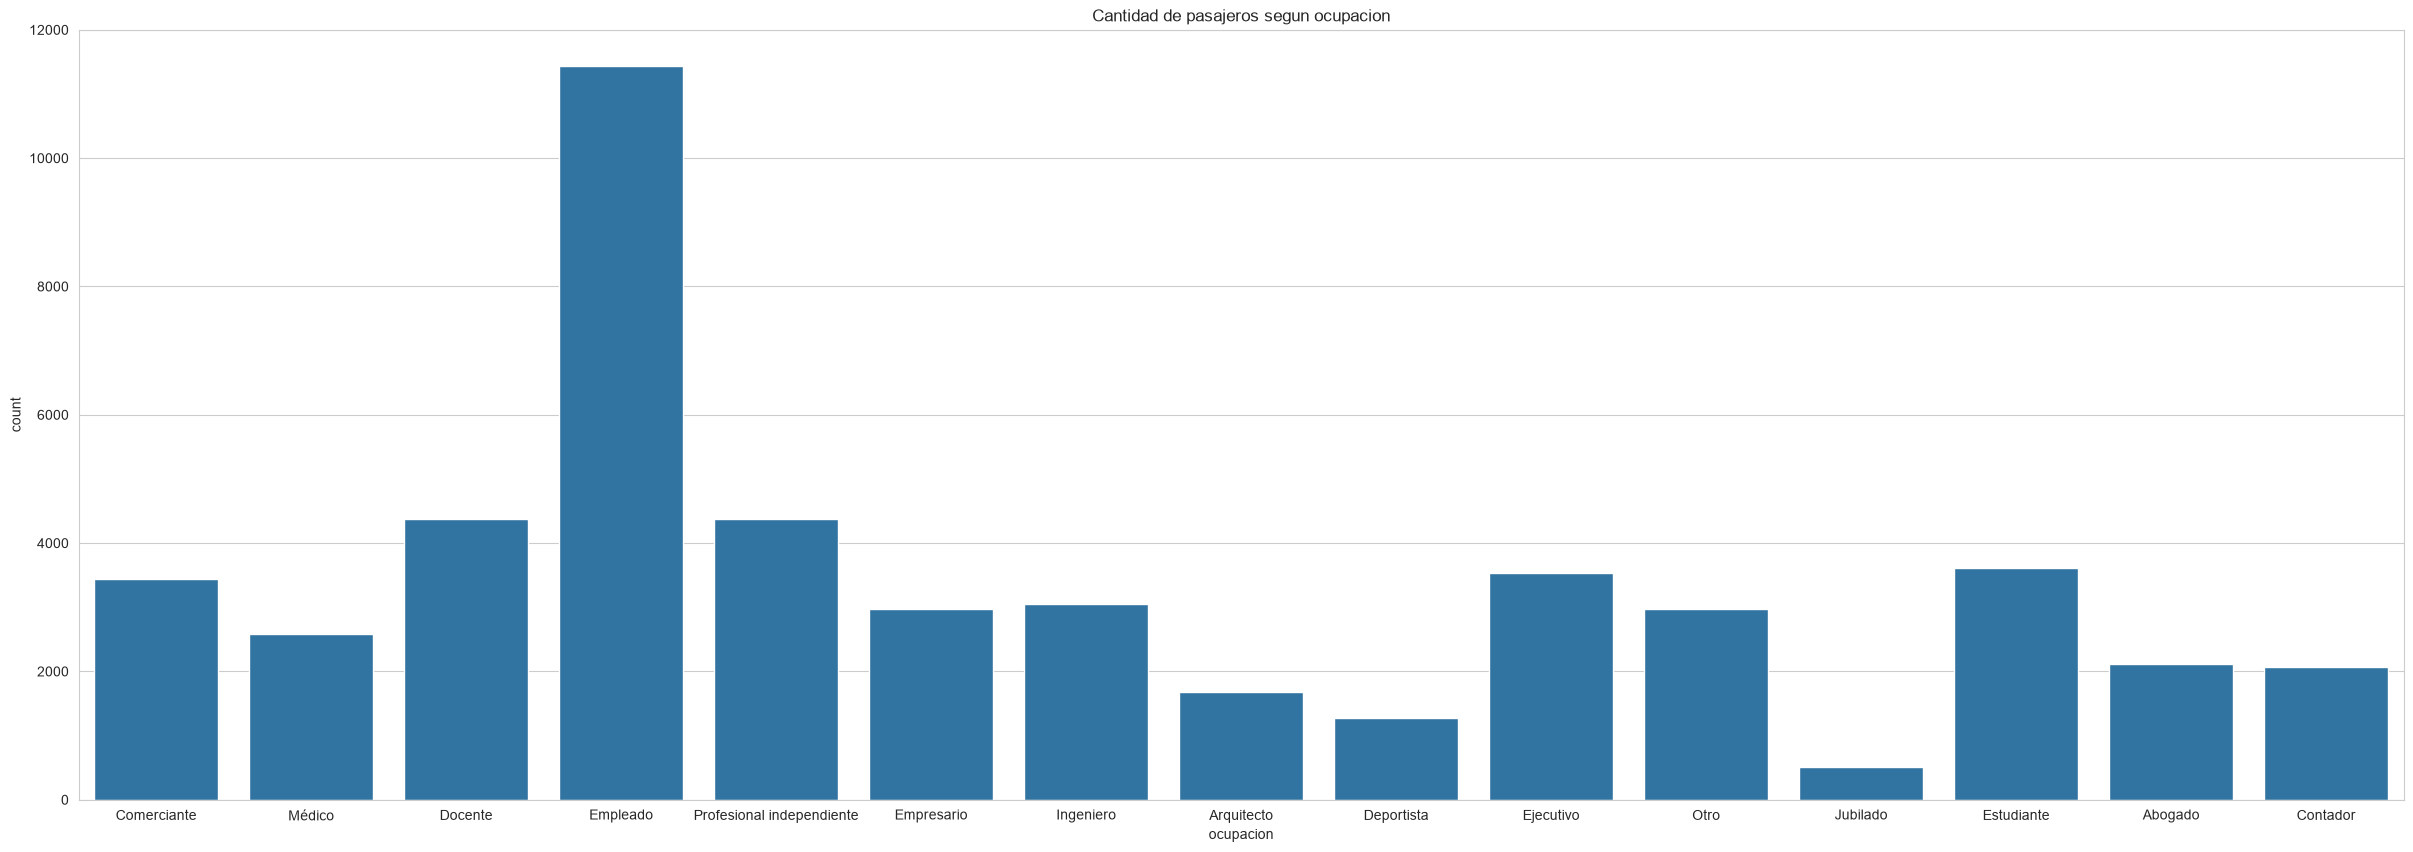

In [419]:
fig,ax = plt.subplots(1, 1, figsize=(30, 10))
sns.countplot(x="ocupacion", data=data_clientes)
ax.title.set_text("Cantidad de pasajeros segun ocupacion")
plt.show()

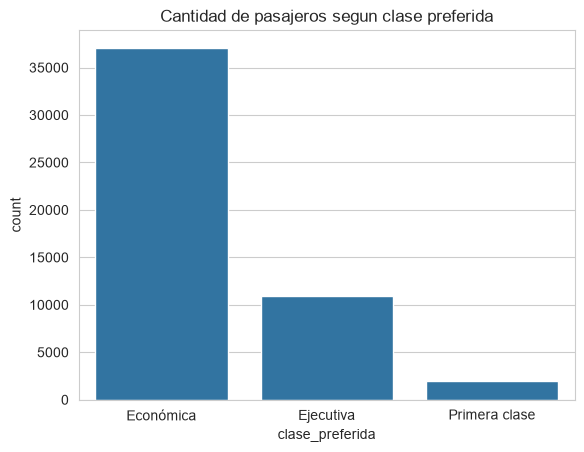

In [420]:
sns.countplot(x="clase_preferida", data=data_clientes)
plt.title("Cantidad de pasajeros segun clase preferida")
plt.show()

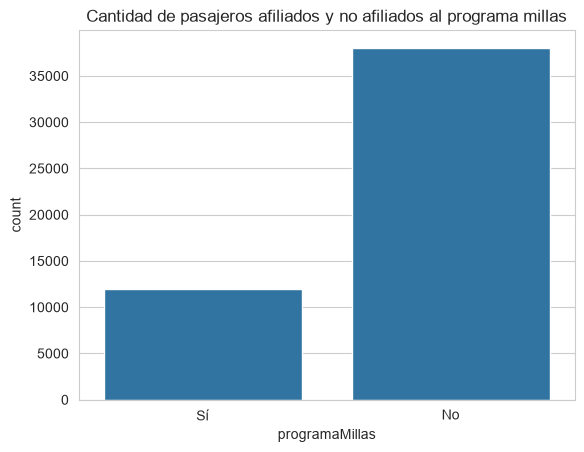

In [421]:
sns.countplot(x="programaMillas", data=data_clientes)
plt.title("Cantidad de pasajeros afiliados y no afiliados al programa millas")
plt.show()

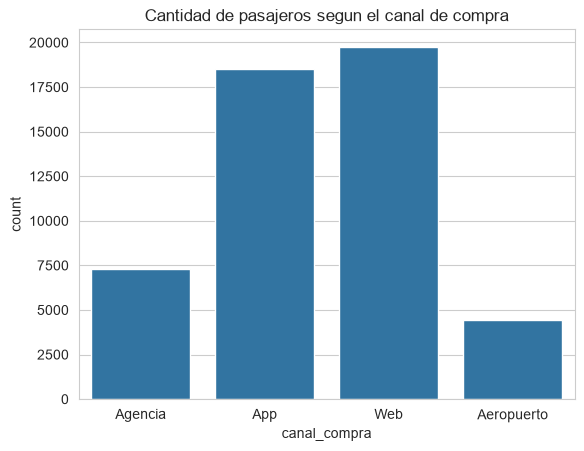

In [422]:
sns.countplot(x="canal_compra", data=data_clientes)
plt.title("Cantidad de pasajeros segun el canal de compra")
plt.show()

##Matriz de Covarianzas

In [423]:
data_clientes.cov(numeric_only=True)

,edad,cant_vuelos,gasto_acumulado,gasto_acumulado_extra,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio
edad,131.776285,19.949582,8.959960e+03,1.242403e+03,1.022505e+04,3.729699e+03,-19.628833
cant_vuelos,19.949582,248.075858,1.203627e+05,1.738962e+04,1.841592e+05,1.901951e+04,-38.076482
gasto_acumulado,8959.959649,120362.707455,1.547506e+08,2.239549e+07,1.625663e+08,1.856816e+07,-19671.211744
gasto_acumulado_extra,1242.402641,17389.616596,2.239549e+07,3.950614e+06,2.345719e+07,2.711224e+06,-2771.858091
cantidad_millas,10225.046659,184159.221893,1.625663e+08,2.345719e+07,5.536441e+08,2.343386e+07,-29262.358128
ingreso_mensual,3729.699355,19019.513698,1.856816e+07,2.711224e+06,2.343386e+07,1.429128e+07,-4327.631060
anticipacion_compra_promedio,-19.628833,-38.076482,-1.967121e+04,-2.771858e+03,-2.926236e+04,-4.327631e+03,458.027639


##Matriz de Correlaciones

In [424]:
data_clientes.corr(numeric_only=True)

,edad,cant_vuelos,gasto_acumulado,gasto_acumulado_extra,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio
edad,1.000000,0.110337,0.062744,0.054452,0.037856,0.085945,-0.079897
cant_vuelos,0.110337,1.000000,0.614304,0.555476,0.496919,0.319427,-0.112958
gasto_acumulado,0.062744,0.614304,1.000000,0.905758,0.555391,0.394836,-0.073887
gasto_acumulado_extra,0.054452,0.555476,0.905758,1.000000,0.501566,0.360826,-0.065162
cantidad_millas,0.037856,0.496919,0.555391,0.501566,1.000000,0.263447,-0.058110
ingreso_mensual,0.085945,0.319427,0.394836,0.360826,0.263447,1.000000,-0.053490
anticipacion_compra_promedio,-0.079897,-0.112958,-0.073887,-0.065162,-0.058110,-0.053490,1.000000


##Scatterplot

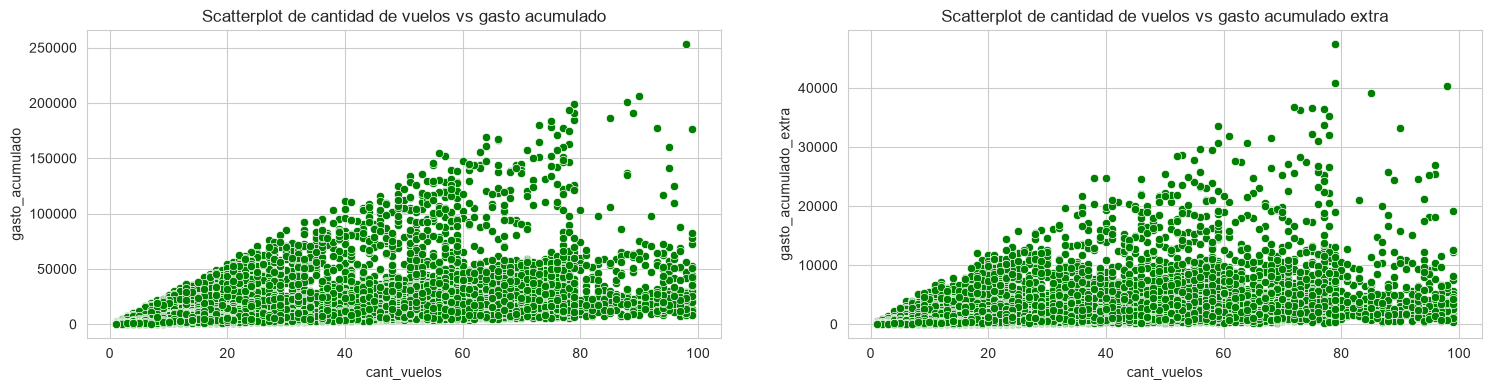

In [425]:
fig,ax = plt.subplots(1, 2, figsize=(18, 4))
sns.scatterplot(data=data_clientes, x="cant_vuelos",ax=ax[0], y="gasto_acumulado", color="green")
ax[0].title.set_text("Scatterplot de cantidad de vuelos vs gasto acumulado")
sns.scatterplot(data=data_clientes, x="cant_vuelos",ax=ax[1], y="gasto_acumulado_extra", color="green")
ax[1].title.set_text("Scatterplot de cantidad de vuelos vs gasto acumulado extra")
plt.show()

In [426]:
'''
Cantidad de Vuelos vs. Gasto Acumulado
Podemos visualizar una tendencia logica donde a mayor cantidad de vuelos, el techo de gasto acumulado sube. En cuanto a la dispersion no podemos asegurar que un cliente que tenga
muchos vuelos si o si gaste mucho dinero ya que puede haber muchos vuelos de clase economica por ejemplo.

Cantidad de Vuelos vs. Gasto Acumulado Extra
Podemos visualizar tambien la tendencia donde a mayor cantidad de vuelos hay mayor gasto acumulado extra. Pero mientras el gasto acumulado llega a $250,000 el gasto en extras llega
a $45,000. El comportamiento es proporcional. El que gasta mucho en pasajes tambien gasta mucho en servicios extras.
'''

'\nCantidad de Vuelos vs. Gasto Acumulado\nPodemos visualizar una tendencia logica donde a mayor cantidad de vuelos, el techo de gasto acumulado sube. En cuanto a la dispersion no podemos asegurar que un cliente que tenga\nmuchos vuelos si o si gaste mucho dinero ya que puede haber muchos vuelos de clase economica por ejemplo.\n\nCantidad de Vuelos vs. Gasto Acumulado Extra\nPodemos visualizar tambien la tendencia donde a mayor cantidad de vuelos hay mayor gasto acumulado extra. Pero mientras el gasto acumulado llega a $250,000 el gasto en extras llega\na $45,000. El comportamiento es proporcional. El que gasta mucho en pasajes tambien gasta mucho en servicios extras.\n'

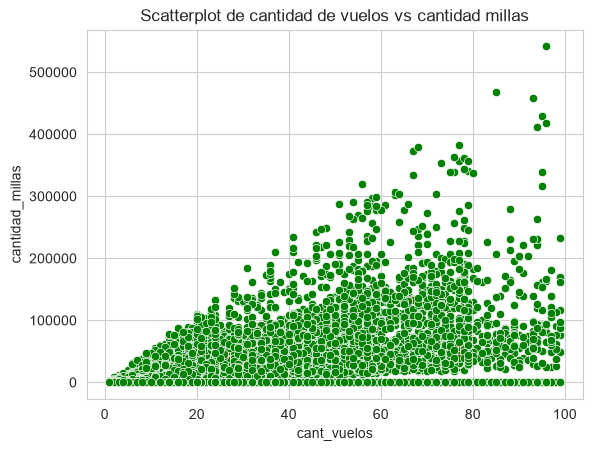

In [427]:
sns.scatterplot(data=data_clientes, x="cant_vuelos", y="cantidad_millas", color="green")
plt.title("Scatterplot de cantidad de vuelos vs cantidad millas")
plt.show()

In [428]:
'''
A medida que aumentan los vuelos tambien aumentan la cantidad de millas
La dispersion no es una linea recta, sino que se va abriendo. Refleja que no todos los vuelos valen lo mismo. Un pasajero con 60 vuelos puede tener 100,000 millas (si volo siempre
economica y tramos cortos) o puede tener 300.000 millas (si viajo ejecutva a destinos internacionales)

El grafico es necesario para poder entender como podemos clasificar cada paseaero como VIP o no, ya que nos demuestra la "frecuencia" no es igual a "valor". Por ejemplo no vamos a
hacer estrictamente VIP a todos los que tengan mas de 60 vuelos, podemos ver que hay muchos clientes con pocas millas y otros con muchas.
'''

'\nA medida que aumentan los vuelos tambien aumentan la cantidad de millas\nLa dispersion no es una linea recta, sino que se va abriendo. Refleja que no todos los vuelos valen lo mismo. Un pasajero con 60 vuelos puede tener 100,000 millas (si volo siempre\neconomica y tramos cortos) o puede tener 300.000 millas (si viajo ejecutva a destinos internacionales)\n\nEl grafico es necesario para poder entender como podemos clasificar cada paseaero como VIP o no, ya que nos demuestra la "frecuencia" no es igual a "valor". Por ejemplo no vamos a\nhacer estrictamente VIP a todos los que tengan mas de 60 vuelos, podemos ver que hay muchos clientes con pocas millas y otros con muchas.\n'

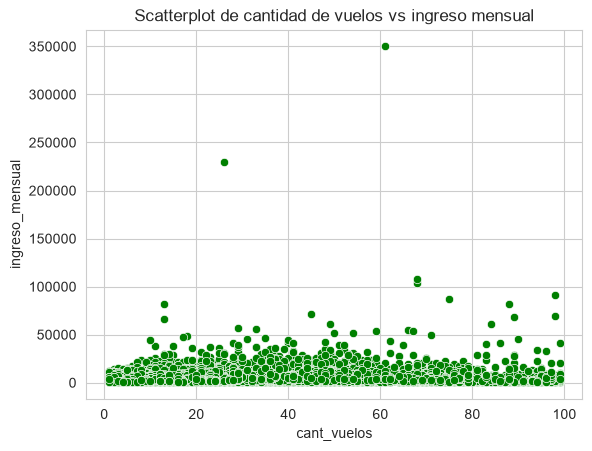

In [429]:
sns.scatterplot(data=data_clientes, x="cant_vuelos", y="ingreso_mensual", color="green")
plt.title("Scatterplot de cantidad de vuelos vs ingreso mensual")
plt.show()

In [430]:
'''
Podemos ver que hay mucha falta de correlacion, el 95% de los puntos estan aplastados en la parte inferior del grafico desde 0 a 100, esto significa que no hay relacion directa
entre cuanto gana una persona y cuantas veces vuela. Tenes gente que gana 20.000 y vuela 5 veces y gente que gana 20.000 y vuela 90 veces.

El grafico sirve para evitar asumir que sueldo alto = cliente leal.
'''

'\nPodemos ver que hay mucha falta de correlacion, el 95% de los puntos estan aplastados en la parte inferior del grafico desde 0 a 100, esto significa que no hay relacion directa\nentre cuanto gana una persona y cuantas veces vuela. Tenes gente que gana 20.000 y vuela 5 veces y gente que gana 20.000 y vuela 90 veces.\n\nEl grafico sirve para evitar asumir que sueldo alto = cliente leal.\n'

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=data_clientes, x='sexo')

plt.title("Distribución por sexo")
plt.ylabel("Cantidad de clientes")
plt.show()